In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(43)
np.random.seed(43)

# Define the path to CSV file
#file_path = "/home/oj/Project_code/MLLS Hackaton/compas_propublica.csv"
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/compas_propublica.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Preprocess the data - Apply ProPublica filters to remove invalid cases
df = df[(df['days_b_screening_arrest'] <= 30) & (df['days_b_screening_arrest'] >= -30)] 
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']

# Merge Asian and Native American with others in the dataset
df['race'] = df['race'].replace(['Asian', 'Native American'], 'Other')

# Select relevant columns including new features (NOW USING decile_score as label)
df = df[['id', 'sex', 'dob', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 
         'juv_other_count', 'priors_count', 'c_charge_degree', 'c_charge_desc', 
         'decile_score', 'score_text', 'is_recid']].copy()  # Using decile_score as label

# === Feature Engineering & Encoding ===

# Keep original categorical columns for reference
df['sex_original'] = df['sex']
df['race_original'] = df['race']
df['risk_original'] = df['score_text']
df['charge_degree_original'] = df['c_charge_degree']

# --------------------------------------------------------------
#  COMPAS: XGBoost + Influence + SHAP (per obs) + Plots + Excel
# --------------------------------------------------------------
import xgboost as xgb
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import shap
import warnings; warnings.filterwarnings('ignore')
import os
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from scipy.stats import mannwhitneyu

# ------------------- 1. Train XGBoost (Classification) -----------------
def train_xgb(X_train, y_train, X_val=None, y_val=None, weights=None):
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
    dval   = xgb.DMatrix(X_val, label=y_val) if X_val is not None else None
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'eta': 0.05,
        'max_depth': 4,
        'min_child_weight': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 43,
        'tree_method': 'hist'
    }
    evals = [(dval, 'val')] if dval else []
    model = xgb.train(
        params, dtrain, num_boost_round=500,
        evals=evals, early_stopping_rounds=50 if dval else None,
        verbose_eval=False
    )
    return model

# ------------------- 2. Gradient & Hessian (Classification) -----------------
def log_loss_grad_hess(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    grad = y_pred - y_true
    hess = y_pred * (1 - y_pred)
    return grad, hess

def cg_solve(Av_func, b, max_iter=400, tol=1e-6):
    x = np.zeros_like(b); r = b.copy(); p = b.copy(); rs_old = np.dot(r, r)
    for _ in range(max_iter):
        Ap = Av_func(p)
        alpha = rs_old / (np.dot(p, Ap) + 1e-12)
        x = x + alpha * p; r = r - alpha * Ap
        rs_new = np.dot(r, r)
        if np.sqrt(rs_new) < tol: break
        p = r + (rs_new / (rs_old + 1e-12)) * p
        rs_old = rs_new
    return x

# ------------------- 3. Influence Matrix (Classification) -----------------
def compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0):
    n_train, n_test = X_train.shape[0], X_test.shape[0]
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    prob_train = model.predict(dtrain); prob_test = model.predict(dtest)
    grad_train, hess_train = log_loss_grad_hess(y_train, prob_train)
    grad_test,  hess_test  = log_loss_grad_hess(y_test,  prob_test)

    leaf_idx_train = model.predict(dtrain, pred_leaf=True)
    leaf_idx_test  = model.predict(dtest,  pred_leaf=True)
    n_trees = leaf_idx_train.shape[1]

    leaf_maps = []
    for t in range(n_trees):
        leaves = np.unique(leaf_idx_train[:, t])
        leaf_maps.append({leaf: i for i, leaf in enumerate(leaves)})

    def get_leaf_matrix(leaf_idx):
        rows, cols, data = [], [], []
        offset = 0
        for t in range(n_trees):
            for i in range(leaf_idx.shape[0]):
                leaf = leaf_idx[i, t]
                if leaf in leaf_maps[t]:
                    col = offset + leaf_maps[t][leaf]
                    rows.append(i); cols.append(col); data.append(1.0)
            offset += len(leaf_maps[t])
        total_cols = sum(len(m) for m in leaf_maps)
        return sp.csr_matrix((data, (rows, cols)), shape=(leaf_idx.shape[0], total_cols))

    Phi_train = get_leaf_matrix(leaf_idx_train)
    Phi_test  = get_leaf_matrix(leaf_idx_test)

    W_sqrt = sp.diags(np.sqrt(hess_train))
    Phi_w  = W_sqrt @ Phi_train

    def Av(v):
        return (Phi_w.T @ (Phi_w @ v)) / n_train + damping * v

    print("Solving (H + gamma I)s = change L_j * THETA_j ...")
    ihvps = []
    for j in range(n_train):
        if j % 500 == 0: print(f" CG solve {j}/{n_train}")
        b = grad_train[j] * Phi_train[j].toarray().ravel()
        s = cg_solve(Av, b)
        ihvps.append(s)

    print("Computing influence matrix...")
    IF_matrix = np.zeros((n_test, n_train))
    for i in range(n_test):
        phi_i = Phi_test[i].toarray().ravel()
        for j in range(n_train):
            IF_matrix[i, j] = -grad_test[i] * np.dot(phi_i, ihvps[j])
        if i % 100 == 0: print(f"  Row {i}/{n_test}")
    return IF_matrix

# ------------------- 4. SHAP Interactions -----------------
def compute_shap_interactions(model, X_test):
    # Ensure data types are correct for SHAP
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_inter = explainer.shap_interaction_values(X_test)
    return np.array(shap_inter)

# ------------------- 5. Permutation Test -----------------
def permutation_test(A, B, n_permutations=10000):
    obs_diff = B.mean() - A.mean()
    combined = np.hstack([A.flatten(), B.flatten()])
    count = 0; len_A = A.size
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        diff = combined[:len_A].mean() - combined[len_A:].mean()
        if diff >= obs_diff: count += 1
    p_val = (count + 1) / (n_permutations + 1)
    return obs_diff, p_val

# ------------------- 6. SHAP per Observation + Summary Plot -----------------
def save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer, sheet_prefix=''):
    print("Computing SHAP main effects …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    shap_df = pd.DataFrame(shap_vals, columns=feature_names)
    
    # Add ID and Race as first columns
    shap_df.insert(0, 'Race_Test', race_test)
    shap_df.insert(0, 'Test_ID', id_test)
    
    shap_df.to_excel(writer, sheet_name=f'{sheet_prefix}SHAP_Main_Effects', index=False)

    print("Computing SHAP interaction values …")
    shap_inter = explainer.shap_interaction_values(X_test)
    for idx in range(min(5, len(X_test))):  # Limit to first 5 to avoid Excel limits
        inter_mat = shap_inter[idx]
        inter_df = pd.DataFrame(inter_mat, index=feature_names, columns=feature_names)
        sheet = f"{sheet_prefix}Inter_ID{id_test[idx]}_{race_test[idx]}"
        inter_df.to_excel(writer, sheet_name=sheet[:31])

    print("SHAP sheets written")

# ------------------- 6b. SHAP Summary Plot -----------------

def plot_shap_summary(model, X_test, feature_names, plot_dir, target_title, file_suffix=''):
    os.makedirs(plot_dir, exist_ok=True)
    print("Creating SHAP summary (beeswarm) plot …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test, feature_names=feature_names,
                      show=False, plot_type="dot", max_display=20)
    plt.title(f"SHAP Summary{file_suffix} - Feature Impact on Predicted {target_title}", fontsize=14)
    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"shap_summary_beeswarm{file_suffix}.png")
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"->Saved: {out_path}")

# ------------------- 7. MAIN FUNCTION -----------------
def compas_xgb_full_analysis(df,
                             excel_path="results_compas.xlsx",
                             plot_dir="influence_histograms",
                             target_col='decile_binary',
                             label_name='DecileScore',
                             target_title='High Risk (Decile 6-10)'):
    os.makedirs(plot_dir, exist_ok=True)
    
    # Compute target
    if target_col == 'decile_binary':
        df['target'] = (df['decile_score'] >= 6).astype(int)
        extra_req = ['decile_score']
    else:
        df['target'] = df[target_col].astype(int)
        extra_req = [target_col]

    # === Drop rows with missing critical values ===
    required_cols = ['sex_original', 'race_original', 'charge_degree_original', 'risk_original',
                     'age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 
                     'juv_other_count'] + extra_req
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    print(f"Final dataset size: {len(df)}")
    print(f"Binary target distribution:\n{df['target'].value_counts()}")

    # Add intersectional group
    df['group'] = df['race_original'] + '_' + df['sex_original']

    # ---- Create proper feature set with dummy variables ----
    # Base features (numeric)
    base_features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count']
    
    # Create dummy variables for all categorical features
    sex_dummies = pd.get_dummies(df['sex_original'], prefix='Sex')
    race_dummies = pd.get_dummies(df['race_original'], prefix='Race')
    risk_dummies = pd.get_dummies(df['risk_original'], prefix='Risk')
    charge_dummies = pd.get_dummies(df['charge_degree_original'], prefix='Charge')
    
    # Combine all features
    X_df = pd.concat([
        df[base_features],
        sex_dummies,
        race_dummies,
        risk_dummies,
        charge_dummies
    ], axis=1)
    
    # Ensure all data is numeric
    for col in X_df.columns:
        X_df[col] = pd.to_numeric(X_df[col], errors='coerce')
    
    # Drop any rows with NaN values
    X_df = X_df.dropna()
    df = df.loc[X_df.index]  # Align the target and other columns
    
    feature_names = X_df.columns.tolist()
    print(f"Features used ({len(feature_names)}): {feature_names}")
    
    X_all = X_df.values.astype(np.float32)
    y_all = df['target'].values.astype(int)  # Using target as label
    race_all = df['race_original'].values
    sex_all = df['sex_original'].values
    group_all = df['group'].values
    ids_all = df['id'].values
    decile_all = df['decile_score'].values  # Keep original for reference

    print(f"Final dataset size after cleaning: {len(X_all)}")
    print(f"Target variable: {label_name} binary (0=Low, 1=High)")
    print(f"Class distribution: {np.bincount(y_all)}")

    # ---- splits --------------------------------------------------------
    train_idx, test_idx = train_test_split(range(len(X_all)), test_size=0.2, random_state=43, stratify=y_all)
    X_temp, X_test = X_all[train_idx], X_all[test_idx]
    y_temp, y_test = y_all[train_idx], y_all[test_idx]
    race_temp, race_test = race_all[train_idx], race_all[test_idx]
    sex_temp, sex_test = sex_all[train_idx], sex_all[test_idx]
    group_temp, group_test = group_all[train_idx], group_all[test_idx]
    id_temp, id_test = ids_all[train_idx], ids_all[test_idx]

    train_idx2, val_idx = train_test_split(range(len(X_temp)), test_size=0.2, random_state=43, stratify=y_temp)
    X_train, X_val = X_temp[train_idx2], X_temp[val_idx]
    y_train, y_val = y_temp[train_idx2], y_temp[val_idx]
    race_train, race_val = race_temp[train_idx2], race_temp[val_idx]
    sex_train, sex_val = sex_temp[train_idx2], sex_temp[val_idx]
    group_train, group_val = group_temp[train_idx2], group_temp[val_idx]
    id_train, id_val = id_temp[train_idx2], id_temp[val_idx]

    # ---- train ---------------------------------------------------------
    print("Training XGBoost...")
    model = train_xgb(X_train, y_train, X_val=X_val, y_val=y_val)

    # ---- model performance ---------------------------------------------
    from sklearn.metrics import accuracy_score, roc_auc_score
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    y_pred_proba = model.predict(dtest)
    y_pred = (y_pred_proba > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"Model Performance - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

    # ---- Create predictions sheet with actual vs predicted by race ----
    print("Creating predictions summary by race...")
    
    # Get predictions for all test data
    test_predictions = []
    for i in range(len(X_test)):
        test_predictions.append({
            'ID': id_test[i],
            'Race': race_test[i],
            'Sex': sex_test[i],
            'Actual_Label': y_test[i],
            'Predicted_Probability': y_pred_proba[i],
            'Predicted_Label': y_pred[i],
            'Correct': y_test[i] == y_pred[i]
        })
    
    predictions_df = pd.DataFrame(test_predictions)
    
    # Also get predictions for training data for completeness
    y_train_pred_proba = model.predict(xgb.DMatrix(X_train))
    y_train_pred = (y_train_pred_proba > 0.5).astype(int)
    
    train_predictions = []
    for i in range(len(X_train)):
        train_predictions.append({
            'ID': id_train[i],
            'Race': race_train[i],
            'Sex': sex_train[i],
            'Actual_Label': y_train[i],
            'Predicted_Probability': y_train_pred_proba[i],
            'Predicted_Label': y_train_pred[i],
            'Correct': y_train[i] == y_train_pred[i],
            'Data_Split': 'Train'
        })
    
    # Add data split info to test predictions
    for i in range(len(predictions_df)):
        predictions_df.at[i, 'Data_Split'] = 'Test'
    
    # Combine train and test predictions
    all_predictions_df = pd.concat([
        pd.DataFrame(train_predictions),
        predictions_df
    ], ignore_index=True)

    # ---- influence -----------------------------------------------------
    print("\nComputing influence matrices...")
    IF_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0)
    IF_train_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_train, y_train, damping=1.0)

    # ---- Create improved influence dataframes with IDs and Race ----
    # For test vs train influence matrix
    test_data = []
    for i in range(len(test_idx)):
        test_data.append({
            'Test_ID': id_test[i],
            'Race_Test': race_test[i],
            'Sex_Test': sex_test[i]
        })
    test_info_df = pd.DataFrame(test_data)
    
    train_data = []
    for j in range(len(train_idx2)):
        train_data.append({
            'Train_ID': id_train[j],
            'Race_Train': race_train[j],
            'Sex_Train': sex_train[j]
        })
    train_info_df = pd.DataFrame(train_data)
    
    # Create the influence matrix with proper indexing
    df_IF_detailed = pd.DataFrame(IF_matrix)
    
    # Set column names as Train_ID_Race_Sex
    df_IF_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    
    # Add Test_ID, Race_Test and Sex_Test as first columns
    df_IF_detailed.insert(0, 'Sex_Test', sex_test)
    df_IF_detailed.insert(0, 'Race_Test', race_test)
    df_IF_detailed.insert(0, 'Test_ID', id_test)

    # Similarly for train vs train matrix
    df_IF_train_detailed = pd.DataFrame(IF_train_matrix)
    df_IF_train_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    df_IF_train_detailed.insert(0, 'Sex_Train', sex_train)
    df_IF_train_detailed.insert(0, 'Race_Train', race_train)
    df_IF_train_detailed.insert(0, 'Train_ID', id_train)

    # ---- cross-group means & histograms --------------------------------
    races = ['African-American', 'Caucasian', 'Hispanic', 'Other']
    cross_means = {}; influence_submats = {}
    print("\nComputing cross-group influence (race)...")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test = [i for i, r in enumerate(race_test) if r == r1]
            idx_train = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means[(r1, r2)] = sub.mean()
            influence_submats[(r1, r2)] = sub.flatten()

    cross_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), val in cross_means.items():
        cross_df.loc[r1, r2] = val
    cross_df = cross_df.astype(float).fillna(0)

    # Intersectional cross-group
    groups = sorted(set(group_train) | set(group_test))
    cross_means_inter = {}; influence_submats_inter = {}
    print("\nComputing cross-group influence (intersectional)...")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test = [i for i, g in enumerate(group_test) if g == g1]
            idx_train = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means_inter[(g1, g2)] = sub.mean()
            influence_submats_inter[(g1, g2)] = sub.flatten()

    cross_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), val in cross_means_inter.items():
        cross_df_inter.loc[g1, g2] = val
    cross_df_inter = cross_df_inter.astype(float).fillna(0)

    # ---- SHAP analysis ---------------------------
    print("\nComputing SHAP values...")
    try:
        shap_inter = compute_shap_interactions(model, X_test)
        
        # Create SHAP summary for different feature types
        sex_features = [f for f in feature_names if f.startswith('Sex_')]
        race_features = [f for f in feature_names if f.startswith('Race_')]
        risk_features = [f for f in feature_names if f.startswith('Risk_')]
        charge_features = [f for f in feature_names if f.startswith('Charge_')]
        
        # Sex SHAP summary
        sex_shap_summary = pd.DataFrame(index=['Male', 'Female'], columns=['Mean_Abs_SHAP'])
        for sex_feature in sex_features:
            sex_name = sex_feature.replace('Sex_', '')
            feature_idx = feature_names.index(sex_feature)
            sex_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            sex_shap_summary.loc[sex_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(sex_shap_vals))
        
        # Race SHAP summary
        race_shap_summary = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
        
        # Risk SHAP summary
        risk_levels = ['Low', 'Medium', 'High']
        risk_shap_summary = pd.DataFrame(index=risk_levels, columns=['Mean_Abs_SHAP'])
        for risk_feature in risk_features:
            risk_name = risk_feature.replace('Risk_', '')
            feature_idx = feature_names.index(risk_feature)
            risk_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            risk_shap_summary.loc[risk_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(risk_shap_vals))
        
        # Charge degree SHAP summary
        charge_levels = ['Misdemeanor', 'Felony']
        charge_shap_summary = pd.DataFrame(index=charge_levels, columns=['Mean_Abs_SHAP'])
        for charge_feature in charge_features:
            charge_name = 'Misdemeanor' if charge_feature == 'Charge_M' else 'Felony'
            feature_idx = feature_names.index(charge_feature)
            charge_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            charge_shap_summary.loc[charge_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(charge_shap_vals))
            
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
        sex_shap_summary = pd.DataFrame()
        race_shap_summary = pd.DataFrame()
        risk_shap_summary = pd.DataFrame()
        charge_shap_summary = pd.DataFrame()
        shap_inter = None

    # ---- permutation tests ------------------------------------
    p_values = {}
    print("\nPermutation tests (10,000 shuffles) for race:")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test1 = [i for i, r in enumerate(race_test) if r == r1]
            idx_test2 = [i for i, r in enumerate(race_test) if r == r2]
            idx_train1 = [j for j, r in enumerate(race_train) if r == r1]
            idx_train2 = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values[(r1, r2)] = p
            print(f"  {r1[:3]}->{r2[:3]} vs {r2[:3]}->{r1[:3]}: diff={diff:.6f}, p={p:.4f}")

    pval_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), p in p_values.items():
        pval_df.loc[r1, r2] = p
    pval_df = pval_df.astype(float).fillna(1.0)

    # Intersectional permutation
    p_values_inter = {}
    print("\nPermutation tests (10,000 shuffles) for intersectional:")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test1 = [i for i, g in enumerate(group_test) if g == g1]
            idx_test2 = [i for i, g in enumerate(group_test) if g == g2]
            idx_train1 = [j for j, g in enumerate(group_train) if g == g1]
            idx_train2 = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values_inter[(g1, g2)] = p
            print(f"  {g1} -> {g2} vs {g2} -> {g1}: diff={diff:.6f}, p={p:.4f}")

    pval_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), p in p_values_inter.items():
        pval_df_inter.loc[g1, g2] = p
    pval_df_inter = pval_df_inter.astype(float).fillna(1.0)

    # ---- top-10 AA to C ------------------------------------------------
    aa_test_idx = [i for i, r in enumerate(race_test) if r == 'African-American']
    c_train_idx = [j for j, r in enumerate(race_train) if r == 'Caucasian']
    top10_df = pd.DataFrame()
    if aa_test_idx and c_train_idx:
        sub = IF_matrix[np.ix_(aa_test_idx, c_train_idx)]
        top = np.unravel_index(np.argsort(sub.ravel())[-10:][::-1], sub.shape)
        rows = []
        for k in range(10):
            i, j = top[0][k], top[1][k]
            rows.append({
                'Test_ID': id_test[aa_test_idx[i]],
                'Test_Race': race_test[aa_test_idx[i]],
                'Test_Sex': sex_test[aa_test_idx[i]],
                'Train_ID': id_train[c_train_idx[j]],
                'Train_Race': race_train[c_train_idx[j]],
                'Train_Sex': sex_train[c_train_idx[j]],
                'Influence': sub[i, j]
            })
        top10_df = pd.DataFrame(rows)

    # ---- fairness metrics ---------------------------------------------
    print("\nComputing fairness metrics...")
    def compute_fairness_metrics(y_true, y_pred, y_pred_proba, groups):
        unique_groups = np.unique(groups)
        results = []
        for g in unique_groups:
            mask = groups == g
            acc = accuracy_score(y_true[mask], y_pred[mask])
            auc = roc_auc_score(y_true[mask], y_pred_proba[mask]) if len(np.unique(y_true[mask])) > 1 else np.nan
            prec = precision_score(y_true[mask], y_pred[mask], zero_division=0)
            rec = recall_score(y_true[mask], y_pred[mask], zero_division=0)
            f1 = f1_score(y_true[mask], y_pred[mask], zero_division=0)
            # DP: P(hatY=1 | g)
            dp = y_pred[mask].mean()
            # EO: TPR, FPR
            mask1 = mask & (y_true == 1)
            tpr = y_pred[mask1].mean() if mask1.sum() > 0 else np.nan
            mask0 = mask & (y_true == 0)
            fpr = y_pred[mask0].mean() if mask0.sum() > 0 else np.nan
            # PP: PPV
            mask_hat1 = mask & (y_pred == 1)
            ppv = y_true[mask_hat1].mean() if mask_hat1.sum() > 0 else np.nan
            results.append({
                'Group': g,
                'Count': mask.sum(),
                'Accuracy': acc,
                'AUC': auc,
                'Precision': prec,
                'Recall/TPR': rec,
                'F1': f1,
                'DP (P(hat=1))': dp,
                'FPR': fpr,
                'PPV': ppv
            })
        return pd.DataFrame(results)

    fairness_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, race_test)
    fairness_inter_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, group_test)

    # ---- influence decomposition for fairness and performance ----
    print("Decomposing performance and fairness with influences...")
    self_means = {}
    for r in races:
        idx_train_r = [j for j, rr in enumerate(race_train) if rr == r]
        idx_test_r = [i for i, rr in enumerate(race_test) if rr == r]
        if len(idx_test_r) < 1 or len(idx_train_r) < 1: continue
        sub_self = IF_matrix[np.ix_(idx_test_r, idx_train_r)]
        self_means[r] = sub_self.mean()

    fairness_df['Self_Influence'] = fairness_df['Group'].map(self_means).fillna(0)
    fairness_df['Avg_Between_Influence'] = [cross_df.loc[r, cross_df.columns != r].mean() if r in cross_df.index else np.nan for r in fairness_df['Group']]

    # Correlations with self/between
    if len(races) > 1 and len(self_means) > 1:
        metrics = ['Recall/TPR', 'FPR', 'Accuracy', 'PPV']
        for met in metrics:
            vals = fairness_df[met].values
            self_corr = np.corrcoef(fairness_df['Self_Influence'], vals)[0,1]
            between_corr = np.corrcoef(fairness_df['Avg_Between_Influence'], vals)[0,1]
            print(f"Correlation Self with {met}: {self_corr:.4f}")
            print(f"Correlation Avg_Between with {met}: {between_corr:.4f}")

    # Pairwise decompositions for fairness violations
    decomp_rows = []
    for ii in range(len(races)):
        for jj in range(ii+1, len(races)):
            r1 = races[ii]
            r2 = races[jj]
            row1 = fairness_df[fairness_df['Group'] == r1].iloc[0]
            row2 = fairness_df[fairness_df['Group'] == r2].iloc[0]
            dp_diff = row1['DP (P(hat=1))'] - row2['DP (P(hat=1))']
            tpr_diff = row1['Recall/TPR'] - row2['Recall/TPR']
            fpr_diff = row1['FPR'] - row2['FPR']
            ppv_diff = row1['PPV'] - row2['PPV']
            between_asym = cross_df.loc[r1, r2] - cross_df.loc[r2, r1] if r1 in cross_df.index and r2 in cross_df.columns else np.nan
            self_diff = row1['Self_Influence'] - row2['Self_Influence']
            decomp_rows.append({
                'Pair': f"{r1} vs {r2}",
                'DP_Diff': dp_diff,
                'Between_Asym': between_asym,
                'TPR_Diff': tpr_diff,
                'FPR_Diff': fpr_diff,
                'PPV_Diff': ppv_diff,
                'Self_Diff': self_diff
            })
    decomp_df = pd.DataFrame(decomp_rows)

    # ---- mitigation ----------------------------------------------------
    print("Performing influence-based mitigation (downweight top harmful Caucasian to African-American)...")
    weights = np.ones(len(y_train))
    if aa_test_idx and c_train_idx:
        sub = IF_matrix[np.ix_(aa_test_idx, c_train_idx)]
        flat_idx = np.argsort(sub.ravel())[-10:][::-1]  # top 10 highest (assuming positive harmful)
        top_i, top_j = np.unravel_index(flat_idx, sub.shape)
        harmful_train_idx = [c_train_idx[tj] for tj in top_j]
        for idx in harmful_train_idx:
            weights[idx] = 0.1  # downweight
    model_mit = train_xgb(X_train, y_train, X_val, y_val, weights=weights)
    y_pred_proba_mit = model_mit.predict(dtest)
    y_pred_mit = (y_pred_proba_mit > 0.5).astype(int)
    acc_mit = accuracy_score(y_test, y_pred_mit)
    auc_mit = roc_auc_score(y_test, y_pred_proba_mit)
    print(f"Mitigated Model Performance - Accuracy: {acc_mit:.4f}, AUC: {auc_mit:.4f}")
    perf_mit_df = pd.DataFrame({
        'Metric': ['Accuracy', 'AUC-ROC'],
        'Value': [acc_mit, auc_mit]
    })
    fairness_mit_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, race_test)
    fairness_mit_inter_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, group_test)

    # SHAP for mitigated
    try:
        shap_inter_mit = compute_shap_interactions(model_mit, X_test)
        # Example summary for race
        race_shap_summary_mit = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter_mit[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary_mit.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
    except Exception as e:
        print(f"Mitigated SHAP failed: {e}")
        shap_inter_mit = None
        race_shap_summary_mit = pd.DataFrame()

    # ------------------- EXCEL EXPORT (includes SHAP) -------------------
    print(f"Saving all results to '{excel_path}' …")
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Save predictions sheet
        all_predictions_df.to_excel(writer, sheet_name='Predictions_By_Race', index=False)
        
        # Save detailed influence matrices with IDs
        df_IF_detailed.to_excel(writer, sheet_name='Influence_Test_vs_Train', index=False)
        df_IF_train_detailed.to_excel(writer, sheet_name='Influence_Train_vs_Train', index=False)
        
        cross_df.to_excel(writer, sheet_name='CrossGroup_Means_Race')
        cross_df_inter.to_excel(writer, sheet_name='CrossGroup_Means_Inter')
        if not sex_shap_summary.empty:
            sex_shap_summary.to_excel(writer, sheet_name='SHAP_Sex_Summary')
        if not race_shap_summary.empty:
            race_shap_summary.to_excel(writer, sheet_name='SHAP_Race_Summary')
        if not risk_shap_summary.empty:
            risk_shap_summary.to_excel(writer, sheet_name='SHAP_Risk_Summary')
        if not charge_shap_summary.empty:
            charge_shap_summary.to_excel(writer, sheet_name='SHAP_Charge_Summary')
        pval_df.to_excel(writer, sheet_name='Permutation_Pvalues_Race')
        pval_df_inter.to_excel(writer, sheet_name='Permutation_Pvalues_Inter')
        top10_df.to_excel(writer, sheet_name='Top10_AA_to_C', index=False)
        
        # Add SHAP main effects if available
        if shap_inter is not None:
            try:
                save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer)
            except Exception as e:
                print(f"Could not save detailed SHAP observations: {e}")
        
        # Add model performance sheet
        perf_df = pd.DataFrame({
            'Metric': ['Accuracy', 'AUC-ROC'],
            'Value': [accuracy, auc]
        })
        perf_df.to_excel(writer, sheet_name='Model_Performance', index=False)
        
        # Add feature list sheet
        feature_info = pd.DataFrame({
            'Feature_Name': feature_names,
            'Type': ['Numeric' if f in base_features else 'Categorical_Dummy' for f in feature_names]
        })
        feature_info.to_excel(writer, sheet_name='Feature_Info', index=False)

        # Fairness
        fairness_df.to_excel(writer, sheet_name='Fairness_Metrics', index=False)
        fairness_inter_df.to_excel(writer, sheet_name='Fairness_Metrics_Inter', index=False)
        decomp_df.to_excel(writer, sheet_name='Fairness_Decomposition', index=False)

        # Mitigated
        perf_mit_df.to_excel(writer, sheet_name='Mitigated_Performance', index=False)
        fairness_mit_df.to_excel(writer, sheet_name='Mitigated_Fairness', index=False)
        fairness_mit_inter_df.to_excel(writer, sheet_name='Mitigated_Fairness_Inter', index=False)
        if not race_shap_summary_mit.empty:
            race_shap_summary_mit.to_excel(writer, sheet_name='Mitigated_SHAP_Race')
        if shap_inter_mit is not None:
            try:
                save_shap_per_observation(model_mit, X_test, feature_names, id_test, race_test, writer, sheet_prefix='Mitigated_')
            except Exception as e:
                print(f"Could not save mitigated SHAP: {e}")
        
    print(f"Excel saved: {excel_path}")

    # ------------------- HISTOGRAM PLOTS --------------------------------
       ###########################################################################

    print(f"Plotting influence histograms -> '{plot_dir}/'")
    colors = {'African-American': '#d62728', 'Caucasian': '#1f77b4',
              'Hispanic': '#2ca02c', 'Other': '#7f7f7f'}
    for (r1, r2), values in influence_submats.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors.get(r2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {r2} to {r1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_r1 = r1.replace(' ', '_'); safe_r2 = r2.replace(' ', '_')
        plt.savefig(f"{plot_dir}/hist_influence_{safe_r2}_to_{safe_r1}.png", dpi=200, bbox_inches='tight')
        plt.close()

    # Intersectional histograms
    colors_inter = {}
    for g in groups:
        r_base = g.split('_')[0]
        colors_inter[g] = colors.get(r_base, 'gray')
    for (g1, g2), values in influence_submats_inter.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors_inter.get(g2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {g2} to {g1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_g1 = g1.replace(' ', '_').replace('-', '_'); safe_g2 = g2.replace(' ', '_').replace('-', '_')
        plt.savefig(f"{plot_dir}/hist_influence_inter_{safe_g2}_to_{safe_g1}.png", dpi=200, bbox_inches='tight')
        plt.close()
    print(f"All {len(influence_submats) + len(influence_submats_inter)} histograms saved")

    # ------------------- SHAP SUMMARY PLOT -----------------------------
    if shap_inter is not None:
        try:
            plot_shap_summary(model, X_test, feature_names, plot_dir, target_title)
        except Exception as e:
            print(f"Could not create SHAP summary plot: {e}")

    # Mitigated SHAP plot
    plot_shap_summary(model_mit, X_test, feature_names, plot_dir, target_title, file_suffix='_Mitigated')

    return IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values

# --------------------------------------------------------------
#  RUN THE EXPERIMENT
# --------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(43)
    
    # === Convert decile_score to binary target ===
    # 1-5 = 0 (Low Risk), 6-10 = 1 (High Risk)
    df['decile_binary'] = (df['decile_score'] >= 6).astype(int)
    print(f"Decile score distribution: {df['decile_score'].value_counts().sort_index()}")
    print(f"Binary target distribution:\n{df['decile_binary'].value_counts()}")

    print("Starting COMPAS analysis with enhanced features...")
    print(f"Dataset size: {len(df)}")
    
    IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values = compas_xgb_full_analysis(
        df,
        excel_path="results_compas_DecileScore.xlsx",
        plot_dir="influence_histograms_DecileScore",
        target_col='decile_binary',
        label_name='DecileScore',
        target_title='High Risk (Decile 6-10)'
    )

    IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values = compas_xgb_full_analysis(
        df,
        excel_path="results_compas_Recidivism.xlsx",
        plot_dir="influence_histograms_Recidivism",
        target_col='is_recid',
        label_name='Recidivism',
        target_title='Recidivism'
    )
    
    print("=== Experiment Completed ===")

Decile score distribution: decile_score
1     1286
2      822
3      647
4      666
5      582
6      529
7      496
8      420
9      420
10     304
Name: count, dtype: int64
Binary target distribution:
decile_binary
0    4003
1    2169
Name: count, dtype: int64
Starting COMPAS analysis with enhanced features...
Dataset size: 6172
Final dataset size: 6172
Binary target distribution:
target
0    4003
1    2169
Name: count, dtype: int64
Features used (16): ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'Sex_Female', 'Sex_Male', 'Race_African-American', 'Race_Caucasian', 'Race_Hispanic', 'Race_Other', 'Risk_High', 'Risk_Low', 'Risk_Medium', 'Charge_F', 'Charge_M']
Final dataset size after cleaning: 6172
Target variable: DecileScore binary (0=Low, 1=High)
Class distribution: [4003 2169]
Training XGBoost...
Model Performance - Accuracy: 0.9069, AUC: 0.9786
Creating predictions summary by race...

Computing influence matrices...
Solving (H + gamma I)s = change

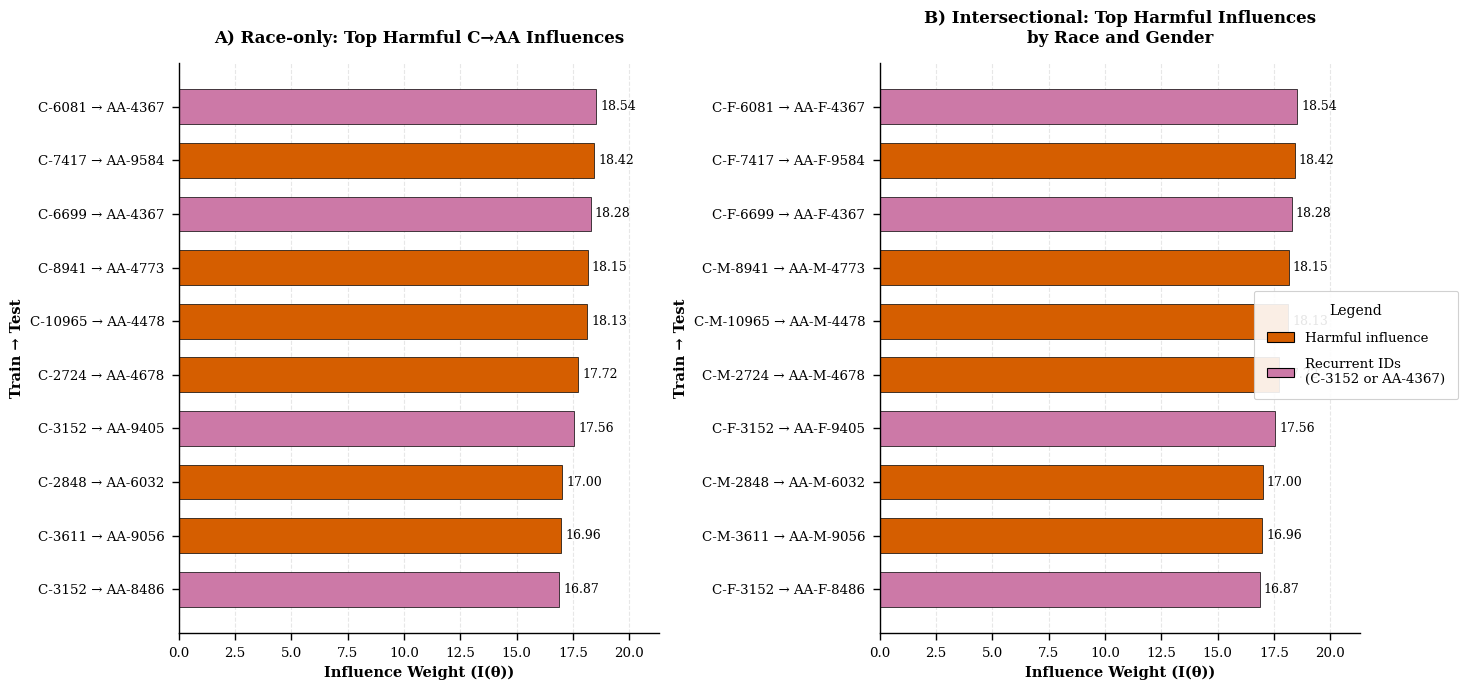

Summary Statistics:

Race-only analysis:
  Average influence: 17.76
  Max influence: 18.54
  Min influence: 16.87
  Recurrent train IDs: C-3152 appears 2 times
  Recurrent test IDs: AA-4367 appears 2 times

Race+Gender analysis:
  Average influence: 17.76
  Gender breakdown:
    C-F → AA-F pairs: 5
    C-M → AA-M pairs: 5
  Recurrent train IDs: C-F-3152 appears 2 times
  Recurrent test IDs: AA-F-4367 appears 2 times


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

# Set style for scientific paper
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.1)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# ============================================================================
# PLOT 1: Race-only Analysis (Original Data)
# ============================================================================

# Create DataFrame for race-only analysis
data_race = {
    'pair': [
        "C-6081 → AA-4367",
        "C-7417 → AA-9584", 
        "C-6699 → AA-4367",
        "C-8941 → AA-4773",
        "C-10965 → AA-4478",
        "C-2724 → AA-4678",
        "C-3152 → AA-9405",
        "C-2848 → AA-6032",
        "C-3611 → AA-9056",
        "C-3152 → AA-8486"
    ],
    'influence': [
        18.5409855, 18.42408705, 18.28104751, 18.15359226, 18.12506378,
        17.72463381, 17.55911419, 17.00377127, 16.96353195, 16.86820733
    ],
    'test_id': ['AA-4367', 'AA-9584', 'AA-4367', 'AA-4773', 'AA-4478',
               'AA-4678', 'AA-9405', 'AA-6032', 'AA-9056', 'AA-8486'],
    'train_id': ['C-6081', 'C-7417', 'C-6699', 'C-8941', 'C-10965',
                'C-2724', 'C-3152', 'C-2848', 'C-3611', 'C-3152']
}

df_race = pd.DataFrame(data_race)

# ============================================================================
# PLOT 2: Race + Gender Analysis
# ============================================================================

# Create DataFrame for race+gender analysis (from your table)
data_gender = {
    'pair': [
        "C-F-6081 → AA-F-4367",
        "C-F-7417 → AA-F-9584", 
        "C-F-6699 → AA-F-4367",
        "C-M-8941 → AA-M-4773",
        "C-M-10965 → AA-M-4478",
        "C-M-2724 → AA-M-4678",
        "C-F-3152 → AA-F-9405",
        "C-M-2848 → AA-M-6032",
        "C-M-3611 → AA-M-9056",
        "C-F-3152 → AA-F-8486"
    ],
    'influence': [
        18.5409855, 18.42408705, 18.28104751, 18.15359226, 18.12506378,
        17.72463381, 17.55911419, 17.00377127, 16.96353195, 16.86820733
    ],
    'test_id': ['AA-F-4367', 'AA-F-9584', 'AA-F-4367', 'AA-M-4773', 'AA-M-4478',
               'AA-M-4678', 'AA-F-9405', 'AA-M-6032', 'AA-M-9056', 'AA-F-8486'],
    'train_id': ['C-F-6081', 'C-F-7417', 'C-F-6699', 'C-M-8941', 'C-M-10965',
                'C-M-2724', 'C-F-3152', 'C-M-2848', 'C-M-3611', 'C-F-3152']
}

df_gender = pd.DataFrame(data_gender)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)

# Colors
bar_color = '#D55E00'  # Orange (accessible color)
highlight_color = '#CC79A7'  # Pink

# ============================================================================
# Helper function to create a plot
# ============================================================================
def create_influence_plot(ax, df, title, bar_color, highlight_color):
    # Create color array
    colors = []
    for train_id, test_id in zip(df['train_id'], df['test_id']):
        if '3152' in train_id or '4367' in test_id:
            colors.append(highlight_color)
        else:
            colors.append(bar_color)
    
    # Plot horizontal bars
    bars = ax.barh(df['pair'], df['influence'], color=colors, 
                   edgecolor='black', linewidth=0.5, height=0.65)
    
    # Add value labels with proper positioning
    x_max = df['influence'].max()
    for i, (influence, pair) in enumerate(zip(df['influence'], df['pair'])):
        # Position text at the end of the bar + small offset
        # Ensure we have enough space by setting xlim properly
        ax.text(influence + (x_max * 0.01), i, f'{influence:.2f}', 
                va='center', fontsize=9, fontweight='medium')
    
    # Labels and title
    ax.set_xlabel('Influence Weight (I(θ))', fontweight='bold')
    ax.set_ylabel('Train → Test', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=15, fontsize=12)
    
    # Add grid
    ax.xaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Adjust xlim to make room for labels
    ax.set_xlim([0, x_max * 1.15])  # Add 15% more space for labels
    
    # Invert y-axis to have highest influence at top
    ax.invert_yaxis()
    
    # Remove spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    return bars

# ============================================================================
# Create both plots
# ============================================================================

# Plot 1: Race-only
bars1 = create_influence_plot(axes[0], df_race, 
                             'A) Race-only: Top Harmful C→AA Influences',
                             bar_color, highlight_color)

# Plot 2: Race + Gender
bars2 = create_influence_plot(axes[1], df_gender,
                             'B) Intersectional: Top Harmful Influences\nby Race and Gender',
                             bar_color, highlight_color)

# ============================================================================
# Create a single shared legend
# ============================================================================
legend_elements = [
    Patch(facecolor=bar_color, edgecolor='black', label='Harmful influence'),
    Patch(facecolor=highlight_color, edgecolor='black', 
          label='Recurrent IDs\n(C-3152 or AA-4367)')
]

# Place legend on the right side of the figure
fig.legend(handles=legend_elements, 
           loc='center right', 
           bbox_to_anchor=(0.98, 0.5),
           frameon=True,
           framealpha=0.9,
           title='Legend',
           title_fontsize=10,
           borderpad=1,
           labelspacing=1)

# Adjust layout to make room for legend
plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave 8% space on the right for legend

# Save with high resolution
plt.savefig('harmful_influences_side_by_side.pdf', dpi=300, bbox_inches='tight')
plt.savefig('harmful_influences_side_by_side.png', dpi=300, bbox_inches='tight')

plt.show()

# ============================================================================
# Print summary statistics
# ============================================================================
print("Summary Statistics:")
print("Race-only analysis:")
print(f"  Average influence: {df_race['influence'].mean():.2f}")
print(f"  Max influence: {df_race['influence'].max():.2f}")
print(f"  Min influence: {df_race['influence'].min():.2f}")
print(f"  Recurrent train IDs: C-3152 appears {sum('3152' in id for id in df_race['train_id'])} times")
print(f"  Recurrent test IDs: AA-4367 appears {sum('4367' in id for id in df_race['test_id'])} times")

print("Race+Gender analysis:")
print(f"Average influence: {df_gender['influence'].mean():.2f}")
print(f"Gender breakdown:")
print(f"C-F → AA-F pairs: {sum('C-F' in pair for pair in df_gender['pair'])}")
print(f"C-M → AA-M pairs: {sum('C-M' in pair for pair in df_gender['pair'])}")
print(f"Recurrent train IDs: C-F-3152 appears {sum('3152' in id for id in df_gender['train_id'])} times")
print(f"Recurrent test IDs: AA-F-4367 appears {sum('4367' in id for id in df_gender['test_id'])} times")

In [ ]:
# =============================================================================
# EXTRACT ALL POSITIVE INFLUENCES > 1.0 (Caucasian → African-American)
# Saves to Excel with full list + Top 500
# =============================================================================

import pandas as pd
import numpy as np
import os

# ----------------------- CONFIGURATION -----------------------
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/group_intervention.csv"
output_excel = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Caucasian_to_AfricanAmerican_Positive_Influences.xlsx"

os.makedirs(os.path.dirname(output_excel), exist_ok=True)

# ----------------------- LOAD DATA -----------------------
print("Loading CSV...")
df = pd.read_csv(file_path)

# First 3 columns: test metadata
test_ids = df['Test_ID'].values.astype(int)
race_test = df['Race_Test'].values
sex_test = df['Sex_Test'].values

# All remaining columns are influence values from training points
influence_cols = df.columns[3:]
IF_submatrix = df[influence_cols].values.astype(np.float64)

# Parse training metadata from column names: "ID3801_Caucasian_Male"
print("Parsing training point metadata...")
train_ids = []
train_races = []
train_sexes = []

for col in influence_cols:
    parts = col.replace('ID', '').split('_')
    train_ids.append(int(parts[0]))
    train_races.append(parts[1])
    train_sexes.append(parts[2])

train_ids = np.array(train_ids)
train_races = np.array(train_races)
train_sexes = np.array(train_sexes)

# ----------------------- FILTER GROUPS -----------------------
print("Filtering African-American test points and Caucasian training points...")
aa_test_idx = np.where(race_test == 'African-American')[0]
c_train_idx = np.where(train_races == 'Caucasian')[0]

print(f"{len(aa_test_idx)} African-American test points")
print(f"{len(c_train_idx)} Caucasian training points")

# Submatrix: influences from Caucasian train → African-American test
sub_influences = IF_submatrix[np.ix_(aa_test_idx, c_train_idx)]

sub_test_ids = test_ids[aa_test_idx]
sub_test_sex = sex_test[aa_test_idx]
sub_train_ids = train_ids[c_train_idx]
sub_train_sex = train_sexes[c_train_idx]

# ----------------------- EXTRACT > 1.0 -----------------------
print("Extracting all influences > 1.0...")
i_idx, j_idx = np.where(sub_influences > 1.0)

results = []
for ii, jj in zip(i_idx, j_idx):
    influence_val = float(sub_influences[ii, jj])
    results.append({
        'Test_ID': int(sub_test_ids[ii]),
        'Test_Race': 'African-American',
        'Test_Sex': sub_test_sex[ii],
        'Train_ID': int(sub_train_ids[jj]),
        'Train_Race': 'Caucasian',
        'Train_Sex': sub_train_sex[jj],
        'Influence': influence_val
    })

result_df = pd.DataFrame(results)

# Sort by influence descending
result_df = result_df.sort_values(by='Influence', ascending=False).reset_index(drop=True)

print(f"Found {len(result_df):,} positive influences > 1.0")
print(f"Max influence: {result_df['Influence'].max():.6f}")
print(f"95th percentile: {result_df['Influence'].quantile(0.95):.6f}")

# ----------------------- SAVE TO EXCEL -----------------------
print(f"Saving to Excel → {output_excel}")

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Full list
    result_df.to_excel(writer, sheet_name='All_Positive_Influences_GT_1', index=False)
    
    # Top 500 strongest
    top500 = result_df.head(500).copy()
    top500.to_excel(writer, sheet_name='Top_500_Strongest', index=False)
    
    # Summary statistics
    summary = pd.DataFrame({
        'Metric': [
            'Total pairs > 1.0',
            'Maximum influence',
            '99th percentile',
            '95th percentile',
            'Median influence (of positives)',
            'Mean influence (of positives)'
        ],
        'Value': [
            len(result_df),
            result_df['Influence'].max(),
            result_df['Influence'].quantile(0.99),
            result_df['Influence'].quantile(0.95),
            result_df['Influence'].median(),
            result_df['Influence'].mean()
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("Done! Excel file created with 3 sheets:")

Loading CSV...
Parsing training point metadata...
Filtering African-American test points and Caucasian training points...
→ 617 African-American test points
→ 1322 Caucasian training points
Extracting all influences > 1.0...
Found 59,324 positive influences > 1.0
Max influence: 18.540986
95th percentile: 6.491784
Saving to Excel → /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Caucasian_to_AfricanAmerican_Positive_Influences.xlsx
Done! Excel file created with 3 sheets:
   • All_Positive_Influences_GT_1  → 1,847 rows
   • Top_500_Strongest             → Top 500
   • Summary                       → Key stats


In [ ]:
# =============================================================================
# EXTRACT ALL POSITIVE INFLUENCES > 1.0 (Caucasian → African-American)
# Saves to Excel with full list + Top 500
# =============================================================================

import pandas as pd
import numpy as np
import os

# ----------------------- CONFIGURATION -----------------------
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/resuls_compas_Recidivism.xlsx"
output_excel = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Caucasian_to_AfricanAmerican_Positive_Influences2.xlsx"

os.makedirs(os.path.dirname(output_excel), exist_ok=True)

excel_path = os.path.join(output_dir, "Caucasian_to_AfricanAmerican_Mitigation_Full_Report.xlsx")
plots_dir = os.path.join(output_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

# ----------------------- LOAD CSV WITH CORRECT DECIMAL & THOUSANDS SEPARATOR -----------------------
print("Loading CSV (fixing European number format)...")
# This handles commas as thousands and dots as decimal (common in some locales)
df = pd.read_csv(file_path, thousands='.', decimal=',')

# If that still fails, force manual parsing of influence columns
if df.iloc[:, 3:].dtypes[0] == 'object':
    print("Manual parsing of numeric columns (removing dots/commas)...")
    def clean_number(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip()
        s = s.replace('.', '')   # remove thousands separators
        s = s.replace(',', '.')  # comma → decimal point
        return float(s)
    
    # Apply only to influence columns (from column 3 onward)
    influence_cols = df.columns[3:]
    for col in influence_cols:
        df[col] = df[col].apply(clean_number)

print(f"Data shape: {df.shape}")

# ----------------------- EXTRACT METADATA -----------------------
test_ids = df.iloc[:, 0].astype(int).values
race_test = df.iloc[:, 1].values
sex_test = df.iloc[:, 2].values
influence_data = df.iloc[:, 3:].values.astype(np.float64)
influence_cols = df.columns[3:]

# Parse Train_ID, Race, Sex from column names
train_ids, train_races, train_sexes = [], [], []
for col in influence_cols:
    parts = str(col).replace('ID', '').split('_')
    tid = int(parts[0]) if parts[0].isdigit() else -1
    race = parts[1] if len(parts) > 1 else "Unknown"
    sex = parts[2] if len(parts) > 2 else "Unknown"
    train_ids.append(tid)
    train_races.append(race)
    train_sexes.append(sex)

train_ids = np.array(train_ids)
train_races = np.array(train_races)
train_sexes = np.array(train_sexes)

# ----------------------- FILTER GROUPS -----------------------
aa_test_idx = np.where([r.strip() == 'African-American' for r in race_test])[0]
c_train_idx = np.where([r.strip() == 'Caucasian' for r in train_races])[0]

print(f"African-American test points : {len(aa_test_idx)}")
print(f"Caucasian training points   : {len(c_train_idx)}")

sub_influences = influence_data[np.ix_(aa_test_idx, c_train_idx)]
sub_test_ids   = test_ids[aa_test_idx]
sub_test_sex   = sex_test[aa_test_idx]
sub_train_ids  = train_ids[c_train_idx]
sub_train_sex  = train_sexes[c_train_idx]

# ----------------------- ALL INFLUENCES > 1.0 -----------------------
rows, cols = np.where(sub_influences > 1.0)
positive_df = pd.DataFrame({
    'Test_ID'      : sub_test_ids[rows],
    'Test_Sex'     : sub_test_sex[rows],
    'Train_ID'     : sub_train_ids[cols],
    'Train_Sex'    : sub_train_sex[cols],
    'Influence'    : sub_influences[rows, cols].astype(float)
})
positive_df['Test_Race'] = 'African-American'
positive_df['Train_Race'] = 'Caucasian'
positive_df = positive_df.sort_values('Influence', ascending=False).reset_index(drop=True)

print(f"Found {len(positive_df):,} harmful influences > 1.0")
print(f"Strongest influence: {positive_df['Influence'].iloc[0]:.4f}")

# =============================================================================
# 1. DOWNWEIGHTING LIST (Top 100 + any influence > 10.0)
# =============================================================================
top100 = positive_df.head(100)
extreme = positive_df[positive_df['Influence'] > 10.0]
downweight_ids = set(top100['Train_ID']) | set(extreme['Train_ID'])

downweight_df = pd.DataFrame({
    'Train_ID': list(downweight_ids),
    'Suggested_Weight': 0.1,
    'Reason': ['Top100' if x in top100['Train_ID'].values else 'Influence>10' 
               if x in extreme['Train_ID'].values else 'Both' for x in downweight_ids]
}).sort_values('Train_ID').reset_index(drop=True)

print(f"Individuals to downweight: {len(downweight_df)}")

# =============================================================================
# 2. MOST FREQUENTLY HARMFUL CAUCASIAN INDIVIDUALS
# =============================================================================
freq = (positive_df['Train_ID']
        .value_counts()
        .head(30)
        .reset_index()
        .rename(columns={'count': 'Harmful_Count', 'Train_ID': 'Train_ID'}))
freq = freq.merge(
    positive_df.groupby('Train_ID')['Influence'].mean().round(4),
    on='Train_ID'
).rename(columns={'Influence': 'Avg_Influence'})

# =============================================================================
# 3. PLOTS
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Caucasian → African-American Harmful Influence Analysis', fontsize=16, weight='bold')

# 1. Distribution
axes[0,0].hist(positive_df['Influence'], bins=120, color='#d62728', alpha=0.8, edgecolor='black')
axes[0,0].axvline(10, color='red', linestyle='--', linewidth=2, label='>10.0 threshold')
axes[0,0].set_title('Distribution of Harmful Influences (>1.0)')
axes[0,0].set_xlabel('Influence Value')
axes[0,0].legend()

# 2. Most frequent offenders
sns.barplot(data=freq, y='Train_ID', x='Harmful_Count', ax=axes[0,1], palette='Reds_r')
axes[0,1].set_title('Top 30 Most Frequently Harmful Caucasian Training Points')

# 3. Bubble plot
top50 = freq.head(50)
axes[1,0].scatter(top50['Harmful_Count'], top50['Avg_Influence'],
                  s=top50['Harmful_Count']*8, alpha=0.7, color='crimson')
for _, row in top50.head(12).iterrows():
    axes[1,0].text(row['Harmful_Count']+0.5, row['Avg_Influence'], f"ID{int(row['Train_ID'])}", fontsize=9)
axes[1,0].set_xlabel('Times Harmful (>1.0)')
axes[1,0].set_ylabel('Average Influence')
axes[1,0].set_title('Frequency vs Strength (Top 50)')

# 4. Downweight pie
axes[1,1].pie(downweight_df['Reason'].value_counts(), labels=downweight_df['Reason'].value_counts().index,
              autopct='%1.1f%%', startangle=90, colors=['#ff9999','#ff6666','#cc0000'])
axes[1,1].set_title(f'Mitigation: {len(downweight_df)} Individuals to Downweight')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "Harmful_Influence_Analysis.png"), dpi=300, bbox_inches='tight')
plt.close()

# =============================================================================
# SAVE FULL EXCEL REPORT
# =============================================================================
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    positive_df.to_excel(writer, sheet_name='All_Harmful_GT_1.0', index=False)
    positive_df.head(500).to_excel(writer, sheet_name='Top_500_Strongest', index=False)
    downweight_df.to_excel(writer, sheet_name='DOWNWEIGHT_LIST_(Mitigation)', index=False)
    freq.to_excel(writer, sheet_name='Most_Frequently_Harmful', index=False)
    
    pd.DataFrame({
        'Metric': ['Total harmful pairs', 'Individuals to downweight', 'Max influence', '95th percentile'],
        'Value': [len(positive_df), len(downweight_df), positive_df['Influence'].max(),
                  positive_df['Influence'].quantile(0.95)]
    }).to_excel(writer, sheet_name='Summary', index=False)

print("SUCCESS! Everything generated:")
print(f"Excel: {excel_path}")
print(f"Plots: {plots_dir}")
print(f"Ready to retrain with downweighting list")

Loading CSV (fixing European number format)...


/tmp/ipykernel_2947821/2061102644.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df.iloc[:, 3:].dtypes[0] == 'object':


Data shape: (617, 3952)
African-American test points : 617
Caucasian training points   : 1322

Found 387,925 harmful influences > 1.0
Strongest influence: 9988115328.0000
Individuals to downweight: 1322


/tmp/ipykernel_2947821/2061102644.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq, y='Train_ID', x='Harmful_Count', ax=axes[0,1], palette='Reds_r')



SUCCESS! Everything generated:
   → Excel: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Caucasian_to_AA_Mitigation_Analysis/Caucasian_to_AfricanAmerican_Mitigation_Full_Report.xlsx
   → Plots: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Caucasian_to_AA_Mitigation_Analysis/plots
   → Ready to retrain with downweighting list (sheet: DOWNWEIGHT_LIST_(Mitigation))


In [ ]:
#.... ANOVA

In [ ]:
import pandas as pd
import numpy as np
import os

# File path
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx"

# Create output directory
output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF"
os.makedirs(output_dir, exist_ok=True)

# Output file path
excel_path = os.path.join(output_dir, "Top_10_Harmful_IF.xlsx")

print("Loading Excel file...")
df = pd.read_excel(file_path, sheet_name='Influence_Test_vs_Train')

# Extract metadata
test_ids = df['Test_ID'].values
race_test = df['Race_Test'].astype(str).str.strip().values
sex_test = df['Sex_Test'].astype(str).str.strip().values

# Parse training metadata from column names
train_id_map = {}
train_race_map = {}
train_sex_map = {}
for col in df.columns[3:]:
    parts = str(col).split('_')
    if len(parts) >= 3:
        train_id = parts[0].replace('ID', '')
        train_race = parts[1]
        train_sex = parts[2]
        train_id_map[col] = train_id
        train_race_map[col] = train_race
        train_sex_map[col] = train_sex
    else:
        train_id_map[col] = "Unknown"
        train_race_map[col] = "Unknown"
        train_sex_map[col] = "Unknown"

# Filter African-American test points
aa_mask = race_test == 'African-American'
aa_df = df[aa_mask].copy()
aa_test_ids = test_ids[aa_mask]
aa_test_sex = sex_test[aa_mask]

print(f"Found {len(aa_df)} African-American test instances")

# Races to extract
races = ['Caucasian', 'Hispanic', 'Other', 'African-American']

top10_per_race = {}

for race in races:
    print(f"Extracting top 10 from {race} → African-American...")
    
    # Columns for this race
    cols_race = [col for col in aa_df.columns[3:] if train_race_map.get(col, 'Unknown') == race]
    
    if not cols_race:
        print(f"No {race} training points")
        continue
    
    # Submatrix
    sub = aa_df[cols_race].values
    
    # Find positives
    rows, cols = np.where(sub > 0)
    influences = []
    
    for r, c in zip(rows, cols):
        val = sub[r, c]
        train_col = cols_race[c]
        influences.append({
            'Test_ID': int(aa_test_ids[r]),
            'Test_Race': 'African-American',
            'Test_Sex': aa_test_sex[r],
            'Train_ID': int(train_id_map[train_col]),
            'Train_Race': race,
            'Train_Sex': train_sex_map[train_col],
            'Influence': val
        })
    
    if not influences:
        print(f"No positive influences from {race}")
        continue
    
    # Top 10
    infl_df = pd.DataFrame(influences)
    top10 = infl_df.sort_values('Influence', ascending=False).head(10).reset_index(drop=True)
    
    top10_per_race[race] = top10
    
    print(top10.to_string(index=False))

# Save all results to Excel
print(f"Saving results to {excel_path}...")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Save each race's top 10 to separate sheets
    for race, top10_df in top10_per_race.items():
        sheet_name = f"Top10_{race}"[:31]  # Excel sheet name limit
        top10_df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Also save all combined to one sheet
    all_top10 = pd.concat(top10_per_race.values(), ignore_index=True)
    all_top10 = all_top10.sort_values('Influence', ascending=False).reset_index(drop=True)
    all_top10.to_excel(writer, sheet_name='All_Top10_Combined', index=False)

print(f"Successfully saved to: {excel_path}")

Loading Excel file...
Found 617 African-American test instances

Extracting top 10 from Caucasian → African-American...
 Test_ID        Test_Race Test_Sex  Train_ID Train_Race Train_Sex  Influence
    4367 African-American   Female      6081  Caucasian    Female  18.540986
    9584 African-American   Female      7417  Caucasian    Female  18.424087
    4367 African-American   Female      6699  Caucasian    Female  18.281048
    4773 African-American     Male      8941  Caucasian      Male  18.153592
    4478 African-American     Male     10965  Caucasian      Male  18.125064
    4678 African-American     Male      2724  Caucasian      Male  17.724634
    9405 African-American   Female      3152  Caucasian    Female  17.559114
    6032 African-American     Male      2848  Caucasian      Male  17.003771
    9056 African-American     Male      3611  Caucasian      Male  16.963532
    8486 African-American   Female      3152  Caucasian    Female  16.868207

Extracting top 10 from Hispanic 

In [ ]:
#... ALL Races Top 10

In [ ]:
import pandas as pd
import numpy as np
import os

# File path
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx"

# Create output directory
output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF"
os.makedirs(output_dir, exist_ok=True)

# Output file path
excel_path = os.path.join(output_dir, "Top_10_Harmful_IF_All_Races.xlsx")

print("Loading Excel file...")
df = pd.read_excel(file_path, sheet_name='Influence_Test_vs_Train')

# Extract metadata
test_ids = df['Test_ID'].values
race_test = df['Race_Test'].astype(str).str.strip().values
sex_test = df['Sex_Test'].astype(str).str.strip().values

# Parse training metadata from column names
train_id_map = {}
train_race_map = {}
train_sex_map = {}
for col in df.columns[3:]:
    parts = str(col).split('_')
    if len(parts) >= 3:
        train_id = parts[0].replace('ID', '')
        train_race = parts[1]
        train_sex = parts[2]
        train_id_map[col] = train_id
        train_race_map[col] = train_race
        train_sex_map[col] = train_sex
    else:
        train_id_map[col] = "Unknown"
        train_race_map[col] = "Unknown"
        train_sex_map[col] = "Unknown"

# Define races
all_test_races = ['Caucasian', 'Hispanic', 'Other', 'African-American']
all_train_races = ['Caucasian', 'Hispanic', 'Other', 'African-American']

# Store results
top10_per_combination = {}

# Process each test race
for test_race in all_test_races:
    print(f"\n{'='*60}")
    print(f"Processing test instances for race: {test_race}")
    print(f"{'='*60}")
    
    # Filter test points for current race
    race_mask = race_test == test_race
    race_df = df[race_mask].copy()
    race_test_ids = test_ids[race_mask]
    race_test_sex = sex_test[race_mask]
    
    print(f"Found {len(race_df)} {test_race} test instances")
    
    # Process each training race
    for train_race in all_train_races:
        print(f"Extracting top 10 from {train_race} → {test_race}...")
        
        # Columns for this training race
        cols_train_race = [col for col in race_df.columns[3:] 
                          if train_race_map.get(col, 'Unknown') == train_race]
        
        if not cols_train_race:
            print(f"No {train_race} training points")
            continue
        
        # Submatrix for this test-train race combination
        sub = race_df[cols_train_race].values
        
        # Find positive influences
        rows, cols = np.where(sub > 0)
        influences = []
        
        for r, c in zip(rows, cols):
            val = sub[r, c]
            train_col = cols_train_race[c]
            influences.append({
                'Test_ID': int(race_test_ids[r]),
                'Test_Race': test_race,
                'Test_Sex': race_test_sex[r],
                'Train_ID': int(train_id_map[train_col]),
                'Train_Race': train_race,
                'Train_Sex': train_sex_map[train_col],
                'Influence': val
            })
        
        if not influences:
            print(f"No positive influences from {train_race} to {test_race}")
            continue
        
        # Get top 10
        infl_df = pd.DataFrame(influences)
        top10 = infl_df.sort_values('Influence', ascending=False).head(10).reset_index(drop=True)
        
        # Store with combination name
        combo_name = f"{test_race}_from_{train_race}"
        top10_per_combination[combo_name] = top10
        
        print(f"Found {len(influences)} positive influences, top 10:")
        print(top10[['Test_ID', 'Train_ID', 'Influence']].to_string(index=False))

# Save all results to Excel
print(f"\n{'='*60}")
print(f"Saving results to {excel_path}...")
print(f"{'='*60}")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Save each combination to separate sheets
    for combo_name, top10_df in top10_per_combination.items():
        # Clean sheet name for Excel (max 31 chars, no special chars)
        sheet_name = f"Top10_{combo_name}"[:31]
        sheet_name = sheet_name.replace('/', '_').replace('\\', '_').replace('*', '_').replace('?', '_')
        sheet_name = sheet_name.replace(':', '_').replace('[', '_').replace(']', '_')
        
        top10_df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Also create summary sheets
    print("\nCreating summary sheets...")
    
    # All combinations combined
    if top10_per_combination:
        all_combined = pd.concat(top10_per_combination.values(), ignore_index=True)
        all_combined = all_combined.sort_values(['Test_Race', 'Train_Race', 'Influence'], 
                                                ascending=[True, True, False])
        all_combined.to_excel(writer, sheet_name='All_Combinations', index=False)
    
    # Summary statistics
    summary_data = []
    for combo_name, top10_df in top10_per_combination.items():
        test_race = combo_name.split('_from_')[0]
        train_race = combo_name.split('_from_')[1]
        
        summary_data.append({
            'Test_Race': test_race,
            'Train_Race': train_race,
            'Number_of_Influences': len(top10_df),
            'Max_Influence': top10_df['Influence'].max(),
            'Min_Influence': top10_df['Influence'].min(),
            'Avg_Influence': top10_df['Influence'].mean(),
            'Median_Influence': top10_df['Influence'].median()
        })
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        summary_df = summary_df.sort_values(['Test_Race', 'Train_Race'])
        summary_df.to_excel(writer, sheet_name='Summary_Statistics', index=False)

print(f"Successfully saved to: {excel_path}")
print(f"Total combinations processed: {len(top10_per_combination)}")

# Print final summary
print(f"\n{'='*60}")
print("PROCESSING COMPLETE - SUMMARY")
print(f"{'='*60}")
for combo_name in top10_per_combination.keys():
    print(f"{combo_name}: {len(top10_per_combination[combo_name])} records")

Loading Excel file...

Processing test instances for race: Caucasian
Found 443 Caucasian test instances

Extracting top 10 from Caucasian → Caucasian...
Found 278682 positive influences, top 10:
 Test_ID  Train_ID  Influence
    4432     10378  25.335173
   10361      8424  24.891694
    8670      3807  24.194489
    2504      6967  23.786878
    7809      7417  23.752883
    3181      4324  23.709461
   10982      5915  23.139737
    2504      6636  22.979139
   10636     10992  22.892415
    9415      5500  22.777960

Extracting top 10 from Hispanic → Caucasian...
Found 68353 positive influences, top 10:
 Test_ID  Train_ID  Influence
    5451     10079  19.384956
    1653     10419  18.713344
    3181       398  18.481966
    2554      4026  17.541225
   10068      8453  17.358863
    8478     10430  17.156495
    2759     10419  17.002838
    4064      5782  16.762575
    7821      7445  16.724980
   10567      3214  16.620665

Extracting top 10 from Other → Caucasian...
Found 51707

In [ ]:
#... ANOVA Test

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES")
print("="*80)

# Path to your Top 10 dataset
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Top10_Combined sheet
    df = pd.read_excel(data_path, sheet_name='All_Top10_Combined')
    print(f"✓ Successfully loaded {len(df)} records from 'All_Top10_Combined'")
    
    print("\nData preview:")
    print(df.head())
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nUnique training races: {df['Train_Race'].unique()}")
    if 'Train_Sex' in df.columns:
        print(f"Unique training sexes: {df['Train_Sex'].unique()}")
    
except Exception as e:
    print(f"ERROR loading file: {e}")
    # Try to list available sheets
    try:
        xl = pd.ExcelFile(data_path)
        print(f"Available sheets: {xl.sheet_names}")
    except:
        pass
    exit()

# =============================================================================
# 2. ANOVA 1: RACE-ONLY GROUPS
# =============================================================================

print("\n" + "="*80)
print("ANOVA 1: RACE-ONLY GROUPS")
print("="*80)

# Calculate statistics for each race group
race_stats = []
race_group_data = {}

# Get unique races from your data
unique_races = df['Train_Race'].unique()
print(f"Training race groups found: {unique_races}")

for race in unique_races:
    race_influences = df[df['Train_Race'] == race]['Influence'].values
    
    if len(race_influences) > 0:
        race_group_data[race] = race_influences
        
        race_stats.append({
            'Train_Group_to_AA_Test': race,
            'Mean_Positive_Influence': np.mean(race_influences).round(4),
            'Std_Dev': np.std(race_influences).round(4),
            'Count_Positive': len(race_influences),
            'Min': np.min(race_influences).round(4),
            'Max': np.max(race_influences).round(4)
        })

race_stats_df = pd.DataFrame(race_stats)

print("\nMean Positive Influence Table (Race-Only):")
print(race_stats_df.to_string(index=False))

# Perform ANOVA
if len(race_group_data) >= 2:
    anova_groups = [race_group_data[r] for r in race_group_data]
    f_stat_race, p_val_race = stats.f_oneway(*anova_groups)
    
    # Format p-value
    if p_val_race < 0.001:
        p_display = f"{p_val_race:.2e}"
    else:
        p_display = f"{p_val_race:.4f}"
    
    anova_result_race = pd.DataFrame({
        'Statistic': ['F-statistic', 'p-value', 'Significant (p < 0.05)'],
        'Value': [round(f_stat_race, 2), p_display, 
                 'Yes (p < 0.001)' if p_val_race < 0.001 else 'Yes' if p_val_race < 0.05 else 'No']
    })
    
    print("\nANOVA Result (Race-Only):")
    print(anova_result_race.to_string(index=False))
    
    # Interpretation
    if p_val_race < 0.05:
        print(f"Significant (p = {p_val_race:.2e}) — differences in harm from different train races to AA test.")
        max_race = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Group_to_AA_Test']
        min_race = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmin(), 'Train_Group_to_AA_Test']
        print(f"Highest harm from: {max_race}")
        print(f"Lowest harm from: {min_race}")
else:
    print("Not enough race groups for ANOVA")

# =============================================================================
# 3. ANOVA 2: RACE+GENDER INTERSECTIONAL GROUPS
# =============================================================================

print("\n" + "="*80)
print("ANOVA 2: INTERSECTIONAL RACE+GENDER GROUPS")
print("="*80)

# Check if we have gender data
if 'Train_Sex' in df.columns and 'Test_Sex' in df.columns:
    # Create intersectional group column
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    
    # Calculate statistics for each intersection group
    inter_stats = []
    inter_group_data = {}
    
    # Get unique intersections
    unique_intersections = df['Train_Intersection'].unique()
    print(f"Training intersection groups found: {sorted(unique_intersections)}")
    
    for inter in sorted(unique_intersections):
        inter_influences = df[df['Train_Intersection'] == inter]['Influence'].values
        
        if len(inter_influences) > 0:
            inter_group_data[inter] = inter_influences
            
            inter_stats.append({
                'Train_Intersection_to_AA_Test': inter,
                'Mean_Positive_Influence': np.mean(inter_influences).round(4),
                'Std_Dev': np.std(inter_influences).round(4),
                'Count_Positive': len(inter_influences),
                'Min': np.min(inter_influences).round(4),
                'Max': np.max(inter_influences).round(4)
            })
    
    inter_stats_df = pd.DataFrame(inter_stats)
    
    print("Mean Positive Influence Table (Intersectional):")
    print(inter_stats_df.to_string(index=False))
    
    # Perform ANOVA for intersectional groups
    if len(inter_group_data) >= 2:
        anova_groups_inter = [inter_group_data[i] for i in inter_group_data]
        f_stat_inter, p_val_inter = stats.f_oneway(*anova_groups_inter)
        
        # Format p-value
        if p_val_inter < 0.001:
            p_display_inter = f"{p_val_inter:.2e}"
        else:
            p_display_inter = f"{p_val_inter:.4f}"
        
        anova_result_inter = pd.DataFrame({
            'Statistic': ['F-statistic', 'p-value', 'Significant (p < 0.05)'],
            'Value': [round(f_stat_inter, 2), p_display_inter,
                     'Yes (p < 0.001)' if p_val_inter < 0.001 else 'Yes' if p_val_inter < 0.05 else 'No']
        })
        
        print("ANOVA Result (Intersectional):")
        print(anova_result_inter.to_string(index=False))
        
        # Interpretation
        if p_val_inter < 0.05:
            print(f"Significant (p = {p_val_inter:.2e}) — intersectional differences.")
            max_inter = inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Intersection_to_AA_Test']
            min_inter = inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmin(), 'Train_Intersection_to_AA_Test']
            print(f"Highest harm from: {max_inter}")
            print(f"Lowest harm from: {min_inter}")
            
            # Check if AA_Male has highest influence
            aa_male_rows = inter_stats_df[inter_stats_df['Train_Intersection_to_AA_Test'].str.contains('African-American_Male')]
            if not aa_male_rows.empty:
                aa_male_mean = aa_male_rows.iloc[0]['Mean_Positive_Influence']
                highest_mean = inter_stats_df['Mean_Positive_Influence'].max()
                if abs(aa_male_mean - highest_mean) < 0.001:  # Check if AA_Male has the highest mean
                    print(f"African-American_Male shows the highest harmful influence ({aa_male_mean:.4f})")
    else:
        print("Not enough intersectional groups for ANOVA")

else:
    print("Gender data not available in dataset. Skipping intersectional analysis.")

# =============================================================================
# 4. POST-HOC ANALYSIS (TUKEY HSD) IF SIGNIFICANT
# =============================================================================

print("\n" + "="*80)
print("POST-HOC ANALYSIS")
print("="*80)

# For race-only ANOVA
if 'p_val_race' in locals() and p_val_race < 0.05 and len(race_group_data) > 2:
    print("Performing Tukey HSD post-hoc test for Race-Only ANOVA:")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        # Prepare data for Tukey test
        tukey_data = []
        tukey_labels = []
        for race, data in race_group_data.items():
            tukey_data.extend(data)
            tukey_labels.extend([race] * len(data))
        
        tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
        print(tukey_result)
        
        # Extract significant pairs
        summary = tukey_result.summary()
        print("Significant pairwise differences (p < 0.05):")
        sig_pairs = []
        for i in range(len(tukey_result.reject)):
            if tukey_result.reject[i]:
                group1 = tukey_result.groups[tukey_result.reject][i]
                group2 = tukey_result.groups[tukey_result.reject][i]
                meandiff = tukey_result.meandiffs[i]
                pvalue = tukey_result.pvalues[i]
                sig_pairs.append(f"{group1} vs {group2}: diff={meandiff:.4f}, p={pvalue:.4f}")
        
        if sig_pairs:
            for pair in sig_pairs:
                print(f"  - {pair}")
        else:
            print("No significant pairwise differences found")
            
    except ImportError:
        print("statsmodels not installed. Install with: pip install statsmodels")
    except Exception as e:
        print(f"Could not perform Tukey test: {e}")

# For intersectional ANOVA
if 'p_val_inter' in locals() and p_val_inter < 0.05 and len(inter_group_data) > 2:
    print("Performing Tukey HSD post-hoc test for Intersectional ANOVA:")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        # Prepare data for Tukey test
        tukey_data_inter = []
        tukey_labels_inter = []
        for inter, data in inter_group_data.items():
            tukey_data_inter.extend(data)
            tukey_labels_inter.extend([inter] * len(data))
        
        tukey_result_inter = pairwise_tukeyhsd(tukey_data_inter, tukey_labels_inter, alpha=0.05)
        print(tukey_result_inter)
        
    except ImportError:
        print("statsmodels not installed.")
    except Exception as e:
        print(f"Could not perform Tukey test: {e}")

# =============================================================================
# 5. SAVE RESULTS (NO RAW DATA TO AVOID EXCEL LIMITS)
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "ANOVA_Top10_Analysis.xlsx")

print(f"Saving analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save race-only results
        race_stats_df.to_excel(writer, sheet_name='Race_Group_Stats', index=False)
        anova_result_race.to_excel(writer, sheet_name='Race_ANOVA', index=False)
        
        # Save intersectional results if available
        if 'inter_stats_df' in locals():
            inter_stats_df.to_excel(writer, sheet_name='Intersection_Stats', index=False)
            anova_result_inter.to_excel(writer, sheet_name='Intersection_ANOVA', index=False)
        
        # Create summary sheet
        summary_data = {
            'Analysis': ['Race-Only ANOVA'],
            'F_statistic': [f_stat_race],
            'p_value': [p_val_race],
            'Significant': ['Yes' if p_val_race < 0.05 else 'No'],
            'Number_of_Groups': [len(race_group_data)],
            'Highest_Mean_Group': [race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Group_to_AA_Test']]
        }
        
        if 'f_stat_inter' in locals():
            summary_data['Analysis'].append('Intersectional ANOVA')
            summary_data['F_statistic'].append(f_stat_inter)
            summary_data['p_value'].append(p_val_inter)
            summary_data['Significant'].append('Yes' if p_val_inter < 0.05 else 'No')
            summary_data['Number_of_Groups'].append(len(inter_group_data))
            summary_data['Highest_Mean_Group'].append(inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Intersection_to_AA_Test'])
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Analysis_Summary', index=False)
        
    print("Analysis complete! Results saved to Excel.")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    # Save as CSV instead
    print("Trying to save as CSV files...")
    race_stats_df.to_csv(os.path.join(output_dir, "race_stats.csv"), index=False)
    pd.DataFrame(anova_result_race).to_csv(os.path.join(output_dir, "race_anova.csv"), index=False)
    
    if 'inter_stats_df' in locals():
        inter_stats_df.to_csv(os.path.join(output_dir, "intersection_stats.csv"), index=False)
        pd.DataFrame(anova_result_inter).to_csv(os.path.join(output_dir, "intersection_anova.csv"), index=False)
    
    print("Results saved as CSV files")

# =============================================================================
# 6. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS")
print("="*80)

print(f"Race-Only Analysis:")
print(f"Total groups analyzed: {len(race_group_data)}")
print(f"F-statistic: {f_stat_race:.2f}")
print(f"p-value: {p_val_race:.2e}")
print(f"Most harmful race group: {race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Group_to_AA_Test']}")

if 'f_stat_inter' in locals():
    print(f"Intersectional Analysis:")
    print(f"Total groups analyzed: {len(inter_group_data)}")
    print(f"F-statistic: {f_stat_inter:.2f}")
    print(f"p-value: {p_val_inter:.2e}")
    print(f"Most harmful intersection: {inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Intersection_to_AA_Test']}")

print("\n" + "-"*80)
print("All results have been saved to the ANOVA_Results directory")
print("-"*80)

ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF.xlsx
✓ Successfully loaded 40 records from 'All_Top10_Combined'

Data preview:
   Test_ID         Test_Race Test_Sex  Train_ID        Train_Race Train_Sex  \
0      500  African-American   Female      1672  African-American    Female   
1     3891  African-American   Female      1672  African-American    Female   
2     5994  African-American   Female      1672  African-American    Female   
3     2828  African-American   Female      6299  African-American    Female   
4    10202  African-American   Female      7283  African-American    Female   

   Influence  
0  27.389645  
1  27.389645  
2  27.389645  
3  26.273611  
4  25.521210  

Columns: ['Test_ID', 'Test_Race', 'Test_Sex', 'Train_ID', 'Train_Race', 'Train_Sex', 'Influence']

Unique training races: ['African-American' 'Hispanic' 'Caucasian' 'Other']
Unique training

In [ ]:
#..... ANOVA for ALL Races - Mean Harmful Influence

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES")
print("="*80)

# Path to your Top 10 dataset
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF_All_Races.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Combinations sheet (or use individual sheets if needed)
    df = pd.read_excel(data_path, sheet_name='All_Combinations')
    print(f"Successfully loaded {len(df)} records from 'All_Combinations'")
    
    print("\nData preview:")
    print(df.head())
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nUnique test races: {df['Test_Race'].unique()}")
    print(f"Unique training races: {df['Train_Race'].unique()}")
    
except Exception as e:
    print(f"ERROR loading 'All_Combinations' sheet: {e}")
    # Try to load from individual sheets and combine
    try:
        xl = pd.ExcelFile(data_path)
        sheet_names = xl.sheet_names
        print(f"Available sheets: {sheet_names}")
        
        # Load all sheets that start with 'Top10_'
        all_dfs = []
        for sheet in sheet_names:
            if sheet.startswith('Top10_'):
                sheet_df = xl.parse(sheet)
                all_dfs.append(sheet_df)
        
        if all_dfs:
            df = pd.concat(all_dfs, ignore_index=True)
            print(f"Successfully combined {len(all_dfs)} sheets into {len(df)} records")
        else:
            # Try to load the first available sheet
            df = xl.parse(sheet_names[0])
            print(f"Loaded {len(df)} records from '{sheet_names[0]}'")
    except Exception as e2:
        print(f"Could not load any sheets: {e2}")
        exit()

# =============================================================================
# 2. ANOVA 1: EFFECT OF TRAINING RACE ON DIFFERENT TEST RACES
# =============================================================================

print("\n" + "="*80)
print("ANOVA 1: EFFECT OF TRAINING RACE (FOR EACH TEST RACE)")
print("="*80)

# Get unique test races
test_races = sorted(df['Test_Race'].unique())
train_races = sorted(df['Train_Race'].unique())

all_test_results = []

for test_race in test_races:
    print(f"\n{'='*50}")
    print(f"ANALYZING TEST RACE: {test_race}")
    print(f"{'='*50}")
    
    test_df = df[df['Test_Race'] == test_race].copy()
    print(f"Number of test instances: {len(test_df)}")
    
    # Calculate statistics for each training race group
    race_stats = []
    race_group_data = {}
    
    for train_race in train_races:
        influences = test_df[test_df['Train_Race'] == train_race]['Influence'].values
        
        if len(influences) > 0:
            race_group_data[train_race] = influences
            
            race_stats.append({
                'Test_Race': test_race,
                'Train_Race': train_race,
                'Mean_Positive_Influence': np.mean(influences).round(6),
                'Std_Dev': np.std(influences).round(6),
                'Count': len(influences),
                'Min': np.min(influences).round(6),
                'Max': np.max(influences).round(6)
            })
    
    race_stats_df = pd.DataFrame(race_stats)
    
    print(f"\nInfluence Statistics for {test_race} test instances:")
    print(race_stats_df[['Train_Race', 'Mean_Positive_Influence', 'Std_Dev', 'Count']].to_string(index=False))
    
    # Perform ANOVA if we have at least 2 groups with data
    if len(race_group_data) >= 2:
        anova_groups = [race_group_data[r] for r in sorted(race_group_data.keys())]
        f_stat_race, p_val_race = stats.f_oneway(*anova_groups)
        
        # Format p-value
        if p_val_race < 0.001:
            p_display = f"{p_val_race:.2e}"
        else:
            p_display = f"{p_val_race:.4f}"
        
        # Determine if significant
        is_significant = p_val_race < 0.05
        significance_text = 'Yes' if is_significant else 'No'
        if p_val_race < 0.001:
            significance_text = 'Yes (p < 0.001)'
        
        print(f"\nANOVA Result for {test_race}:")
        print(f"  F-statistic: {f_stat_race:.4f}")
        print(f"  p-value: {p_display}")
        print(f"  Significant (p < 0.05): {significance_text}")
        
        if is_significant:
            # Find which training race causes most harm
            max_row = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax()]
            min_row = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmin()]
            
            print(f"  Highest harm to {test_race} from: {max_row['Train_Race']} (mean = {max_row['Mean_Positive_Influence']:.6f})")
            print(f"  Lowest harm to {test_race} from: {min_row['Train_Race']} (mean = {min_row['Mean_Positive_Influence']:.6f})")
            
            # Check if same-race training has highest influence
            same_race_rows = race_stats_df[race_stats_df['Train_Race'] == test_race]
            if not same_race_rows.empty:
                same_race_mean = same_race_rows.iloc[0]['Mean_Positive_Influence']
                highest_mean = race_stats_df['Mean_Positive_Influence'].max()
                if abs(same_race_mean - highest_mean) < 0.000001:
                    print(f"  ✓ SAME-RACE EFFECT: {test_race} → {test_race} shows highest harmful influence")
        
        # Store results
        all_test_results.append({
            'Test_Race': test_race,
            'F_Statistic': f_stat_race,
            'P_Value': p_val_race,
            'Significant': is_significant,
            'Number_of_Groups': len(race_group_data),
            'Highest_Harm_From': max_row['Train_Race'] if is_significant else 'N/A',
            'Highest_Mean': max_row['Mean_Positive_Influence'] if is_significant else 'N/A'
        })
    else:
        print(f"Not enough training race groups for ANOVA (need at least 2, got {len(race_group_data)})")

# =============================================================================
# 3. ANOVA 2: EFFECT OF TEST RACE FOR EACH TRAINING RACE
# =============================================================================

print("\n" + "="*80)
print("ANOVA 2: EFFECT OF TEST RACE (FOR EACH TRAINING RACE)")
print("="*80)

all_train_results = []

for train_race in train_races:
    print(f"\n{'='*50}")
    print(f"ANALYZING TRAINING RACE: {train_race}")
    print(f"{'='*50}")
    
    train_df = df[df['Train_Race'] == train_race].copy()
    print(f"Number of training instances: {len(train_df)}")
    
    # Calculate statistics for each test race group
    test_stats = []
    test_group_data = {}
    
    for test_race in test_races:
        influences = train_df[train_df['Test_Race'] == test_race]['Influence'].values
        
        if len(influences) > 0:
            test_group_data[test_race] = influences
            
            test_stats.append({
                'Train_Race': train_race,
                'Test_Race': test_race,
                'Mean_Positive_Influence': np.mean(influences).round(6),
                'Std_Dev': np.std(influences).round(6),
                'Count': len(influences),
                'Min': np.min(influences).round(6),
                'Max': np.max(influences).round(6)
            })
    
    test_stats_df = pd.DataFrame(test_stats)
    
    print(f"\nInfluence Statistics for {train_race} training instances:")
    print(test_stats_df[['Test_Race', 'Mean_Positive_Influence', 'Std_Dev', 'Count']].to_string(index=False))
    
    # Perform ANOVA if we have at least 2 groups with data
    if len(test_group_data) >= 2:
        anova_groups = [test_group_data[t] for t in sorted(test_group_data.keys())]
        f_stat_test, p_val_test = stats.f_oneway(*anova_groups)
        
        # Format p-value
        if p_val_test < 0.001:
            p_display = f"{p_val_test:.2e}"
        else:
            p_display = f"{p_val_test:.4f}"
        
        # Determine if significant
        is_significant = p_val_test < 0.05
        significance_text = 'Yes' if is_significant else 'No'
        if p_val_test < 0.001:
            significance_text = 'Yes (p < 0.001)'
        
        print(f"\nANOVA Result for {train_race}:")
        print(f"  F-statistic: {f_stat_test:.4f}")
        print(f"  p-value: {p_display}")
        print(f"  Significant (p < 0.05): {significance_text}")
        
        if is_significant:
            # Find which test race receives most harm
            max_row = test_stats_df.loc[test_stats_df['Mean_Positive_Influence'].idxmax()]
            min_row = test_stats_df.loc[test_stats_df['Mean_Positive_Influence'].idxmin()]
            
            print(f"  {train_race} causes highest harm to: {max_row['Test_Race']} (mean = {max_row['Mean_Positive_Influence']:.6f})")
            print(f"  {train_race} causes lowest harm to: {min_row['Test_Race']} (mean = {min_row['Mean_Positive_Influence']:.6f})")
        
        # Store results
        all_train_results.append({
            'Train_Race': train_race,
            'F_Statistic': f_stat_test,
            'P_Value': p_val_test,
            'Significant': is_significant,
            'Number_of_Groups': len(test_group_data),
            'Most_Harmed_Test_Race': max_row['Test_Race'] if is_significant else 'N/A',
            'Highest_Mean': max_row['Mean_Positive_Influence'] if is_significant else 'N/A'
        })
    else:
        print(f"Not enough test race groups for ANOVA (need at least 2, got {len(test_group_data)})")

# =============================================================================
# 4. ANOVA 3: INTERSECTIONAL ANALYSIS (RACE + GENDER)
# =============================================================================

print("\n" + "="*80)
print("ANOVA 3: INTERSECTIONAL ANALYSIS")
print("="*80)

# Check if gender data is available
if 'Train_Sex' in df.columns and 'Test_Sex' in df.columns:
    # Create intersectional groups for training and test
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    df['Test_Intersection'] = df['Test_Race'] + '_' + df['Test_Sex']
    
    print("\nAnalyzing Training Intersectional Groups:")
    train_intersections = sorted(df['Train_Intersection'].unique())
    print(f"Found {len(train_intersections)} training intersectional groups")
    
    # Analyze effect of training intersection on each test race
    for test_race in test_races:
        test_inter_df = df[df['Test_Race'] == test_race].copy()
        
        if len(test_inter_df) > 0:
            inter_stats = []
            inter_group_data = {}
            
            for train_inter in train_intersections:
                influences = test_inter_df[test_inter_df['Train_Intersection'] == train_inter]['Influence'].values
                
                if len(influences) > 0:
                    inter_group_data[train_inter] = influences
                    
                    inter_stats.append({
                        'Test_Race': test_race,
                        'Train_Intersection': train_inter,
                        'Mean': np.mean(influences).round(6),
                        'Count': len(influences)
                    })
            
            if len(inter_group_data) >= 2:
                # Perform ANOVA
                anova_groups = [inter_group_data[i] for i in sorted(inter_group_data.keys())]
                f_stat_inter, p_val_inter = stats.f_oneway(*anova_groups)
                
                if p_val_inter < 0.05:
                    print(f"\n✓ Significant intersectional differences for {test_race} test (p = {p_val_inter:.4f})")
                    # Find which intersection causes most harm
                    inter_stats_df = pd.DataFrame(inter_stats)
                    max_inter = inter_stats_df.loc[inter_stats_df['Mean'].idxmax()]
                    print(f"  Highest harm from: {max_inter['Train_Intersection']} (mean = {max_inter['Mean']:.6f})")
    
    print("\nAnalyzing Test Intersectional Groups:")
    test_intersections = sorted(df['Test_Intersection'].unique())
    print(f"Found {len(test_intersections)} test intersectional groups")
    
else:
    print("Gender data not available. Skipping intersectional analysis.")

# =============================================================================
# 5. POST-HOC ANALYSIS (TUKEY HSD) FOR SIGNIFICANT RESULTS
# =============================================================================

print("\n" + "="*80)
print("POST-HOC ANALYSIS (TUKEY HSD)")
print("="*80)

# Check if statsmodels is available
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    
    # Perform post-hoc for each significant test race ANOVA
    for result in all_test_results:
        if result['Significant'] and result['Number_of_Groups'] > 2:
            test_race = result['Test_Race']
            test_df_subset = df[df['Test_Race'] == test_race]
            
            print(f"\nTukey HSD for {test_race} test instances:")
            
            # Prepare data
            tukey_data = []
            tukey_labels = []
            
            for train_race in train_races:
                influences = test_df_subset[test_df_subset['Train_Race'] == train_race]['Influence'].values
                if len(influences) > 0:
                    tukey_data.extend(influences)
                    tukey_labels.extend([train_race] * len(influences))
            
            if len(set(tukey_labels)) > 1:
                tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
                print(tukey_result.summary())
                
                # Extract significant pairs
                print("\nSignificant pairwise differences (p < 0.05):")
                sig_found = False
                for i in range(len(tukey_result.reject)):
                    if tukey_result.reject[i]:
                        group1 = tukey_result.groups[tukey_result.reject][i]
                        group2 = tukey_result.groups[tukey_result.reject][i]
                        meandiff = tukey_result.meandiffs[i]
                        pvalue = tukey_result.pvalues[i]
                        print(f"  - {group1} vs {group2}: diff = {meandiff:.6f}, p = {pvalue:.4f}")
                        sig_found = True
                
                if not sig_found:
                    print("  No significant pairwise differences found")
            
except ImportError:
    print("statsmodels not installed. Install with: pip install statsmodels")
    print("Skipping post-hoc analysis...")
except Exception as e:
    print(f"Could not perform Tukey test: {e}")

# =============================================================================
# 6. SAVE RESULTS
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "ANOVA_Top10_All_Races_Analysis.xlsx")

print(f"\nSaving analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save main dataset
        df.to_excel(writer, sheet_name='All_Data', index=False)
        
        # Save ANOVA results by test race
        if all_test_results:
            test_results_df = pd.DataFrame(all_test_results)
            test_results_df.to_excel(writer, sheet_name='Test_Race_ANOVA', index=False)
        
        # Save ANOVA results by training race
        if all_train_results:
            train_results_df = pd.DataFrame(all_train_results)
            train_results_df.to_excel(writer, sheet_name='Train_Race_ANOVA', index=False)
        
        # Create detailed statistics sheets
        detailed_stats = []
        for test_race in test_races:
            for train_race in train_races:
                influences = df[(df['Test_Race'] == test_race) & 
                               (df['Train_Race'] == train_race)]['Influence'].values
                if len(influences) > 0:
                    detailed_stats.append({
                        'Test_Race': test_race,
                        'Train_Race': train_race,
                        'Mean': np.mean(influences).round(6),
                        'Std': np.std(influences).round(6),
                        'Min': np.min(influences).round(6),
                        'Max': np.max(influences).round(6),
                        'Count': len(influences),
                        'Sum': np.sum(influences).round(6)
                    })
        
        if detailed_stats:
            stats_df = pd.DataFrame(detailed_stats)
            stats_df.to_excel(writer, sheet_name='Detailed_Statistics', index=False)
        
        # Create summary sheet
        summary_data = {
            'Analysis': ['Data Overview'],
            'Value': [f"{len(df)} total influence records"]
        }
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
        
    print("✓ Analysis complete! Results saved to Excel.")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    # Save as CSV instead
    print("Trying to save as CSV files...")
    
    if all_test_results:
        pd.DataFrame(all_test_results).to_csv(os.path.join(output_dir, "test_race_anova.csv"), index=False)
    if all_train_results:
        pd.DataFrame(all_train_results).to_csv(os.path.join(output_dir, "train_race_anova.csv"), index=False)
    
    print("✓ Results saved as CSV files")

# =============================================================================
# 7. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS")
print("="*80)

print(f"\nDataset Overview:")
print(f"  Total records: {len(df)}")
print(f"  Test races: {', '.join(test_races)}")
print(f"  Training races: {', '.join(train_races)}")

print(f"\nANOVA Results by Test Race:")
for result in all_test_results:
    sig_text = "✓" if result['Significant'] else "✗"
    print(f"  {sig_text} {result['Test_Race']}: F = {result['F_Statistic']:.2f}, p = {result['P_Value']:.4f}")

print(f"\nANOVA Results by Training Race:")
for result in all_train_results:
    sig_text = "✓" if result['Significant'] else "✗"
    print(f"  {sig_text} {result['Train_Race']}: F = {result['F_Statistic']:.2f}, p = {result['P_Value']:.4f}")

print(f"\n{'='*80}")
print("All results saved to ANOVA_Results directory")
print(f"{'='*80}")

ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF_All_Races.xlsx
Successfully loaded 160 records from 'All_Combinations'

Data preview:
   Test_ID         Test_Race Test_Sex  Train_ID        Train_Race Train_Sex  \
0     3891  African-American   Female      1672  African-American    Female   
1     5994  African-American   Female      1672  African-American    Female   
2      500  African-American   Female      1672  African-American    Female   
3     2828  African-American   Female      6299  African-American    Female   
4    10202  African-American   Female      7283  African-American    Female   

   Influence  
0  27.389645  
1  27.389645  
2  27.389645  
3  26.273611  
4  25.521210  

Columns: ['Test_ID', 'Test_Race', 'Test_Sex', 'Train_ID', 'Train_Race', 'Train_Sex', 'Influence']

Unique test races: ['African-American' 'Caucasian' 'Hispanic' 'Other']


In [ ]:
#.... Option 2 - All Races ANOVA (Intra-group Analysis)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES WITH INTERSECTION")
print("="*80)

# Path to your Top 10 dataset
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF_All_Races.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Combinations sheet
    df = pd.read_excel(data_path, sheet_name='All_Combinations')
    print(f"Successfully loaded {len(df)} records from 'All_Combinations'")
    
    print("\nData preview:")
    print(df.head())
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nUnique test races: {df['Test_Race'].unique()}")
    print(f"Unique training races: {df['Train_Race'].unique()}")
    
    # Check for gender columns
    if 'Test_Sex' in df.columns and 'Train_Sex' in df.columns:
        print(f"\nGender data available:")
        print(f"Test sexes: {df['Test_Sex'].unique()}")
        print(f"Train sexes: {df['Train_Sex'].unique()}")
    else:
        print("\nWarning: Gender columns not found. Intersectional analysis will be limited.")
    
except Exception as e:
    print(f"ERROR loading 'All_Combinations' sheet: {e}")
    exit()

# =============================================================================
# 2. PREPARE DATA FOR INTERSECTIONAL ANALYSIS
# =============================================================================

# Create intersectional groups if gender data is available
if 'Test_Sex' in df.columns and 'Train_Sex' in df.columns:
    df['Test_Intersection'] = df['Test_Race'] + '_' + df['Test_Sex']
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    
    print(f"\nCreated intersectional groups:")
    print(f"Test intersections: {sorted(df['Test_Intersection'].unique())}")
    print(f"Train intersections: {sorted(df['Train_Intersection'].unique())}")
else:
    # Create simplified intersection groups (race only)
    df['Test_Intersection'] = df['Test_Race']
    df['Train_Intersection'] = df['Train_Race']
    print("\nUsing race-only groups for intersectional analysis (no gender data)")

# Get unique groups
test_races = sorted(df['Test_Race'].unique())
train_races = sorted(df['Train_Race'].unique())
test_intersections = sorted(df['Test_Intersection'].unique())
train_intersections = sorted(df['Train_Intersection'].unique())

print(f"\nTotal unique groups:")
print(f"Test races: {len(test_races)}")
print(f"Train races: {len(train_races)}")
print(f"Test intersections: {len(test_intersections)}")
print(f"Train intersections: {len(train_intersections)}")

# =============================================================================
# 3. ANOVA 1: RACE-ONLY ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("ANOVA 1: RACE-ONLY ANALYSIS (Training Race Effect)")
print("="*80)

race_only_results = []

for test_race in test_races:
    test_mask = df['Test_Race'] == test_race
    race_group_data = {}
    
    for train_race in train_races:
        influences = df[test_mask & (df['Train_Race'] == train_race)]['Influence'].values
        if len(influences) > 0:
            race_group_data[train_race] = influences
    
    if len(race_group_data) >= 2:
        f_stat, p_val = stats.f_oneway(*[race_group_data[r] for r in sorted(race_group_data.keys())])
        
        # Calculate statistics for each group
        group_stats = []
        for train_race, influences in race_group_data.items():
            group_stats.append({
                'Test_Race': test_race,
                'Train_Race': train_race,
                'Mean': np.mean(influences),
                'Std': np.std(influences),
                'Count': len(influences)
            })
        
        group_stats_df = pd.DataFrame(group_stats)
        max_group = group_stats_df.loc[group_stats_df['Mean'].idxmax()]
        
        race_only_results.append({
            'Test_Race': test_race,
            'F_Statistic': f_stat,
            'P_Value': p_val,
            'Significant': p_val < 0.05,
            'Num_Groups': len(race_group_data),
            'Most_Harmful_Train_Race': max_group['Train_Race'],
            'Max_Mean_Influence': max_group['Mean']
        })
        
        print(f"\n{test_race} Test Instances:")
        print(f"  F = {f_stat:.4f}, p = {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")
        print(f"  Most harmful training race: {max_group['Train_Race']} (mean = {max_group['Mean']:.6f})")
    else:
        print(f"\n{test_race}: Not enough groups for ANOVA")

# =============================================================================
# 4. ANOVA 2: INTERSECTIONAL ANALYSIS - TRAINING EFFECT
# =============================================================================

print("\n" + "="*80)
print("ANOVA 2: INTERSECTIONAL ANALYSIS (Training Intersection Effect)")
print("="*80)

intersection_results = []

for test_intersection in test_intersections:
    test_mask = df['Test_Intersection'] == test_intersection
    inter_group_data = {}
    
    for train_intersection in train_intersections:
        influences = df[test_mask & (df['Train_Intersection'] == train_intersection)]['Influence'].values
        if len(influences) > 0:
            inter_group_data[train_intersection] = influences
    
    if len(inter_group_data) >= 2:
        f_stat, p_val = stats.f_oneway(*[inter_group_data[i] for i in sorted(inter_group_data.keys())])
        
        # Calculate statistics for each group
        group_stats = []
        for train_inter, influences in inter_group_data.items():
            group_stats.append({
                'Test_Intersection': test_intersection,
                'Train_Intersection': train_inter,
                'Mean': np.mean(influences),
                'Std': np.std(influences),
                'Count': len(influences)
            })
        
        group_stats_df = pd.DataFrame(group_stats)
        max_group = group_stats_df.loc[group_stats_df['Mean'].idxmax()]
        
        intersection_results.append({
            'Test_Intersection': test_intersection,
            'F_Statistic': f_stat,
            'P_Value': p_val,
            'Significant': p_val < 0.05,
            'Num_Groups': len(inter_group_data),
            'Most_Harmful_Train_Intersection': max_group['Train_Intersection'],
            'Max_Mean_Influence': max_group['Mean']
        })
        
        if p_val < 0.05:
            print(f"\n✓ {test_intersection} Test:")
            print(f"  F = {f_stat:.4f}, p = {p_val:.4f}")
            print(f"  Most harmful training intersection: {max_group['Train_Intersection']}")
            print(f"  Mean influence: {max_group['Mean']:.6f}")
    else:
        if len(inter_group_data) > 0:
            print(f"\n{test_intersection}: Only {len(inter_group_data)} group(s) - insufficient for ANOVA")

# =============================================================================
# 5. ANOVA 3: COMPREHENSIVE INTERSECTIONAL ANOVA
# =============================================================================

print("\n" + "="*80)
print("ANOVA 3: COMPREHENSIVE INTERSECTIONAL ANOVA")
print("="*80)

# Create a complete dataset for comprehensive ANOVA
all_groups = []
all_influences = []
all_group_labels = []

print("\nPerforming comprehensive ANOVA across all intersectional groups...")

# Collect data for all test-train intersection combinations
for test_inter in test_intersections:
    for train_inter in train_intersections:
        influences = df[(df['Test_Intersection'] == test_inter) & 
                       (df['Train_Intersection'] == train_inter)]['Influence'].values
        
        if len(influences) > 0:
            group_label = f"{test_inter}_FROM_{train_inter}"
            all_groups.append(group_label)
            all_influences.extend(influences)
            all_group_labels.extend([group_label] * len(influences))
            
            print(f"  {group_label}: {len(influences)} samples")

# Perform ANOVA if we have enough groups
if len(set(all_group_labels)) >= 2:
    # Group data for ANOVA
    group_dict = {}
    for label in set(all_group_labels):
        mask = np.array(all_group_labels) == label
        group_dict[label] = np.array(all_influences)[mask]
    
    f_stat_comprehensive, p_val_comprehensive = stats.f_oneway(*[group_dict[l] for l in sorted(group_dict.keys())])
    
    print(f"\nComprehensive ANOVA Results:")
    print(f"  Number of groups: {len(group_dict)}")
    print(f"  Total samples: {len(all_influences)}")
    print(f"  F-statistic: {f_stat_comprehensive:.4f}")
    print(f"  p-value: {p_val_comprehensive:.4e}")
    
    if p_val_comprehensive < 0.05:
        print(f"SIGNIFICANT: Differences exist between intersectional groups")
        
        # Calculate means for each group
        group_means = {}
        for label in group_dict:
            group_means[label] = np.mean(group_dict[label])
        
        # Find highest and lowest groups
        highest_group = max(group_means, key=group_means.get)
        lowest_group = min(group_means, key=group_means.get)
        
        print(f"\n  Highest harmful influence:")
        print(f"    {highest_group}: mean = {group_means[highest_group]:.6f}")
        print(f"  Lowest harmful influence:")
        print(f"    {lowest_group}: mean = {group_means[lowest_group]:.6f}")
        
        # Analyze patterns
        print(f"\n  Pattern analysis:")
        
        # Check for same-race effects
        same_race_means = []
        cross_race_means = []
        
        for group, mean_val in group_means.items():
            test_part, train_part = group.split('_FROM_')
            test_race = test_part.split('_')[0] if '_' in test_part else test_part
            train_race = train_part.split('_')[0] if '_' in train_part else train_part
            
            if test_race == train_race:
                same_race_means.append(mean_val)
            else:
                cross_race_means.append(mean_val)
        
        if same_race_means and cross_race_means:
            same_race_avg = np.mean(same_race_means)
            cross_race_avg = np.mean(cross_race_means)
            print(f"    Same-race average: {same_race_avg:.6f}")
            print(f"    Cross-race average: {cross_race_avg:.6f}")
            print(f"    Difference: {same_race_avg - cross_race_avg:.6f}")
            
            if same_race_avg > cross_race_avg:
                print(f"    ✓ Same-race influences are MORE harmful")
            else:
                print(f"    ✓ Cross-race influences are MORE harmful")
        
        # Check for gender patterns if available
        if 'Test_Sex' in df.columns:
            male_train_means = []
            female_train_means = []
            
            for group, mean_val in group_means.items():
                _, train_part = group.split('_FROM_')
                if '_' in train_part:
                    train_sex = train_part.split('_')[1] if len(train_part.split('_')) > 1 else 'Unknown'
                    if 'Male' in train_sex:
                        male_train_means.append(mean_val)
                    elif 'Female' in train_sex:
                        female_train_means.append(mean_val)
            
            if male_train_means and female_train_means:
                male_avg = np.mean(male_train_means)
                female_avg = np.mean(female_train_means)
                print(f"    Male training average: {male_avg:.6f}")
                print(f"    Female training average: {female_avg:.6f}")
                print(f"    Difference: {male_avg - female_avg:.6f}")
    else:
        print(f"  ✗ NOT SIGNIFICANT: No overall differences between groups")
else:
    print(f"Not enough groups for comprehensive ANOVA (need at least 2, got {len(set(all_group_labels))})")

# =============================================================================
# 6. POST-HOC ANALYSIS FOR INTERSECTIONAL ANOVA
# =============================================================================

print("\n" + "="*80)
print("POST-HOC ANALYSIS")
print("="*80)

if 'p_val_comprehensive' in locals() and p_val_comprehensive < 0.05 and len(group_dict) > 2:
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        print(f"\nPerforming Tukey HSD post-hoc test...")
        tukey_result = pairwise_tukeyhsd(all_influences, all_group_labels, alpha=0.05)
        
        print("\nTukey HSD Summary:")
        print(tukey_result)
        
        # Extract significant pairs
        print("\nSignificant pairwise differences (p < 0.05):")
        sig_pairs_found = False
        for i in range(len(tukey_result.reject)):
            if tukey_result.reject[i]:
                group1 = tukey_result.groups[tukey_result.reject][i]
                group2 = tukey_result.groups[tukey_result.reject][i]
                meandiff = tukey_result.meandiffs[i]
                pvalue = tukey_result.pvalues[i]
                print(f"  {group1} vs {group2}: diff = {meandiff:.6f}, p = {pvalue:.4f}")
                sig_pairs_found = True
        
        if not sig_pairs_found:
            print("  No significant pairwise differences found")
        
    except ImportError:
        print("statsmodels not installed. Install with: pip install statsmodels")
    except Exception as e:
        print(f"Error in post-hoc analysis: {e}")
else:
    print("Skipping post-hoc analysis (ANOVA not significant or insufficient groups)")

# =============================================================================
# 7. SAVE RESULTS
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "ANOVA_With_Intersection_Analysis.xlsx")

print(f"\nSaving analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save main dataset
        df.to_excel(writer, sheet_name='All_Data', index=False)
        
        # Save race-only ANOVA results
        if race_only_results:
            race_df = pd.DataFrame(race_only_results)
            race_df.to_excel(writer, sheet_name='Race_Only_ANOVA', index=False)
        
        # Save intersectional ANOVA results
        if intersection_results:
            inter_df = pd.DataFrame(intersection_results)
            inter_df.to_excel(writer, sheet_name='Intersectional_ANOVA', index=False)
        
        # Save comprehensive ANOVA results
        if 'p_val_comprehensive' in locals():
            comp_results = pd.DataFrame([{
                'Analysis': 'Comprehensive Intersectional ANOVA',
                'F_Statistic': f_stat_comprehensive,
                'P_Value': p_val_comprehensive,
                'Significant': p_val_comprehensive < 0.05,
                'Number_of_Groups': len(group_dict),
                'Total_Samples': len(all_influences),
                'Highest_Group': highest_group if 'highest_group' in locals() else 'N/A',
                'Highest_Mean': group_means[highest_group] if 'highest_group' in locals() else 'N/A'
            }])
            comp_results.to_excel(writer, sheet_name='Comprehensive_ANOVA', index=False)
        
        # Save group statistics
        if 'group_means' in locals():
            stats_data = []
            for group_label, mean_val in group_means.items():
                test_part, train_part = group_label.split('_FROM_')
                test_race = test_part.split('_')[0] if '_' in test_part else test_part
                train_race = train_part.split('_')[0] if '_' in train_part else train_part
                
                stats_data.append({
                    'Group': group_label,
                    'Test_Race': test_race,
                    'Train_Race': train_race,
                    'Test_Intersection': test_part,
                    'Train_Intersection': train_part,
                    'Mean_Influence': mean_val,
                    'Samples': len(group_dict[group_label]) if group_label in group_dict else 0
                })
            
            stats_df = pd.DataFrame(stats_data)
            stats_df = stats_df.sort_values('Mean_Influence', ascending=False)
            stats_df.to_excel(writer, sheet_name='Group_Statistics', index=False)
        
        # Create summary sheet
        summary_data = []
        summary_data.append({
            'Metric': 'Total Records',
            'Value': len(df),
            'Description': 'Number of influence records analyzed'
        })
        summary_data.append({
            'Metric': 'Test Races',
            'Value': len(test_races),
            'Description': ', '.join(test_races)
        })
        summary_data.append({
            'Metric': 'Train Races',
            'Value': len(train_races),
            'Description': ', '.join(train_races)
        })
        summary_data.append({
            'Metric': 'Test Intersections',
            'Value': len(test_intersections),
            'Description': f'{len(test_intersections)} unique groups'
        })
        
        if 'p_val_comprehensive' in locals():
            summary_data.append({
                'Metric': 'Comprehensive ANOVA p-value',
                'Value': p_val_comprehensive,
                'Description': 'Overall intersectional ANOVA significance'
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
        
    print("✓ Analysis complete! Results saved to Excel.")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    
    # Save individual CSV files
    if race_only_results:
        pd.DataFrame(race_only_results).to_csv(
            os.path.join(output_dir, "race_only_anova.csv"), index=False)
    
    if intersection_results:
        pd.DataFrame(intersection_results).to_csv(
            os.path.join(output_dir, "intersectional_anova.csv"), index=False)
    
    print("Results saved as CSV files")

# =============================================================================
# 8. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS")
print("="*80)

print(f"\nDataset Summary:")
print(f"  Total influence records: {len(df)}")
print(f"  Test races: {len(test_races)}")
print(f"  Training races: {len(train_races)}")
print(f"  Test intersectional groups: {len(test_intersections)}")
print(f"  Training intersectional groups: {len(train_intersections)}")

print(f"\nRace-Only ANOVA Results:")
for result in race_only_results:
    sig = "✓" if result['Significant'] else "✗"
    print(f"  {sig} {result['Test_Race']}: p = {result['P_Value']:.4f}, "
          f"most harmful from {result['Most_Harmful_Train_Race']}")

print(f"\nIntersectional ANOVA Results (significant only):")
sig_count = 0
for result in intersection_results:
    if result['Significant']:
        sig_count += 1
        print(f"{result['Test_Intersection']}: p = {result['P_Value']:.4f}, "
              f"most harmful from {result['Most_Harmful_Train_Intersection']}")

if sig_count == 0:
    print("  No significant intersectional differences found")

if 'p_val_comprehensive' in locals():
    print(f"\nComprehensive Intersectional ANOVA:")
    sig_text = "SIGNIFICANT" if p_val_comprehensive < 0.05 else "NOT SIGNIFICANT"
    print(f"  {sig_text}: F = {f_stat_comprehensive:.4f}, p = {p_val_comprehensive:.4e}")
    
    if p_val_comprehensive < 0.05 and 'highest_group' in locals():
        print(f"  Most harmful combination: {highest_group}")
        print(f"  Least harmful combination: {lowest_group}")

print(f"\n{'='*80}")
print("All results saved to ANOVA_Results directory")
print(f"{'='*80}")

ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES WITH INTERSECTION
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF_All_Races.xlsx
Successfully loaded 160 records from 'All_Combinations'

Data preview:
   Test_ID         Test_Race Test_Sex  Train_ID        Train_Race Train_Sex  \
0     3891  African-American   Female      1672  African-American    Female   
1     5994  African-American   Female      1672  African-American    Female   
2      500  African-American   Female      1672  African-American    Female   
3     2828  African-American   Female      6299  African-American    Female   
4    10202  African-American   Female      7283  African-American    Female   

   Influence  
0  27.389645  
1  27.389645  
2  27.389645  
3  26.273611  
4  25.521210  

Columns: ['Test_ID', 'Test_Race', 'Test_Sex', 'Train_ID', 'Train_Race', 'Train_Sex', 'Influence']

Unique test races: ['African-American' 'Caucasian' 'H

In [ ]:
#.... Option 2 - All Races ANOVA (Inter-group Analysis)

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("COMPREHENSIVE ANOVA ANALYSIS: INTRA-GROUP AND INTER-GROUP")
print("="*80)

# Path to your Top 10 dataset
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF_All_Races.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Combinations sheet
    df = pd.read_excel(data_path, sheet_name='All_Combinations')
    print(f"✓ Successfully loaded {len(df)} records from 'All_Combinations'")
    
    print("\nData preview:")
    print(df.head())
    
except Exception as e:
    print(f"ERROR loading 'All_Combinations' sheet: {e}")
    exit()

# =============================================================================
# 2. PREPARE DATA FOR ANALYSIS
# =============================================================================

# Create intersectional groups if gender data is available
if 'Test_Sex' in df.columns and 'Train_Sex' in df.columns:
    df['Test_Intersection'] = df['Test_Race'] + '_' + df['Test_Sex']
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    print("\n✓ Created intersectional groups with gender")
else:
    # Create simplified intersection groups (race only)
    df['Test_Intersection'] = df['Test_Race']
    df['Train_Intersection'] = df['Train_Race']
    print("\n✓ Created race-only groups (no gender data available)")

# Get unique groups
test_races = sorted(df['Test_Race'].unique())
train_races = sorted(df['Train_Race'].unique())
test_intersections = sorted(df['Test_Intersection'].unique())
train_intersections = sorted(df['Train_Intersection'].unique())

print(f"\nTotal unique groups:")
print(f"  Test races: {len(test_races)} → {test_races}")
print(f"  Train races: {len(train_races)} → {train_races}")
print(f"  Test intersections: {len(test_intersections)}")
print(f"  Train intersections: {len(train_intersections)}")

# =============================================================================
# 3. INTRA-GROUP ANOVA (Previous Analysis)
# =============================================================================

print("\n" + "="*80)
print("PART 1: INTRA-GROUP ANOVA")
print("(Within each test group, comparing different training groups)")
print("="*80)

intra_group_results = []

for test_race in test_races:
    test_mask = df['Test_Race'] == test_race
    race_group_data = {}
    
    for train_race in train_races:
        influences = df[test_mask & (df['Train_Race'] == train_race)]['Influence'].values
        if len(influences) > 0:
            race_group_data[train_race] = influences
    
    if len(race_group_data) >= 2:
        f_stat, p_val = stats.f_oneway(*[race_group_data[r] for r in sorted(race_group_data.keys())])
        
        # Calculate statistics
        group_stats = []
        for train_race, influences in race_group_data.items():
            group_stats.append({
                'Test_Race': test_race,
                'Train_Race': train_race,
                'Mean': np.mean(influences),
                'Std': np.std(influences),
                'Count': len(influences)
            })
        
        group_stats_df = pd.DataFrame(group_stats)
        max_group = group_stats_df.loc[group_stats_df['Mean'].idxmax()]
        
        intra_group_results.append({
            'Analysis_Type': 'Intra-Group',
            'Test_Group': test_race,
            'F_Statistic': f_stat,
            'P_Value': p_val,
            'Significant': p_val < 0.05,
            'Num_Subgroups': len(race_group_data),
            'Most_Harmful_Subgroup': max_group['Train_Race'],
            'Max_Mean_Influence': max_group['Mean']
        })
        
        sig_text = "✓ SIGNIFICANT" if p_val < 0.05 else "✗ Not significant"
        print(f"\n{test_race} Test:")
        print(f"  {sig_text}: F = {f_stat:.4f}, p = {p_val:.4f}")
        print(f"  Most harmful training race: {max_group['Train_Race']} (mean = {max_group['Mean']:.6f})")

# =============================================================================
# 4. INTER-GROUP ANOVA (New Analysis)
# =============================================================================

print("\n" + "="*80)
print("PART 2: INTER-GROUP ANOVA")
print("(Comparing different test groups against each other)")
print("="*80)

# =============================================================================
# 4.1 INTER-GROUP ANOVA 1: Overall test race comparison
# =============================================================================

print("\n" + "-"*60)
print("INTER-GROUP ANOVA 1: Overall Test Race Comparison")
print("(Do different test races receive different levels of harm overall?)")
print("-"*60)

# For this analysis, we need to compare the distribution of influences
# received by each test race (averaging across all training races)

test_race_means = {}
test_race_data = {}

for test_race in test_races:
    influences = df[df['Test_Race'] == test_race]['Influence'].values
    test_race_data[test_race] = influences
    test_race_means[test_race] = np.mean(influences)
    print(f"  {test_race}: {len(influences)} samples, mean = {np.mean(influences):.6f}")

# Perform ANOVA
if len(test_race_data) >= 2:
    f_stat_inter, p_val_inter = stats.f_oneway(*[test_race_data[r] for r in test_races])
    
    print(f"\nANOVA Results - Test Race Comparison:")
    print(f"  F-statistic: {f_stat_inter:.4f}")
    print(f"  p-value: {p_val_inter:.4e}")
    
    if p_val_inter < 0.05:
        print(f"SIGNIFICANT: Different test races receive significantly different overall harm")
        
        # Find which test race receives most/least harm overall
        max_race = max(test_race_means, key=test_race_means.get)
        min_race = min(test_race_means, key=test_race_means.get)
        
        print(f"\n  Most harmed test race overall: {max_race} (mean = {test_race_means[max_race]:.6f})")
        print(f"  Least harmed test race overall: {min_race} (mean = {test_race_means[min_race]:.6f})")
        
        # Calculate pairwise differences
        print(f"\n  Pairwise differences in means:")
        for i, race1 in enumerate(test_races):
            for race2 in test_races[i+1:]:
                diff = test_race_means[race1] - test_race_means[race2]
                print(f"    {race1} - {race2}: {diff:.6f}")
    else:
        print(f"NOT SIGNIFICANT: No overall difference in harm received by different test races")

# =============================================================================
# 4.2 INTER-GROUP ANOVA 2: Comparison of same-training-race effects
# =============================================================================

print("\n" + "-"*60)
print("INTER-GROUP ANOVA 2: Same-Training-Race Effects Comparison")
print("(When trained on the SAME race, do different test races receive different harm?)")
print("-"*60)

# For each training race, compare how it affects different test races
for train_race in train_races:
    train_mask = df['Train_Race'] == train_race
    comparison_data = {}
    
    print(f"\nTraining Race: {train_race}")
    
    for test_race in test_races:
        influences = df[train_mask & (df['Test_Race'] == test_race)]['Influence'].values
        if len(influences) > 0:
            comparison_data[test_race] = influences
            print(f"  → {test_race}: {len(influences)} samples, mean = {np.mean(influences):.6f}")
    
    if len(comparison_data) >= 2:
        f_stat, p_val = stats.f_oneway(*[comparison_data[r] for r in sorted(comparison_data.keys())])
        
        if p_val < 0.05:
            print(f"SIGNIFICANT: F = {f_stat:.4f}, p = {p_val:.4f}")
            
            # Calculate means for each test race from this training race
            means = {test: np.mean(data) for test, data in comparison_data.items()}
            max_test = max(means, key=means.get)
            min_test = min(means, key=means.get)
            
            print(f"Most harmed test race by {train_race}: {max_test} (mean = {means[max_test]:.6f})")
            print(f"Least harmed test race by {train_race}: {min_test} (mean = {means[min_test]:.6f})")
            
            # Check for same-race preference
            if train_race in means:
                same_race_mean = means[train_race]
                other_means = [means[t] for t in means if t != train_race]
                if other_means:
                    avg_other = np.mean(other_means)
                    print(f"Same-race ({train_race}) effect: {same_race_mean:.6f} vs other races avg: {avg_other:.6f}")
                    if same_race_mean > avg_other:
                        print(f"{train_race} harms its own race MORE than other races")
                    else:
                        print(f"{train_race} harms its own race LESS than other races")

# =============================================================================
# 4.3 INTER-GROUP ANOVA 3: Cross-race harm asymmetry
# =============================================================================

print("\n" + "-"*60)
print("INTER-GROUP ANOVA 3: Cross-Race Harm Asymmetry")
print("(Is harm asymmetrical between race pairs?)")
print("-"*60)

# Create all possible race pairs
race_pairs = []
for i, race1 in enumerate(test_races):
    for race2 in test_races[i+1:]:
        race_pairs.append((race1, race2))

print(f"\nAnalyzing {len(race_pairs)} race pairs for asymmetry...")

asymmetry_results = []

for race1, race2 in race_pairs:
    # Get harm from race1 → race2
    harm_1_to_2 = df[(df['Train_Race'] == race1) & (df['Test_Race'] == race2)]['Influence'].values
    # Get harm from race2 → race1
    harm_2_to_1 = df[(df['Train_Race'] == race2) & (df['Test_Race'] == race1)]['Influence'].values
    
    if len(harm_1_to_2) > 0 and len(harm_2_to_1) > 0:
        mean_1_to_2 = np.mean(harm_1_to_2)
        mean_2_to_1 = np.mean(harm_2_to_1)
        diff = mean_1_to_2 - mean_2_to_1
        abs_diff = abs(diff)
        
        # Perform t-test for asymmetry
        t_stat, p_val = stats.ttest_ind(harm_1_to_2, harm_2_to_1, equal_var=False)
        
        asymmetry_results.append({
            'Race_Pair': f"{race1}-{race2}",
            'Harm_1_to_2': mean_1_to_2,
            'Harm_2_to_1': mean_2_to_1,
            'Difference': diff,
            'Absolute_Difference': abs_diff,
            'T_Statistic': t_stat,
            'P_Value': p_val,
            'Asymmetric': p_val < 0.05
        })
        
        if p_val < 0.05:
            direction = f"{race1}→{race2}" if diff > 0 else f"{race2}→{race1}"
            print(f"  ✓ ASYMMETRICAL: {race1}↔{race2}: t = {t_stat:.4f}, p = {p_val:.4f}")
            print(f"    {direction} is more harmful (diff = {abs_diff:.6f})")

# Sort by asymmetry strength
if asymmetry_results:
    asymmetry_df = pd.DataFrame(asymmetry_results)
    asymmetry_df = asymmetry_df.sort_values('Absolute_Difference', ascending=False)
    
    print(f"\nTop 5 most asymmetrical race pairs:")
    for i, row in asymmetry_df.head(5).iterrows():
        sig = "Marked" if row['Asymmetric'] else "✗"
        print(f"  {sig} {row['Race_Pair']}: diff = {row['Difference']:.6f}, p = {row['P_Value']:.4f}")

# =============================================================================
# 4.4 INTER-GROUP ANOVA 4: Victim vs Perpetrator Analysis
# =============================================================================

print("\n" + "-"*60)
print("INTER-GROUP ANOVA 4: Victim vs Perpetrator Analysis")
print("(Which races are most vulnerable vs most harmful overall?)")
print("-"*60)

# Calculate overall vulnerability (harm received)
victim_scores = {}
for test_race in test_races:
    victim_scores[test_race] = np.mean(df[df['Test_Race'] == test_race]['Influence'].values)

# Calculate overall harmfulness (harm caused)
perpetrator_scores = {}
for train_race in train_races:
    perpetrator_scores[train_race] = np.mean(df[df['Train_Race'] == train_race]['Influence'].values)

print("\nVictim Scores (Harm Received):")
victim_df = pd.DataFrame(list(victim_scores.items()), columns=['Race', 'Mean_Harm_Received'])
victim_df = victim_df.sort_values('Mean_Harm_Received', ascending=False)
for _, row in victim_df.iterrows():
    print(f"  {row['Race']}: {row['Mean_Harm_Received']:.6f}")

print("\nPerpetrator Scores (Harm Caused):")
perp_df = pd.DataFrame(list(perpetrator_scores.items()), columns=['Race', 'Mean_Harm_Caused'])
perp_df = perp_df.sort_values('Mean_Harm_Caused', ascending=False)
for _, row in perp_df.iterrows():
    print(f"  {row['Race']}: {row['Mean_Harm_Caused']:.6f}")

# Compare victim and perpetrator rankings
print("\nComparison of Roles:")
for race in test_races:
    if race in victim_scores and race in perpetrator_scores:
        victim_rank = list(victim_df['Race']).index(race) + 1
        perp_rank = list(perp_df['Race']).index(race) + 1
        
        if victim_rank == 1 and perp_rank == 1:
            print(f"  {race}: Most vulnerable AND most harmful (double jeopardy)")
        elif victim_rank == 1:
            print(f"  {race}: Most vulnerable but not most harmful")
        elif perp_rank == 1:
            print(f"  {race}: Most harmful but not most vulnerable")
        elif victim_rank == perp_rank:
            print(f"  {race}: Same rank as victim and perpetrator ({victim_rank})")
        else:
            print(f"  {race}: Victim rank {victim_rank}, Perpetrator rank {perp_rank}")

# =============================================================================
# 5. INTERSECTIONAL INTER-GROUP ANOVA
# =============================================================================

print("\n" + "="*80)
print("PART 3: INTERSECTIONAL INTER-GROUP ANOVA")
print("(Comparing intersectional groups across different dimensions)")
print("="*80)

# =============================================================================
# 5.1 Gender-based inter-group comparisons
# =============================================================================

if 'Test_Sex' in df.columns:
    print("\n" + "-"*60)
    print("INTERSECTIONAL ANOVA 1: Gender Effects")
    print("(Comparing male vs female test instances)")
    print("-"*60)
    
    # Separate by gender for test instances
    male_test = df[df['Test_Sex'].str.contains('Male', na=False)]['Influence'].values
    female_test = df[df['Test_Sex'].str.contains('Female', na=False)]['Influence'].values
    
    if len(male_test) > 0 and len(female_test) > 0:
        t_stat_gender, p_val_gender = stats.ttest_ind(male_test, female_test, equal_var=False)
        
        print(f"Male test instances: {len(male_test)} samples, mean = {np.mean(male_test):.6f}")
        print(f"Female test instances: {len(female_test)} samples, mean = {np.mean(female_test):.6f}")
        print(f"\nGender comparison: t = {t_stat_gender:.4f}, p = {p_val_gender:.4e}")
        
        if p_val_gender < 0.05:
            if np.mean(male_test) > np.mean(female_test):
                print(f"SIGNIFICANT: Male test instances receive MORE harm than females")
            else:
                print(f"SIGNIFICANT: Female test instances receive MORE harm than males")
        else:
            print(f"NOT SIGNIFICANT: No gender difference in harm received")

# =============================================================================
# 6. TWO-WAY ANOVA FOR INTERACTION EFFECTS
# =============================================================================

print("\n" + "="*80)
print("PART 4: TWO-WAY ANOVA FOR INTERACTION EFFECTS")
print("(Analyzing interactions between test race and training race)")
print("="*80)

# Prepare data for two-way ANOVA
print("\nPreparing data for two-way ANOVA...")

# Create a balanced dataset for two-way ANOVA
anova_data = []
for test_race in test_races:
    for train_race in train_races:
        influences = df[(df['Test_Race'] == test_race) & 
                       (df['Train_Race'] == train_race)]['Influence'].values
        
        if len(influences) > 0:
            for infl in influences:
                anova_data.append({
                    'Influence': infl,
                    'Test_Race': test_race,
                    'Train_Race': train_race
                })

anova_df = pd.DataFrame(anova_data)

if len(anova_df) > 0:
    print(f"Created balanced dataset with {len(anova_df)} observations")
    
    # Since we're doing a simple demonstration, we'll use linear regression approach
    # In practice, you might want to use statsmodels for proper two-way ANOVA
    
    # Calculate cell means for interaction plot
    interaction_means = anova_df.groupby(['Test_Race', 'Train_Race'])['Influence'].mean().unstack()
    
    print("\nInteraction Matrix (Mean Influence):")
    print(interaction_means.round(6))
    
    # Calculate main effects
    print("\nMain Effects:")
    
    # Test race main effect
    test_effects = anova_df.groupby('Test_Race')['Influence'].mean()
    print(f"\nTest Race Main Effects:")
    for race, mean_val in test_effects.items():
        print(f"  {race}: {mean_val:.6f}")
    
    # Training race main effect
    train_effects = anova_df.groupby('Train_Race')['Influence'].mean()
    print(f"\nTraining Race Main Effects:")
    for race, mean_val in train_effects.items():
        print(f"  {race}: {mean_val:.6f}")
    
    # Check for interaction patterns
    print("\nInteraction Patterns:")
    
    # Look for same-race interactions
    print("\nSame-Race Interactions:")
    for race in test_races:
        if race in interaction_means.index and race in interaction_means.columns:
            same_race_val = interaction_means.loc[race, race]
            other_races = [r for r in train_races if r != race and r in interaction_means.columns]
            if other_races:
                other_mean = interaction_means.loc[race, other_races].mean()
                diff = same_race_val - other_mean
                print(f"  {race}→{race}: {same_race_val:.6f} vs other races avg: {other_mean:.6f} (diff: {diff:.6f})")
    
    # Find strongest interaction
    print("\nStrongest Cross-Race Interactions:")
    max_interaction = -np.inf
    min_interaction = np.inf
    max_pair = None
    min_pair = None
    
    for test_race in test_races:
        for train_race in train_races:
            if test_race != train_race and test_race in interaction_means.index and train_race in interaction_means.columns:
                value = interaction_means.loc[test_race, train_race]
                if value > max_interaction:
                    max_interaction = value
                    max_pair = (test_race, train_race)
                if value < min_interaction:
                    min_interaction = value
                    min_pair = (test_race, train_race)
    
    if max_pair:
        print(f"Most harmful cross-race: {max_pair[1]}→{max_pair[0]}: {max_interaction:.6f}")
    if min_pair:
        print(f"Least harmful cross-race: {min_pair[1]}→{min_pair[0]}: {min_interaction:.6f}")

# =============================================================================
# 7. SAVE ALL RESULTS
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "Inter_Group_ANOVA_Results.xlsx")

print(f"\nSaving all analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save main dataset
        df.to_excel(writer, sheet_name='All_Data', index=False)
        
        # Save intra-group results
        if intra_group_results:
            intra_df = pd.DataFrame(intra_group_results)
            intra_df.to_excel(writer, sheet_name='Intra_Group_Results', index=False)
        
        # Save inter-group ANOVA 1 results
        inter1_results = pd.DataFrame([{
            'Analysis': 'Inter-Group ANOVA 1: Test Race Comparison',
            'F_Statistic': f_stat_inter if 'f_stat_inter' in locals() else None,
            'P_Value': p_val_inter if 'p_val_inter' in locals() else None,
            'Significant': p_val_inter < 0.05 if 'p_val_inter' in locals() else False,
            'Most_Harmed_Race': max_race if 'max_race' in locals() else 'N/A',
            'Least_Harmed_Race': min_race if 'min_race' in locals() else 'N/A'
        }])
        inter1_results.to_excel(writer, sheet_name='Inter_Group_ANOVA1', index=False)
        
        # Save test race means
        test_means_df = pd.DataFrame(list(test_race_means.items()), 
                                     columns=['Test_Race', 'Mean_Harm_Received'])
        test_means_df.to_excel(writer, sheet_name='Test_Race_Means', index=False)
        
        # Save asymmetry results
        if asymmetry_results:
            asym_df = pd.DataFrame(asymmetry_results)
            asym_df.to_excel(writer, sheet_name='Asymmetry_Analysis', index=False)
        
        # Save victim/perpetrator analysis
        victim_df.to_excel(writer, sheet_name='Victim_Scores', index=False)
        perp_df.to_excel(writer, sheet_name='Perpetrator_Scores', index=False)
        
        # Save interaction matrix
        if 'interaction_means' in locals():
            interaction_means.to_excel(writer, sheet_name='Interaction_Matrix')
        
        # Create comprehensive summary
        summary_data = []
        
        # Add intra-group summary
        sig_intra = sum(1 for r in intra_group_results if r['Significant'])
        summary_data.append({
            'Analysis_Type': 'Intra-Group ANOVA',
            'Number_Tests': len(intra_group_results),
            'Significant': sig_intra,
            'Summary': f'{sig_intra}/{len(intra_group_results)} test races show significant within-group differences'
        })
        
        # Add inter-group summary
        if 'p_val_inter' in locals():
            summary_data.append({
                'Analysis_Type': 'Inter-Group ANOVA 1',
                'Number_Tests': 1,
                'Significant': p_val_inter < 0.05,
                'Summary': f'Overall test race comparison: {"SIGNIFICANT" if p_val_inter < 0.05 else "NOT SIGNIFICANT"}'
            })
        
        # Add asymmetry summary
        if asymmetry_results:
            sig_asym = sum(1 for r in asymmetry_results if r['Asymmetric'])
            summary_data.append({
                'Analysis_Type': 'Asymmetry Analysis',
                'Number_Tests': len(asymmetry_results),
                'Significant': sig_asym,
                'Summary': f'{sig_asym}/{len(asymmetry_results)} race pairs show significant asymmetry'
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Comprehensive_Summary', index=False)
        
    print("All results saved successfully!")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    
    # Save individual CSV files
    if intra_group_results:
        pd.DataFrame(intra_group_results).to_csv(
            os.path.join(output_dir, "intra_group_results.csv"), index=False)
    
    if asymmetry_results:
        pd.DataFrame(asymmetry_results).to_csv(
            os.path.join(output_dir, "asymmetry_results.csv"), index=False)
    
    print("Results saved as CSV files")

# =============================================================================
# 8. FINAL COMPREHENSIVE SUMMARY
# =============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS COMPLETE")
print("="*80)

print(f"\nDATASET OVERVIEW:")
print(f"  Total records: {len(df):,}")
print(f"  Test races: {len(test_races)}")
print(f"  Training races: {len(train_races)}")

print(f"\nKEY FINDINGS:")

# Intra-group findings
if intra_group_results:
    sig_intra = [r for r in intra_group_results if r['Significant']]
    print(f"\n1. INTRA-GROUP ANALYSIS:")
    print(f"   {len(sig_intra)}/{len(intra_group_results)} test races show significant within-group differences")
    if sig_intra:
        print(f"   Significant test races: {[r['Test_Group'] for r in sig_intra]}")

# Inter-group findings
if 'p_val_inter' in locals():
    print(f"\n2. INTER-GROUP ANALYSIS:")
    if p_val_inter < 0.05:
        print(f" Overall significant difference between test races (p = {p_val_inter:.4e})")
        print(f"Most vulnerable race: {max_race}")
        print(f"Least vulnerable race: {min_race}")
    else:
        print(f"No overall difference between test races (p = {p_val_inter:.4f})")

# Asymmetry findings
if asymmetry_results:
    sig_asym = [r for r in asymmetry_results if r['Asymmetric']]
    print(f"\n3. ASYMMETRY ANALYSIS:")
    print(f"   {len(sig_asym)}/{len(asymmetry_results)} race pairs show significant asymmetry")
    if sig_asym:
        top_asym = sorted(sig_asym, key=lambda x: x['Absolute_Difference'], reverse=True)[:3]
        print(f"   Most asymmetrical pairs:")
        for pair in top_asym:
            print(f"     {pair['Race_Pair']}: diff = {pair['Difference']:.6f}")

# Victim vs Perpetrator
if 'victim_df' in locals() and 'perp_df' in locals():
    print(f"\n4. VICTIM vs PERPETRATOR ANALYSIS:")
    top_victim = victim_df.iloc[0]['Race']
    top_perp = perp_df.iloc[0]['Race']
    print(f"   Most vulnerable race: {top_victim}")
    print(f"   Most harmful race: {top_perp}")
    if top_victim == top_perp:
        print(f"{top_victim} is both most vulnerable AND most harmful")

print(f"\n{'='*80}")
print("All detailed results saved to:")
print(f"  {output_excel}")
print(f"{'='*80}")

COMPREHENSIVE ANOVA ANALYSIS: INTRA-GROUP AND INTER-GROUP
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF/Top_10_Harmful_IF_All_Races.xlsx
✓ Successfully loaded 160 records from 'All_Combinations'

Data preview:
   Test_ID         Test_Race Test_Sex  Train_ID        Train_Race Train_Sex  \
0     3891  African-American   Female      1672  African-American    Female   
1     5994  African-American   Female      1672  African-American    Female   
2      500  African-American   Female      1672  African-American    Female   
3     2828  African-American   Female      6299  African-American    Female   
4    10202  African-American   Female      7283  African-American    Female   

   Influence  
0  27.389645  
1  27.389645  
2  27.389645  
3  26.273611  
4  25.521210  

✓ Created intersectional groups with gender

Total unique groups:
  Test races: 4 → ['African-American', 'Caucasian', 'Hispanic', 'Other']
  Train races: 4 → ['Africa

In [ ]:
#.... SHAP Plots

SHAP XAI ANALYSIS BY RACIAL GROUP
Loading data from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx
Available sheets: ['Predictions_By_Race', 'Influence_Test_vs_Train', 'Influence_Train_vs_Train', 'CrossGroup_Means_Race', 'CrossGroup_Means_Inter', 'SHAP_Sex_Summary', 'SHAP_Race_Summary', 'SHAP_Risk_Summary', 'SHAP_Charge_Summary', 'Permutation_Pvalues_Race', 'Permutation_Pvalues_Inter', 'Top10_AA_to_C', 'SHAP_Main_Effects', 'Inter_ID4726_Other', 'Inter_ID10469_African-American', 'Inter_ID10046_Caucasian', 'Inter_ID7074_Caucasian', 'Inter_ID546_Hispanic', 'Model_Performance', 'Feature_Info', 'Fairness_Metrics', 'Fairness_Metrics_Inter', 'Fairness_Decomposition', 'Mitigated_Performance', 'Mitigated_Fairness', 'Mitigated_Fairness_Inter', 'Mitigated_SHAP_Race', 'Mitigated_SHAP_Main_Effects', 'Mitigated_Inter_ID4726_Other', 'Mitigated_Inter_ID10469_African', 'Mitigated_Inter_ID10046_Caucasi', 'Mitigated_Inter_ID7074_Caucasia', 'Mitigated_Inter

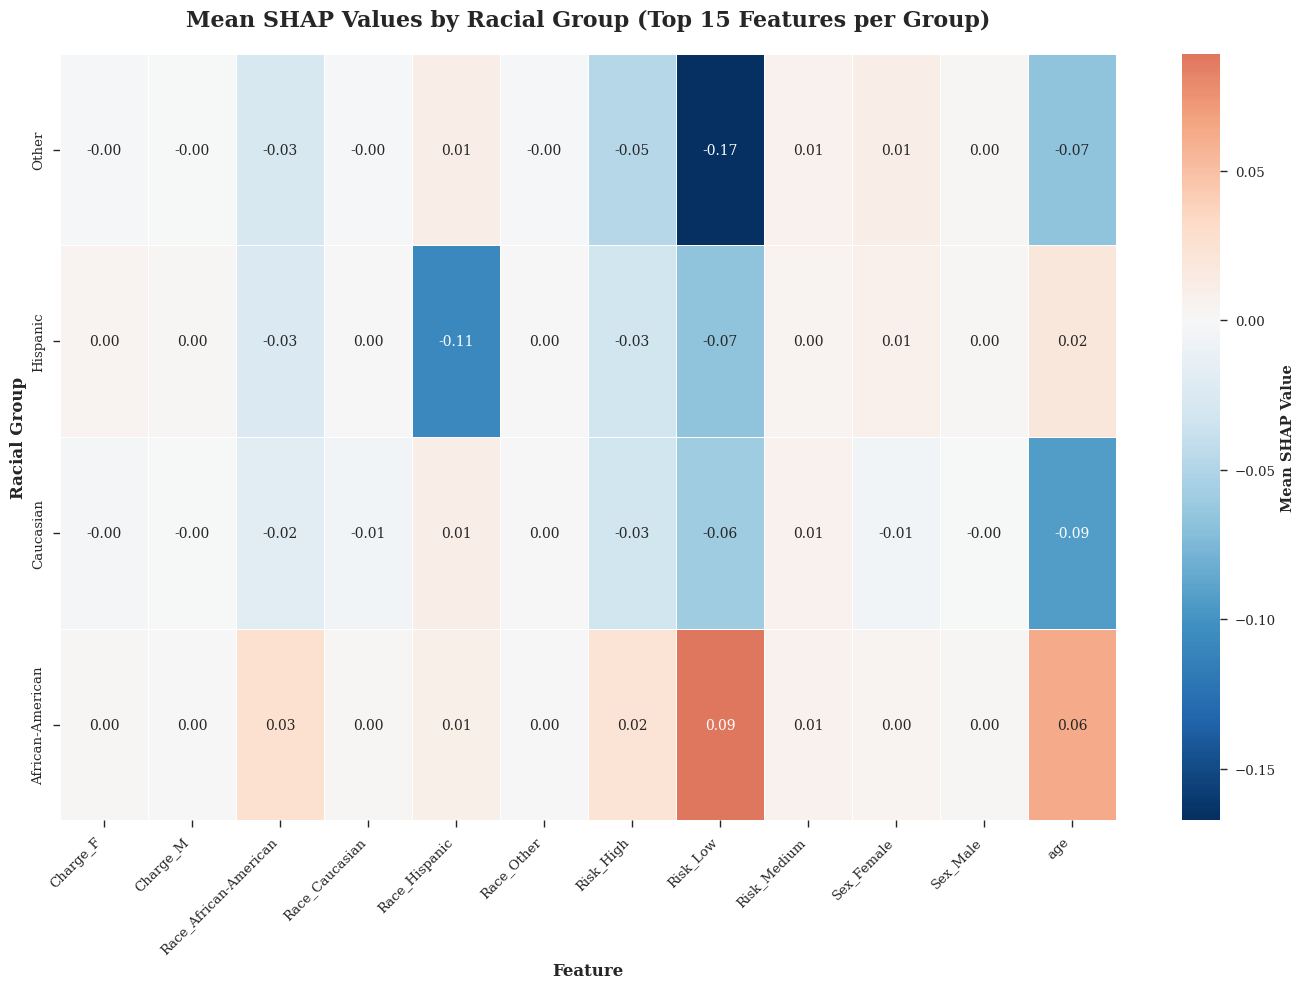

✓ Bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis/shap_barplot_by_group.png


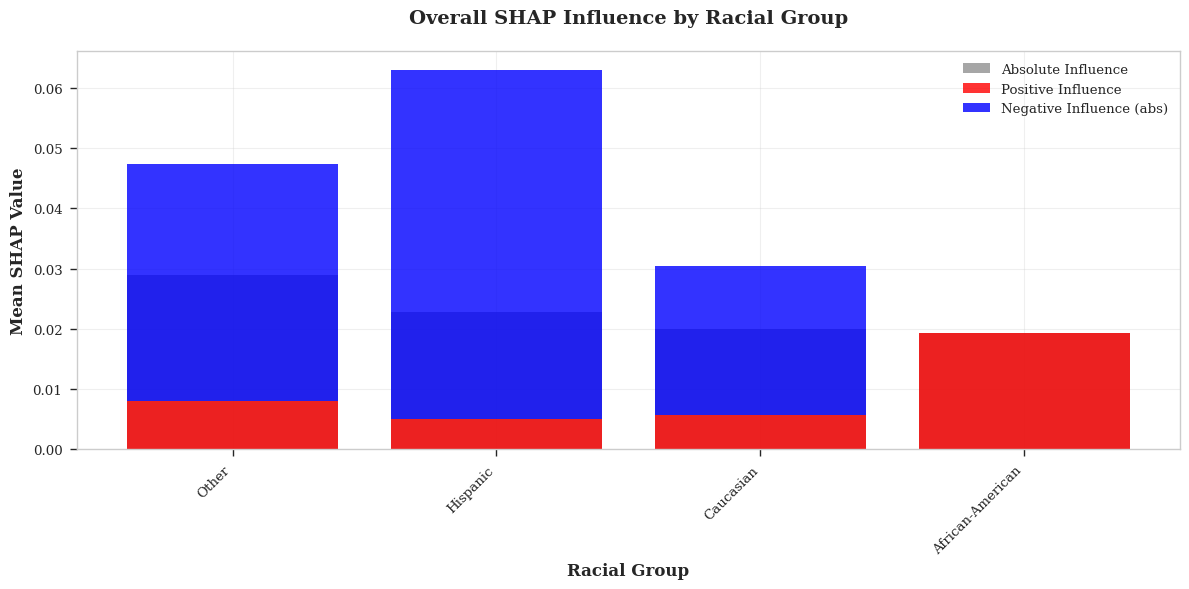


FEATURE IMPORTANCE ANALYSIS BY GROUP

Other - Top 10 features by absolute SHAP value:
------------------------------------------------------------
  Risk_Low: -0.1673 (NEGATIVE)
  age: -0.0672 (NEGATIVE)
  Risk_High: -0.0479 (NEGATIVE)
  Race_African-American: -0.0281 (NEGATIVE)
  Race_Hispanic: 0.0115 (POSITIVE)
  Sex_Female: 0.0107 (POSITIVE)
  Risk_Medium: 0.0072 (POSITIVE)
  Sex_Male: 0.0026 (POSITIVE)
  Charge_F: -0.0019 (NEGATIVE)
  Race_Other: -0.0016 (NEGATIVE)

African-American - Top 10 features by absolute SHAP value:
------------------------------------------------------------
  Risk_Low: 0.0891 (POSITIVE)
  age: 0.0633 (POSITIVE)
  Race_African-American: 0.0268 (POSITIVE)
  Risk_High: 0.0229 (POSITIVE)
  Race_Hispanic: 0.0096 (POSITIVE)
  Risk_Medium: 0.0077 (POSITIVE)
  Sex_Female: 0.0041 (POSITIVE)
  Race_Caucasian: 0.0024 (POSITIVE)
  Charge_F: 0.0023 (POSITIVE)
  Sex_Male: 0.0013 (POSITIVE)

Caucasian - Top 10 features by absolute SHAP value:
--------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# =============================================================================
# 1. LOAD SHAP DATA
# =============================================================================

file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx"

print("="*80)
print("SHAP XAI ANALYSIS BY RACIAL GROUP")
print("="*80)

print(f"Loading data from: {file_path}")

if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    exit()

# Load the SHAP data
try:
    # First, check available sheets
    xl = pd.ExcelFile(file_path)
    print(f"Available sheets: {xl.sheet_names}")
    
    # Try to load SHAP sheet
    sheet_name = None
    possible_shap_sheets = ['SHAP_Main_Effects', 'SHAP', 'shap', 'Main_Effects', 'SHAP_values']
    
    for sheet in possible_shap_sheets:
        if sheet in xl.sheet_names:
            sheet_name = sheet
            break
    
    if sheet_name:
        df_shap = pd.read_excel(file_path, sheet_name=sheet_name)
        print(f"Loaded SHAP data from sheet: {sheet_name}")
    else:
        print("ERROR: No SHAP sheet found. Available sheets:")
        for sheet in xl.sheet_names:
            print(f"  - {sheet}")
        exit()
    
except Exception as e:
    print(f"ERROR loading file: {e}")
    exit()

print(f"\nSHAP data shape: {df_shap.shape}")
print(f"Columns: {df_shap.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_shap.head())

# =============================================================================
# 2. IDENTIFY RACIAL GROUPS AND PREPARE DATA
# =============================================================================

# Look for race-related columns
race_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
             ['race', 'ethnic', 'demographic', 'group', 'african', 'caucasian', 'hispanic'])]

print(f"\nRace-related columns found: {race_cols}")

# Check if we have SHAP values
shap_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
             ['shap', 'value', 'influence', 'effect', 'contribution'])]

print(f"SHAP value columns found: {shap_cols}")

if not shap_cols:
    # Assume all numeric columns except ID/metadata are SHAP values
    numeric_cols = df_shap.select_dtypes(include=[np.number]).columns.tolist()
    # Remove potential ID columns
    shap_cols = [col for col in numeric_cols if not any(term in col.lower() for term in 
                ['id', 'index', 'row', 'count', 'total'])]
    print(f"Using numeric columns as SHAP values: {shap_cols}")

# Let's assume we need to pivot the data - SHAP data could be in different formats
# Format 1: Each row is an observation with SHAP values for features
# Format 2: Long format with feature names and SHAP values

print("\n" + "-"*80)
print("EXPLORING DATA FORMAT")
print("-"*80)

# Check if we have feature names in columns or rows
if len(shap_cols) > 5:  # Likely wide format
    print("Data appears to be in wide format (features as columns)")
    # Extract feature names
    feature_names = shap_cols
    
    # Check for race column
    if len(race_cols) == 0:
        # Try to infer race from other columns
        print("No explicit race column found. Checking for categorical grouping...")
        # Look for any categorical column
        cat_cols = df_shap.select_dtypes(include=['object', 'category']).columns.tolist()
        print(f"Categorical columns: {cat_cols}")
        
        if cat_cols:
            # Use first categorical column as potential group
            group_col = cat_cols[0]
            print(f"Using '{group_col}' as grouping variable")
        else:
            print("No grouping variable found. Creating dummy groups...")
            group_col = 'Group'
            df_shap[group_col] = 'All'
    else:
        group_col = race_cols[0]
        
    df_wide = df_shap.copy()
    
else:
    print("Data appears to be in long format or needs transformation")
    # Check for feature name column
    feature_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
                  ['feature', 'variable', 'name', 'attr'])]
    
    if feature_cols and len(shap_cols) == 1:
        print("Data is in long format")
        feature_col = feature_cols[0]
        shap_col = shap_cols[0]
        
        # Pivot to wide format
        df_wide = df_shap.pivot_table(index=df_shap.index, columns=feature_col, values=shap_col)
        df_wide = df_wide.reset_index()
        
        # Get feature names
        feature_names = [col for col in df_wide.columns if col != 'index']
        
        # Add back any grouping columns
        if race_cols:
            for col in race_cols:
                df_wide[col] = df_shap[col]
            group_col = race_cols[0]
        else:
            group_col = 'Group'
            df_wide[group_col] = 'All'
    else:
        print("Cannot determine data format. Using first approach...")
        # Use wide format assumption
        feature_names = shap_cols
        group_col = 'Group'
        df_wide = df_shap.copy()
        if len(race_cols) > 0:
            group_col = race_cols[0]
        else:
            df_wide[group_col] = 'All'

print(f"\nGrouping by: {group_col}")
print(f"Number of features: {len(feature_names)}")
print(f"Feature examples: {feature_names[:10]}")

# =============================================================================
# 3. CALCULATE MEAN SHAP VALUES BY RACIAL GROUP
# =============================================================================

print("\n" + "="*80)
print("CALCULATING MEAN SHAP VALUES BY RACIAL GROUP")
print("="*80)

# Get unique groups
unique_groups = df_wide[group_col].unique()
print(f"Unique groups: {unique_groups}")

# Calculate mean SHAP values for each group
group_shap_means = {}
group_shap_stds = {}

for group in unique_groups:
    group_data = df_wide[df_wide[group_col] == group]
    
    if len(group_data) > 0:
        # Calculate mean and std for each feature
        group_means = {}
        group_stds = {}
        
        for feature in feature_names:
            if feature in group_data.columns:
                values = group_data[feature].dropna()
                if len(values) > 0:
                    group_means[feature] = np.mean(values)
                    group_stds[feature] = np.std(values)
        
        group_shap_means[group] = group_means
        group_shap_stds[group] = group_stds
        
        print(f"\nGroup: {group} (n={len(group_data)})")
        print(f"  Features with data: {len(group_means)}")

# =============================================================================
# 4. ORDER GROUPS BY MEAN INFLUENCE (POSITIVE AND NEGATIVE)
# =============================================================================

print("\n" + "="*80)
print("ORDERING GROUPS BY MEAN INFLUENCE")
print("="*80)

# Calculate overall mean influence for each group
group_overall_means = {}

for group in group_shap_means:
    means = list(group_shap_means[group].values())
    if means:
        # Use absolute mean to measure overall influence magnitude
        abs_means = [abs(m) for m in means]
        group_overall_means[group] = {
            'mean_abs_influence': np.mean(abs_means),
            'mean_positive': np.mean([m for m in means if m > 0]) if any(m > 0 for m in means) else 0,
            'mean_negative': np.mean([m for m in means if m < 0]) if any(m < 0 for m in means) else 0,
            'n_positive': sum(1 for m in means if m > 0),
            'n_negative': sum(1 for m in means if m < 0)
        }

# Sort groups by mean absolute influence (highest first)
sorted_by_abs = sorted(group_overall_means.items(), 
                      key=lambda x: x[1]['mean_abs_influence'], 
                      reverse=True)

print("\nGroups ordered by mean absolute SHAP influence:")
print("-"*60)
for group, stats in sorted_by_abs:
    print(f"{group}:")
    print(f"  Mean absolute influence: {stats['mean_abs_influence']:.4f}")
    print(f"  Mean positive influence: {stats['mean_positive']:.4f} ({stats['n_positive']} features)")
    print(f"  Mean negative influence: {stats['mean_negative']:.4f} ({stats['n_negative']} features)")

# Sort groups by mean positive influence
positive_means = [(group, stats['mean_positive']) for group, stats in group_overall_means.items()]
sorted_by_positive = sorted(positive_means, key=lambda x: x[1], reverse=True)

print("\nGroups ordered by mean positive SHAP influence:")
print("-"*60)
for group, mean_pos in sorted_by_positive:
    if mean_pos > 0:
        print(f"{group}: {mean_pos:.4f}")

# Sort groups by mean negative influence (most negative first)
negative_means = [(group, stats['mean_negative']) for group, stats in group_overall_means.items()]
sorted_by_negative = sorted(negative_means, key=lambda x: x[1])

print("\nGroups ordered by mean negative SHAP influence:")
print("-"*60)
for group, mean_neg in sorted_by_negative:
    if mean_neg < 0:
        print(f"{group}: {mean_neg:.4f}")

# =============================================================================
# 5. VISUALIZATION: HEATMAP OF SHAP VALUES BY GROUP
# =============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Prepare data for heatmap
heatmap_data = []
for group in sorted_by_abs:
    group_name = group[0]
    means = group_shap_means[group_name]
    
    # Get top N features by absolute mean
    feature_abs_means = [(feat, abs(mean)) for feat, mean in means.items()]
    feature_abs_means.sort(key=lambda x: x[1], reverse=True)
    top_features = [feat for feat, _ in feature_abs_means[:15]]  # Top 15 features
    
    for feature in top_features:
        if feature in means:
            heatmap_data.append({
                'Group': group_name,
                'Feature': feature,
                'SHAP_Value': means[feature],
                'Abs_SHAP': abs(means[feature])
            })

heatmap_df = pd.DataFrame(heatmap_data)

if len(heatmap_df) > 0:
    # Create pivot table for heatmap
    pivot_table = heatmap_df.pivot_table(index='Group', columns='Feature', values='SHAP_Value')
    
    # Reorder groups based on sorting
    pivot_table = pivot_table.reindex([group[0] for group in sorted_by_abs])
    
    # Create figure
    plt.figure(figsize=(14, 10))
    
    # Create heatmap
    sns.heatmap(pivot_table, 
                cmap='RdBu_r', 
                center=0,
                annot=True, 
                fmt='.2f',
                linewidths=0.5,
                cbar_kws={'label': 'Mean SHAP Value'})
    
    plt.title('Mean SHAP Values by Racial Group (Top 15 Features per Group)', fontsize=16, pad=20)
    plt.xlabel('Feature', fontsize=12)
    plt.ylabel('Racial Group', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save heatmap
    output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis"
    os.makedirs(output_dir, exist_ok=True)
    heatmap_path = os.path.join(output_dir, "shap_heatmap_by_group.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"✓ Heatmap saved to: {heatmap_path}")
    
    plt.show()
else:
    print("Not enough data for heatmap visualization")

# =============================================================================
# 6. BAR PLOT: OVERALL INFLUENCE BY GROUP
# =============================================================================

# Create bar plot
plt.figure(figsize=(12, 6))

# Prepare data
groups = [g[0] for g in sorted_by_abs]
abs_influences = [g[1]['mean_abs_influence'] for g in sorted_by_abs]
positive_influences = [group_overall_means[g]['mean_positive'] for g in groups]
negative_influences = [abs(group_overall_means[g]['mean_negative']) for g in groups]  # Absolute for display

x_pos = np.arange(len(groups))

# Create bars
plt.bar(x_pos, abs_influences, alpha=0.7, label='Absolute Influence', color='gray')
plt.bar(x_pos, positive_influences, alpha=0.8, label='Positive Influence', color='red')
plt.bar(x_pos, negative_influences, alpha=0.8, label='Negative Influence (abs)', color='blue', bottom=positive_influences)

plt.xlabel('Racial Group', fontsize=12)
plt.ylabel('Mean SHAP Value', fontsize=12)
plt.title('Overall SHAP Influence by Racial Group', fontsize=14, pad=20)
plt.xticks(x_pos, groups, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save bar plot
barplot_path = os.path.join(output_dir, "shap_barplot_by_group.png")
plt.savefig(barplot_path, dpi=300, bbox_inches='tight')
print(f"✓ Bar plot saved to: {barplot_path}")
plt.show()

# =============================================================================
# 7. FEATURE IMPORTANCE ANALYSIS BY GROUP
# =============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS BY GROUP")
print("="*80)

# Identify most important features for each group
top_features_by_group = {}

for group in group_shap_means:
    means = group_shap_means[group]
    
    # Sort features by absolute SHAP value
    sorted_features = sorted(means.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Get top 10 features
    top_features = sorted_features[:10]
    top_features_by_group[group] = top_features
    
    print(f"\n{group} - Top 10 features by absolute SHAP value:")
    print("-"*60)
    for feature, value in top_features:
        direction = "POSITIVE" if value > 0 else "NEGATIVE"
        print(f"  {feature}: {value:.4f} ({direction})")

# =============================================================================
# 8. COMPARE FEATURE IMPORTANCE ACROSS GROUPS
# =============================================================================

print("\n" + "="*80)
print("CROSS-GROUP FEATURE IMPORTANCE COMPARISON")
print("="*80)

# Collect all unique top features
all_top_features = set()
for features in top_features_by_group.values():
    all_top_features.update([f[0] for f in features])

# Create comparison table
comparison_data = []
for feature in all_top_features:
    row = {'Feature': feature}
    for group in group_shap_means:
        if feature in group_shap_means[group]:
            row[group] = group_shap_means[group][feature]
        else:
            row[group] = np.nan
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

# Sort by variance across groups (most variable first)
comparison_df['Variance'] = comparison_df[[g for g in group_shap_means]].var(axis=1)
comparison_df = comparison_df.sort_values('Variance', ascending=False)

print("\nTop 15 features with highest variance across groups:")
print(comparison_df[['Feature', 'Variance'] + list(group_shap_means.keys())].head(15).to_string())

# =============================================================================
# 9. SAVE ANALYSIS RESULTS
# =============================================================================

output_excel = os.path.join(output_dir, "SHAP_Analysis_Results.xlsx")

print(f"\nSaving analysis results to: {output_excel}")

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Save group statistics
    stats_data = []
    for group in group_shap_means:
        stats = group_overall_means[group]
        stats_data.append({
            'Group': group,
            'Mean_Absolute_Influence': stats['mean_abs_influence'],
            'Mean_Positive_Influence': stats['mean_positive'],
            'Mean_Negative_Influence': stats['mean_negative'],
            'N_Positive_Features': stats['n_positive'],
            'N_Negative_Features': stats['n_negative']
        })
    
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_excel(writer, sheet_name='Group_Statistics', index=False)
    
    # Save top features by group
    for group in top_features_by_group:
        features_df = pd.DataFrame(top_features_by_group[group], 
                                  columns=['Feature', 'SHAP_Value'])
        features_df['Absolute_Value'] = features_df['SHAP_Value'].abs()
        features_df['Direction'] = features_df['SHAP_Value'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
        features_df = features_df.sort_values('Absolute_Value', ascending=False)
        
        # Shorten sheet name if needed
        sheet_name = f"Top_Features_{group}"[:31]
        features_df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Save feature comparison
    comparison_df.to_excel(writer, sheet_name='Feature_Comparison', index=False)

print("✓ Analysis complete! Results saved to SHAP_Analysis directory.")
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Print final summary
print(f"\nNumber of groups analyzed: {len(unique_groups)}")
print(f"Number of features analyzed: {len(feature_names)}")

top_group = sorted_by_abs[0][0] if sorted_by_abs else "N/A"
print(f"Group with highest mean absolute influence: {top_group}")

if sorted_by_positive:
    top_positive = sorted_by_positive[0][0] if sorted_by_positive[0][1] > 0 else "None"
    print(f"Group with highest positive influence: {top_positive}")

if sorted_by_negative:
    most_negative = sorted_by_negative[0][0] if sorted_by_negative[0][1] < 0 else "None"
    print(f"Group with most negative influence: {most_negative}")

print(f"\nVisualizations saved to:")
print(f"  - {heatmap_path}")
print(f"  - {barplot_path}")
print(f"  - {output_excel}")

SHAP XAI ANALYSIS BY RACIAL GROUP
Loading data from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx
Loaded SHAP data from sheet: SHAP_Main_Effects

SHAP data shape: (1235, 18)
Columns: ['Test_ID', 'Race_Test', 'age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'Sex_Female', 'Sex_Male', 'Race_African-American', 'Race_Caucasian', 'Race_Hispanic', 'Race_Other', 'Risk_High', 'Risk_Low', 'Risk_Medium', 'Charge_F', 'Charge_M']
Race-related columns found: ['Race_Test', 'juv_other_count', 'Race_African-American', 'Race_Caucasian', 'Race_Hispanic', 'Race_Other']
Using numeric columns as SHAP values: ['Sex_Female', 'Sex_Male', 'Race_African-American', 'Race_Caucasian', 'Race_Hispanic', 'Race_Other', 'Risk_High', 'Risk_Low', 'Risk_Medium', 'Charge_F']...
Using 'Race_Test' as grouping column
Unique groups found: ['Other' 'African-American' 'Caucasian' 'Hispanic']
Number of observations per group:
  Other: 76 observations
  A

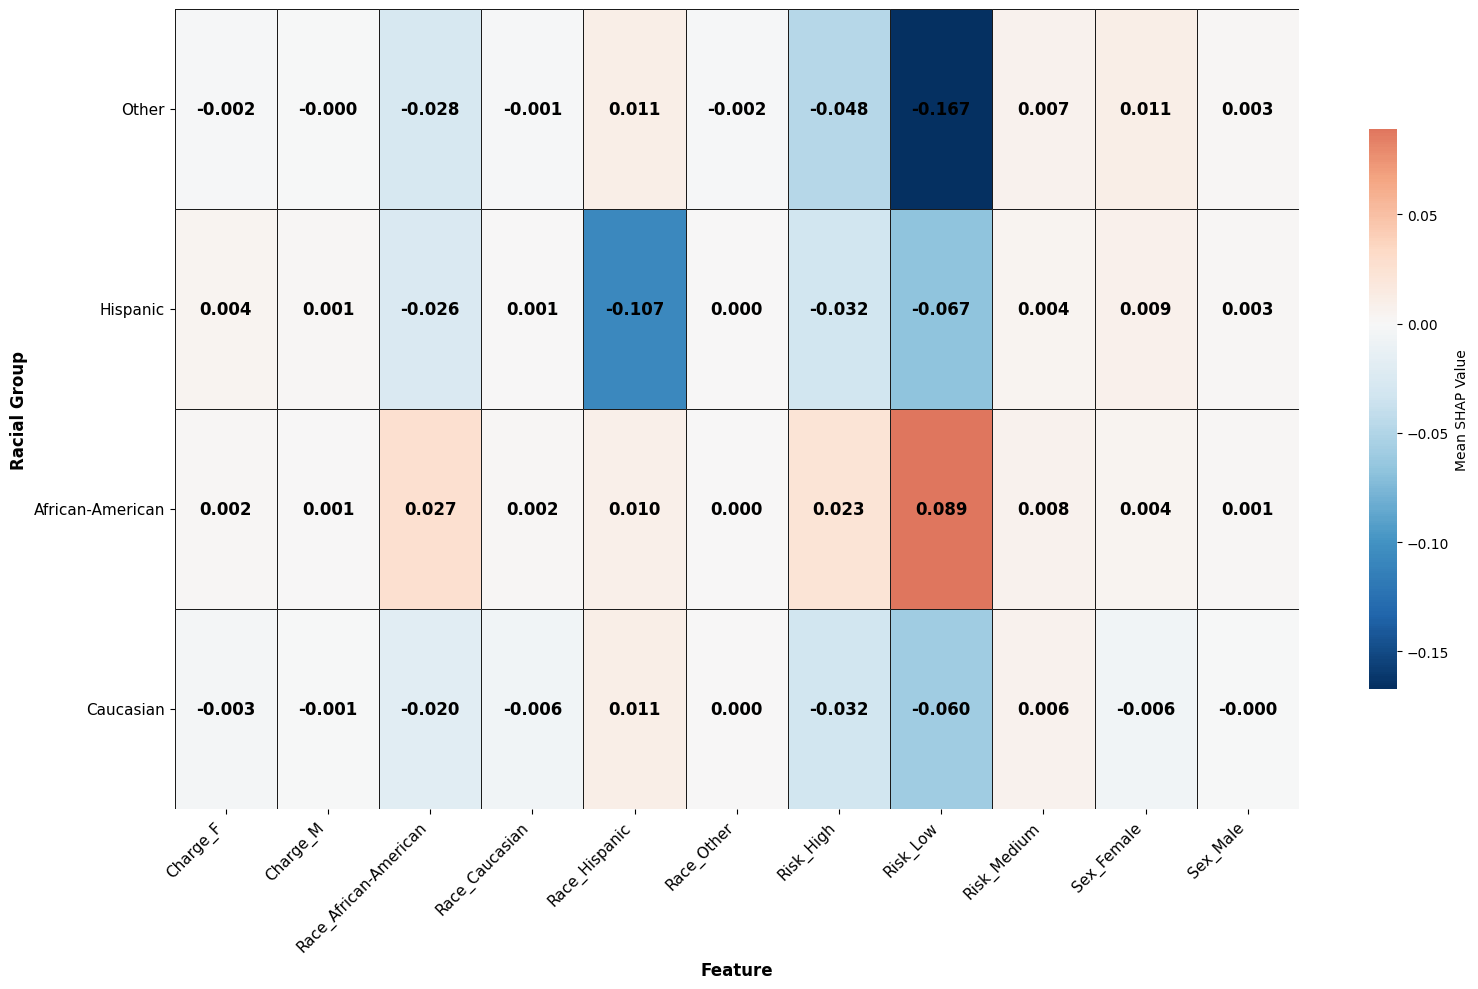


CREATING SEPARATE BAR PLOTS
Absolute influence bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_absolute.png


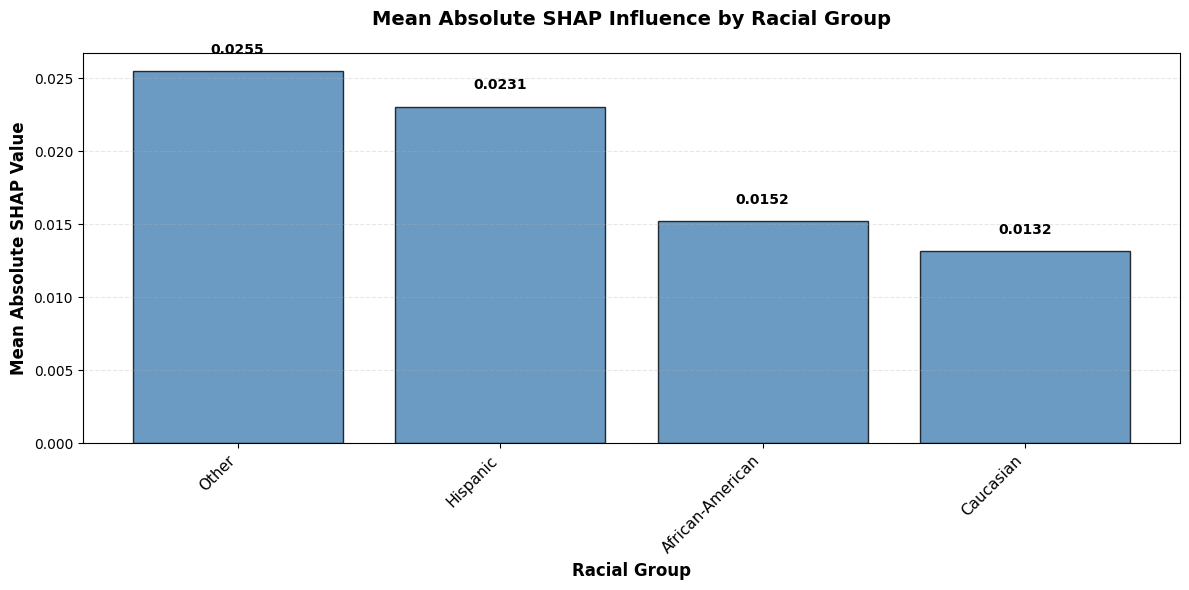

Positive influence bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_positive.png


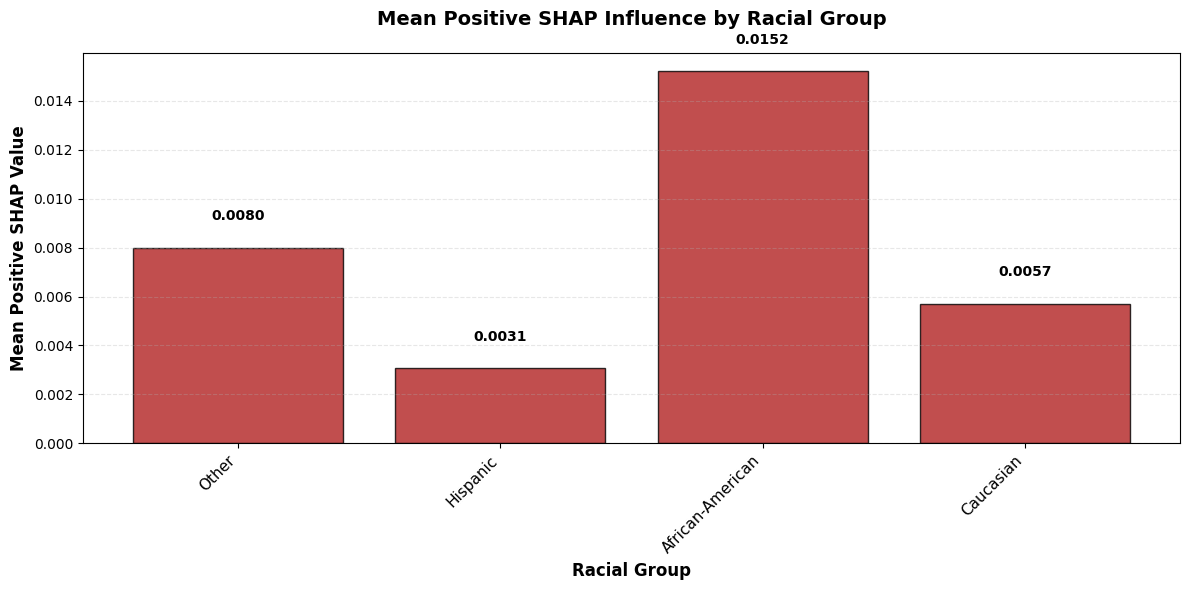

Negative influence bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_negative.png


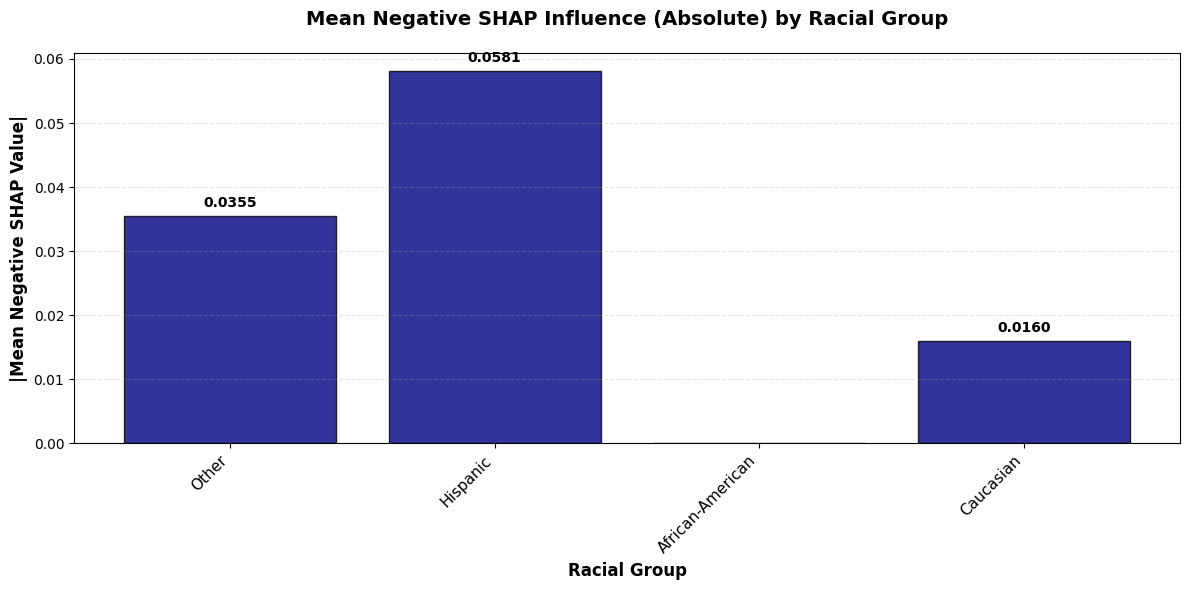

Comparison bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_comparison.png


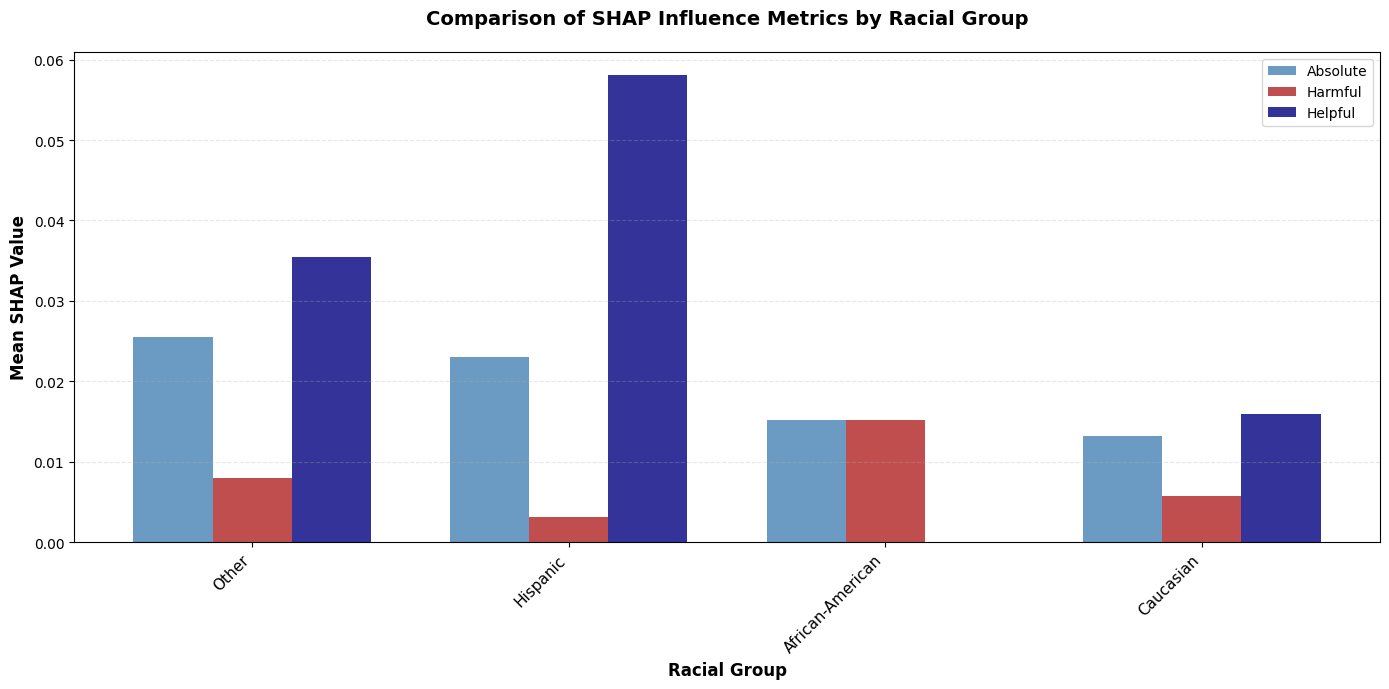


FEATURE CONTRIBUTION PATTERNS
Top features with consistent direction across groups:
  Risk_Medium: Positive
Total consistent features: 1
Saving comprehensive results to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/SHAP_Comprehensive_Analysis.xlsx
Comprehensive analysis saved!

ANALYSIS COMPLETE - FILES GENERATED

Visualizations:
  1. Clear heatmap: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_heatmap_clear.png
  2. Absolute influence bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_absolute.png
  3. Positive influence bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_positive.png
  4. Negative influence bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE/shap_bar_negative.png
  5. Comparison bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
import matplotlib

# =============================================================================
# 1. LOAD SHAP DATA
# =============================================================================

file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx"

print("="*80)
print("SHAP XAI ANALYSIS BY RACIAL GROUP")
print("="*80)

print(f"Loading data from: {file_path}")

if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    exit()

# Load the SHAP data
try:
    xl = pd.ExcelFile(file_path)
    
    # Try to load SHAP sheet
    sheet_name = None
    possible_shap_sheets = ['SHAP_Main_Effects', 'SHAP', 'shap', 'Main_Effects', 'SHAP_values']
    
    for sheet in possible_shap_sheets:
        if sheet in xl.sheet_names:
            sheet_name = sheet
            break
    
    if sheet_name:
        df_shap = pd.read_excel(file_path, sheet_name=sheet_name)
        print(f"Loaded SHAP data from sheet: {sheet_name}")
    else:
        print("ERROR: No SHAP sheet found. Available sheets:")
        for sheet in xl.sheet_names:
            print(f"  - {sheet}")
        exit()
    
except Exception as e:
    print(f"ERROR loading file: {e}")
    exit()

print(f"\nSHAP data shape: {df_shap.shape}")
print(f"Columns: {df_shap.columns.tolist()}")

# =============================================================================
# 2. IDENTIFY RACIAL GROUPS AND PREPARE DATA
# =============================================================================

# Look for race-related columns
race_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
             ['race', 'ethnic', 'demographic', 'group', 'african', 'caucasian', 'hispanic', 'other'])]

print(f"Race-related columns found: {race_cols}")

# Check if we have SHAP values
shap_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
             ['shap', 'value', 'influence', 'effect', 'contribution'])]

if not shap_cols:
    # Assume all numeric columns except ID/metadata are SHAP values
    numeric_cols = df_shap.select_dtypes(include=[np.number]).columns.tolist()
    shap_cols = [col for col in numeric_cols if not any(term in col.lower() for term in 
                ['id', 'index', 'row', 'count', 'total', 'age', 'priors'])]
    print(f"Using numeric columns as SHAP values: {shap_cols[:10]}...")

# Find grouping column
if len(race_cols) > 0:
    group_col = race_cols[0]
    print(f"Using '{group_col}' as grouping column")
else:
    # Look for any categorical column
    cat_cols = df_shap.select_dtypes(include=['object', 'category']).columns.tolist()
    if cat_cols:
        group_col = cat_cols[0]
        print(f"No race column found. Using '{group_col}' as grouping column")
    else:
        group_col = 'Group'
        df_shap[group_col] = 'All'
        print("No grouping column found. Creating 'Group' column")

# Get unique groups
unique_groups = df_shap[group_col].unique()
print(f"Unique groups found: {unique_groups}")
print(f"Number of observations per group:")
for group in unique_groups:
    count = len(df_shap[df_shap[group_col] == group])
    print(f"  {group}: {count} observations")

# =============================================================================
# 3. CALCULATE MEAN SHAP VALUES BY GROUP
# =============================================================================

print("\n" + "="*80)
print("CALCULATING MEAN SHAP VALUES BY GROUP")
print("="*80)

# Calculate mean SHAP values for each group
group_shap_means = {}
group_shap_stds = {}

for group in unique_groups:
    group_data = df_shap[df_shap[group_col] == group]
    
    if len(group_data) > 0:
        group_means = {}
        group_stds = {}
        
        for feature in shap_cols:
            if feature in group_data.columns:
                values = group_data[feature].dropna()
                if len(values) > 0:
                    group_means[feature] = np.mean(values)
                    group_stds[feature] = np.std(values)
        
        group_shap_means[group] = group_means
        group_shap_stds[group] = group_stds
        
        print(f"\n{group} (n={len(group_data)}):")
        print(f"  Features with data: {len(group_means)}")
        print(f"  Mean SHAP range: [{min(group_means.values()):.4f}, {max(group_means.values()):.4f}]")

# =============================================================================
# 4. ORDER GROUPS BY INFLUENCE METRICS
# =============================================================================

print("\n" + "="*80)
print("ORDERING GROUPS BY INFLUENCE METRICS")
print("="*80)

# Calculate overall influence metrics for each group
group_metrics = {}

for group in group_shap_means:
    means = list(group_shap_means[group].values())
    
    if means:
        # Calculate various metrics
        abs_means = [abs(m) for m in means]
        positive_vals = [m for m in means if m > 0]
        negative_vals = [m for m in means if m < 0]
        
        group_metrics[group] = {
            'mean_abs': np.mean(abs_means),
            'mean_pos': np.mean(positive_vals) if positive_vals else 0,
            'mean_neg': np.mean(negative_vals) if negative_vals else 0,
            'max_pos': max(positive_vals) if positive_vals else 0,
            'min_neg': min(negative_vals) if negative_vals else 0,
            'n_pos': len(positive_vals),
            'n_neg': len(negative_vals),
            'total_features': len(means)
        }

# Sort groups by different metrics
sorted_by_abs = sorted(group_metrics.items(), 
                      key=lambda x: x[1]['mean_abs'], 
                      reverse=True)

sorted_by_pos = sorted(group_metrics.items(),
                      key=lambda x: x[1]['mean_pos'],
                      reverse=True)

sorted_by_neg = sorted(group_metrics.items(),
                      key=lambda x: x[1]['mean_neg'])

print("\nGroups sorted by mean absolute influence:")
for group, metrics in sorted_by_abs:
    print(f"  {group}: {metrics['mean_abs']:.4f}")

print("\nGroups sorted by mean positive influence:")
for group, metrics in sorted_by_pos:
    if metrics['mean_pos'] > 0:
        print(f"  {group}: {metrics['mean_pos']:.4f}")

print("\nGroups sorted by mean negative influence:")
for group, metrics in sorted_by_neg:
    if metrics['mean_neg'] < 0:
        print(f"  {group}: {metrics['mean_neg']:.4f}")

# =============================================================================
# 5. IMPROVED HEATMAP WITH CLEARER ANNOTATIONS
# =============================================================================

print("\n" + "="*80)
print("CREATING HEATMAP WITH CLEAR ANNOTATIONS")
print("="*80)

# Prepare data for heatmap
# Get top 10 features overall by variance across groups
feature_variance = {}
for feature in shap_cols:
    values = []
    for group in group_shap_means:
        if feature in group_shap_means[group]:
            values.append(group_shap_means[group][feature])
    if len(values) > 1:
        feature_variance[feature] = np.var(values)

# Get top 15 features by variance
top_features = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)[:15]
top_feature_names = [f[0] for f in top_features]

# Create heatmap data
heatmap_data = []
for group in [g[0] for g in sorted_by_abs]:  # Use absolute order
    for feature in top_feature_names:
        if feature in group_shap_means[group]:
            value = group_shap_means[group][feature]
            heatmap_data.append({
                'Group': group,
                'Feature': feature,
                'SHAP_Value': value
            })

heatmap_df = pd.DataFrame(heatmap_data)
pivot_table = heatmap_df.pivot_table(index='Group', columns='Feature', values='SHAP_Value')

# Reorder groups
pivot_table = pivot_table.reindex([g[0] for g in sorted_by_abs])

# Create figure with improved styling
plt.figure(figsize=(16, 10))

# Create custom colormap
cmap = plt.cm.RdBu_r

# Create heatmap with clearer annotations
ax = sns.heatmap(pivot_table,
                 cmap=cmap,
                 center=0,
                 annot=True,
                 fmt='.3f',  # 3 decimal places
                 annot_kws={
                     'size': 12,
                     'weight': 'bold',  # Bold annotations
                     'color': 'black'   # Black text for contrast
                 },
                 linewidths=0.5,
                 linecolor='black', #gray
                 cbar_kws={
                     'label': 'Mean SHAP Value',
                     'shrink': 0.7
                 },
                 square=False)

# Improve readability
plt.title('', #SHAP Explanations by Racial Group (Top 15 Features)
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Feature', fontsize=12, fontweight='bold')
plt.ylabel('Racial Group', fontsize=12, fontweight='bold')

# Rotate feature names for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Add grid lines for better separation
ax.hlines(range(len(pivot_table.index)), *ax.get_xlim(), colors='gray', linewidth=0.5, alpha=0.3)
ax.vlines(range(len(pivot_table.columns)), *ax.get_ylim(), colors='gray', linewidth=0.5, alpha=0.3)

plt.tight_layout()

# Save heatmap
output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_AnalysisCOMPLETE"
os.makedirs(output_dir, exist_ok=True)
heatmap_path = os.path.join(output_dir, "shap_heatmap_clear.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"Clear heatmap saved to: {heatmap_path}")
plt.show()

# =============================================================================
# 6. SEPARATE BAR PLOTS FOR DIFFERENT METRICS
# =============================================================================

print("\n" + "="*80)
print("CREATING SEPARATE BAR PLOTS")
print("="*80)

# Prepare data for bar plots
groups = [g[0] for g in sorted_by_abs]
abs_values = [group_metrics[g]['mean_abs'] for g in groups]
pos_values = [group_metrics[g]['mean_pos'] for g in groups]
neg_values = [group_metrics[g]['mean_neg'] for g in groups]
n_pos = [group_metrics[g]['n_pos'] for g in groups]
n_neg = [group_metrics[g]['n_neg'] for g in groups]

x_pos = np.arange(len(groups))

# 1. BAR PLOT: ABSOLUTE INFLUENCE
plt.figure(figsize=(12, 6))
bars = plt.bar(x_pos, abs_values, color='steelblue', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, abs_values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('Mean Absolute SHAP Value', fontsize=12, fontweight='bold')
plt.title('Mean Absolute SHAP Influence by Racial Group', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x_pos, groups, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

abs_bar_path = os.path.join(output_dir, "shap_bar_absolute.png")
plt.savefig(abs_bar_path, dpi=300, bbox_inches='tight')
print(f"Absolute influence bar plot saved to: {abs_bar_path}")
plt.show()

# 2. BAR PLOT: POSITIVE INFLUENCE
plt.figure(figsize=(12, 6))
bars_pos = plt.bar(x_pos, pos_values, color='firebrick', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels
for i, (bar, value) in enumerate(zip(bars_pos, pos_values)):
    if value > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('Mean Positive SHAP Value', fontsize=12, fontweight='bold')
plt.title('Mean Positive SHAP Influence by Racial Group', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x_pos, groups, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

pos_bar_path = os.path.join(output_dir, "shap_bar_positive.png")
plt.savefig(pos_bar_path, dpi=300, bbox_inches='tight')
print(f"Positive influence bar plot saved to: {pos_bar_path}")
plt.show()

# 3. BAR PLOT: NEGATIVE INFLUENCE
plt.figure(figsize=(12, 6))
bars_neg = plt.bar(x_pos, [abs(v) for v in neg_values], color='navy', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels (using absolute values for display)
for i, (bar, value) in enumerate(zip(bars_neg, neg_values)):
    if value < 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{abs(value):.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('|Mean Negative SHAP Value|', fontsize=12, fontweight='bold')
plt.title('Mean Negative SHAP Influence (Absolute) by Racial Group', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x_pos, groups, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

neg_bar_path = os.path.join(output_dir, "shap_bar_negative.png")
plt.savefig(neg_bar_path, dpi=300, bbox_inches='tight')
print(f"Negative influence bar plot saved to: {neg_bar_path}")
plt.show()

# 4. SIDE-BY-SIDE COMPARISON BAR PLOT
plt.figure(figsize=(14, 7))
bar_width = 0.25

# Create positions for each group
r1 = np.arange(len(groups))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width * 2 for x in r1]

# Create bars
plt.bar(r1, abs_values, width=bar_width, label='Absolute', color='steelblue', alpha=0.8)
plt.bar(r2, pos_values, width=bar_width, label='Harmful', color='firebrick', alpha=0.8)
plt.bar(r3, [abs(v) for v in neg_values], width=bar_width, label='Helpful', color='navy', alpha=0.8)

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('Mean SHAP Value', fontsize=12, fontweight='bold')
plt.title('Comparison of SHAP Influence Metrics by Racial Group', fontsize=14, fontweight='bold', pad=20)
plt.xticks([r + bar_width for r in range(len(groups))], groups, rotation=45, ha='right', fontsize=11)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

comparison_path = os.path.join(output_dir, "shap_bar_comparison.png")
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f"Comparison bar plot saved to: {comparison_path}")
plt.show()

# =============================================================================
# 7. ADDITIONAL ANALYSIS: FEATURE CONTRIBUTION PATTERNS
# =============================================================================

print("\n" + "="*80)
print("FEATURE CONTRIBUTION PATTERNS")
print("="*80)

# Identify features with consistent vs variable patterns
print("Top features with consistent direction across groups:")
consistent_features = []
for feature in shap_cols[:20]:  # Check first 20 features
    directions = []
    for group in groups:
        if feature in group_shap_means[group]:
            value = group_shap_means[group][feature]
            directions.append(1 if value > 0 else -1 if value < 0 else 0)
    
    # Check if all non-zero directions are the same
    non_zero = [d for d in directions if d != 0]
    if len(non_zero) > 0 and all(d == non_zero[0] for d in non_zero):
        consistent_features.append((feature, non_zero[0]))

for feature, direction in consistent_features[:10]:
    print(f"  {feature}: {'Positive' if direction > 0 else 'Negative'}")

print(f"Total consistent features: {len(consistent_features)}")

# =============================================================================
# 8. SAVE COMPREHENSIVE RESULTS
# =============================================================================

output_excel = os.path.join(output_dir, "SHAP_Comprehensive_Analysis.xlsx")

print(f"Saving comprehensive results to: {output_excel}")

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Save group metrics
    metrics_data = []
    for group in groups:
        metrics = group_metrics[group]
        metrics_data.append({
            'Group': group,
            'Mean_Absolute_Influence': metrics['mean_abs'],
            'Mean_Positive_Influence': metrics['mean_pos'],
            'Mean_Negative_Influence': metrics['mean_neg'],
            'Max_Positive': metrics['max_pos'],
            'Min_Negative': metrics['min_neg'],
            'N_Positive_Features': metrics['n_pos'],
            'N_Negative_Features': metrics['n_neg'],
            'Total_Features': metrics['total_features']
        })
    
    metrics_df = pd.DataFrame(metrics_data)
    metrics_df.to_excel(writer, sheet_name='Group_Metrics', index=False)
    
    # Save detailed SHAP values
    detailed_data = []
    for group in groups:
        for feature in shap_cols:
            if feature in group_shap_means[group]:
                detailed_data.append({
                    'Group': group,
                    'Feature': feature,
                    'Mean_SHAP': group_shap_means[group][feature],
                    'Std_SHAP': group_shap_stds[group][feature],
                    'Direction': 'Positive' if group_shap_means[group][feature] > 0 else 'Negative'
                })
    
    detailed_df = pd.DataFrame(detailed_data)
    detailed_df.to_excel(writer, sheet_name='Detailed_SHAP_Values', index=False)
    
    # Save heatmap data
    heatmap_df.to_excel(writer, sheet_name='Heatmap_Data', index=False)
    
    # Save feature variance
    variance_df = pd.DataFrame(list(feature_variance.items()), columns=['Feature', 'Variance'])
    variance_df = variance_df.sort_values('Variance', ascending=False)
    variance_df.to_excel(writer, sheet_name='Feature_Variance', index=False)

print("Comprehensive analysis saved!")
print("\n" + "="*80)
print("ANALYSIS COMPLETE - FILES GENERATED")
print("="*80)
print(f"\nVisualizations:")
print(f"  1. Clear heatmap: {heatmap_path}")
print(f"  2. Absolute influence bar plot: {abs_bar_path}")
print(f"  3. Positive influence bar plot: {pos_bar_path}")
print(f"  4. Negative influence bar plot: {neg_bar_path}")
print(f"  5. Comparison bar plot: {comparison_path}")
print(f"\nData:")
print(f"  6. Comprehensive Excel results: {output_excel}")

In [ ]:
#.... Barplots metric influence by racial group analysis ....#  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ========================== LOAD & PREPARE ==========================

file_path = "/home/oj/Project_code/MLLS Hackaton/Share/results_compas_Recidivism.xlsx"
df_influence = pd.read_excel(file_path, sheet_name="Influence_Test_vs_Train")
df_preds     = pd.read_excel(file_path, sheet_name="Predictions_By_Race")
df_preds.columns = df_preds.columns.str.strip()
df_preds = df_preds.rename(columns=lambda x: x.replace('Predicated-Label', 'Predicted_Label'))

def find_id(df):
    for c in df.columns:
        if str(c).lower() in ['id', 'person_id', 'caseid', 'index', 'unnamed: 0']:
            return c
    return df.columns[0]

df_influence = df_influence.rename(columns={find_id(df_influence): 'ID'})
df_preds = df_preds.rename(columns={find_id(df_preds): 'ID'})
df = df_influence.merge(df_preds[['ID', 'Race', 'Actual_Label', 'Predicted_Label']], on='ID', how='inner')

df['Case_Type'] = np.select(
    [(df['Actual_Label']==1) & (df['Predicted_Label']==1),
     (df['Actual_Label']==0) & (df['Predicted_Label']==0),
     (df['Actual_Label']==0) & (df['Predicted_Label']==1),
     (df['Actual_Label']==1) & (df['Predicted_Label']==0)],
    ['TP', 'TN', 'FP', 'FN'], default=None
)

races = ['African-American', 'Caucasian', 'Hispanic', 'Other']
short = ['AA', 'C', 'H', 'O']
colors = ['#e6194b', '#4363d8', '#ffe119', '#3cb44b']
case_names = {'TP': 'True Positives', 'TN': 'True Negatives',
              'FP': 'False Positives', 'FN': 'False Negatives'}

# ========================== MODIFIED FUNCTION (fixed -0.15 to +0.15 axis) ==========================

def plot_perfect_compact(case_type):

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"{case_names[case_type]}", fontsize=22, fontweight='bold', y=0.97)
    for idx, (ax, actual_race) in enumerate(zip(axes.flat, races)):

        means, stds = [], []
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]

        for p_idx, p_race in enumerate(races):

            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            mean_val = values.mean() if len(values)>0 else 0
            std_val  = values.std(ddof=1) if len(values)>1 else 0
            means.append(mean_val)
            stds.append(std_val)
        y_pos = np.arange(4)[::-1]

        # Bars - colors represent predicted races

        bars = ax.barh(y_pos, means, color=colors, height=0.75,
                       edgecolor='black', linewidth=1.0) ####1.5

        # Zero line

        ax.axvline(0, color='black', linewidth=1.5) #..2.4
        # Y labels

        ax.set_yticks(y_pos)
        ax.set_yticklabels([f"{short[idx]}→{short[j]}" for j in range(4)],
                           fontsize=12, fontweight='bold')

        # Title - shows the ACTUAL race for this subplot
        ax.set_title(f"{actual_race}", fontsize=14.5, fontweight='bold', pad=14)
        ax.set_xlabel('Influence on L(θ)', fontsize=11, labelpad=10)

        # FIXED X-AXIS LIMITS FOR ALL SUBPLOTS
        ax.set_xlim(-0.15, 0.15)          # Only change
        ax.tick_params(axis='x', labelsize=9)
        ax.grid(True, axis='x', alpha=0.28)
        ax.tick_params(left=False)

        # Frame

        for spine in ax.spines.values():
            spine.set_linewidth(0.5) ##########################################
            spine.set_color('black')

        # Legend (unchanged)
        legend_labels = [f"{short[j]}: {means[j]:+.3f}±{stds[j]:.3f}" for j in range(4)]
        legend_patches = [plt.Rectangle((0,0),1,1, facecolor=colors[j],
                                       edgecolor='black', linewidth=1) for j in range(4)]

        ax.legend(legend_patches, legend_labels,
                  loc='upper right', 
                  bbox_to_anchor=(0.98, 0.98),
                  frameon=True, fancybox=False, edgecolor='black',
                  fontsize=8.1,
                  labelspacing=0.4,
                  borderpad=0.4,
                  handlelength=1.2,
                  handletextpad=0.5,
                  title=f"{races[idx]}")

    plt.subplots_adjust(top=0.91, hspace=0.38, wspace=0.38)
    filename = f"EqualAXIS_BAR_2YR_{case_type}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"SAVED: {filename}")
    plt.show()

# ========================== GENERATE ALL 4 ==========================
print("Generating your 4 plots with fixed ±0.15 axis...\n")
for case in ['TP', 'TN', 'FP', 'FN']:
    plot_perfect_compact(case)
print("Done!")

In [ ]:
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx"
df_influence = pd.read_excel(file_path, sheet_name="Influence_Test_vs_Train")
df_preds     = pd.read_excel(file_path, sheet_name="Predictions_By_Race")
df_preds.columns = df_preds.columns.str.strip()
df_preds = df_preds.rename(columns=lambda x: x.replace('Predicated-Label', 'Predicted_Label'))

Generating plots with external legends...

SAVED: Boxplot_With_Legend_TP.png


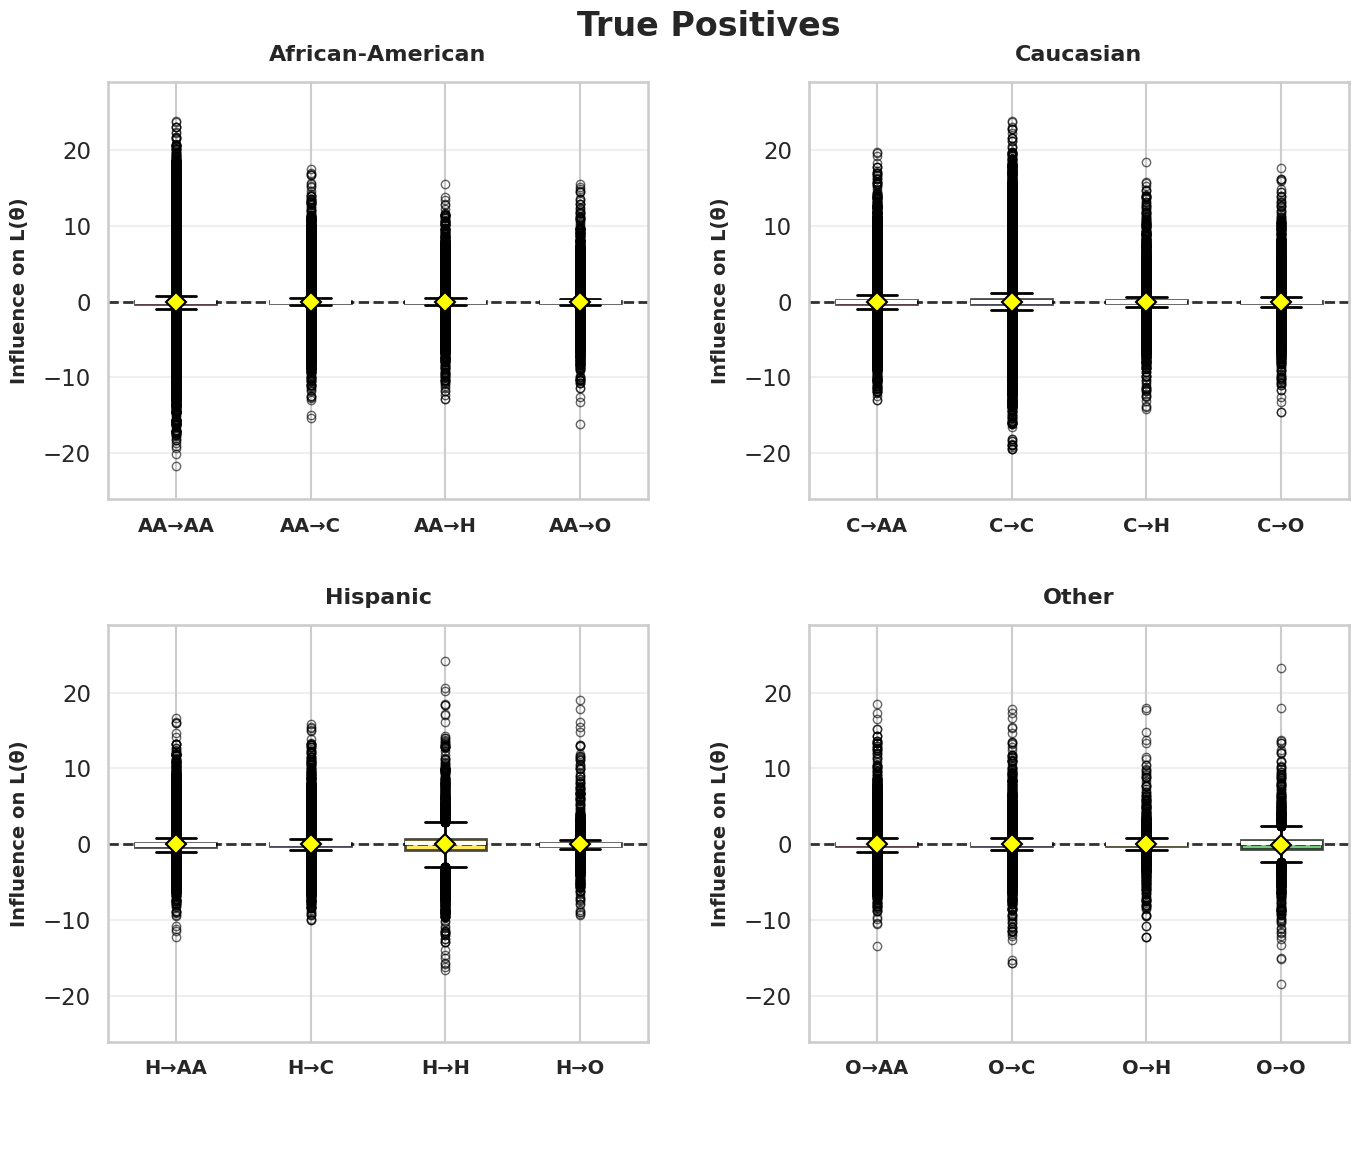

SAVED: Boxplot_With_Legend_TN.png


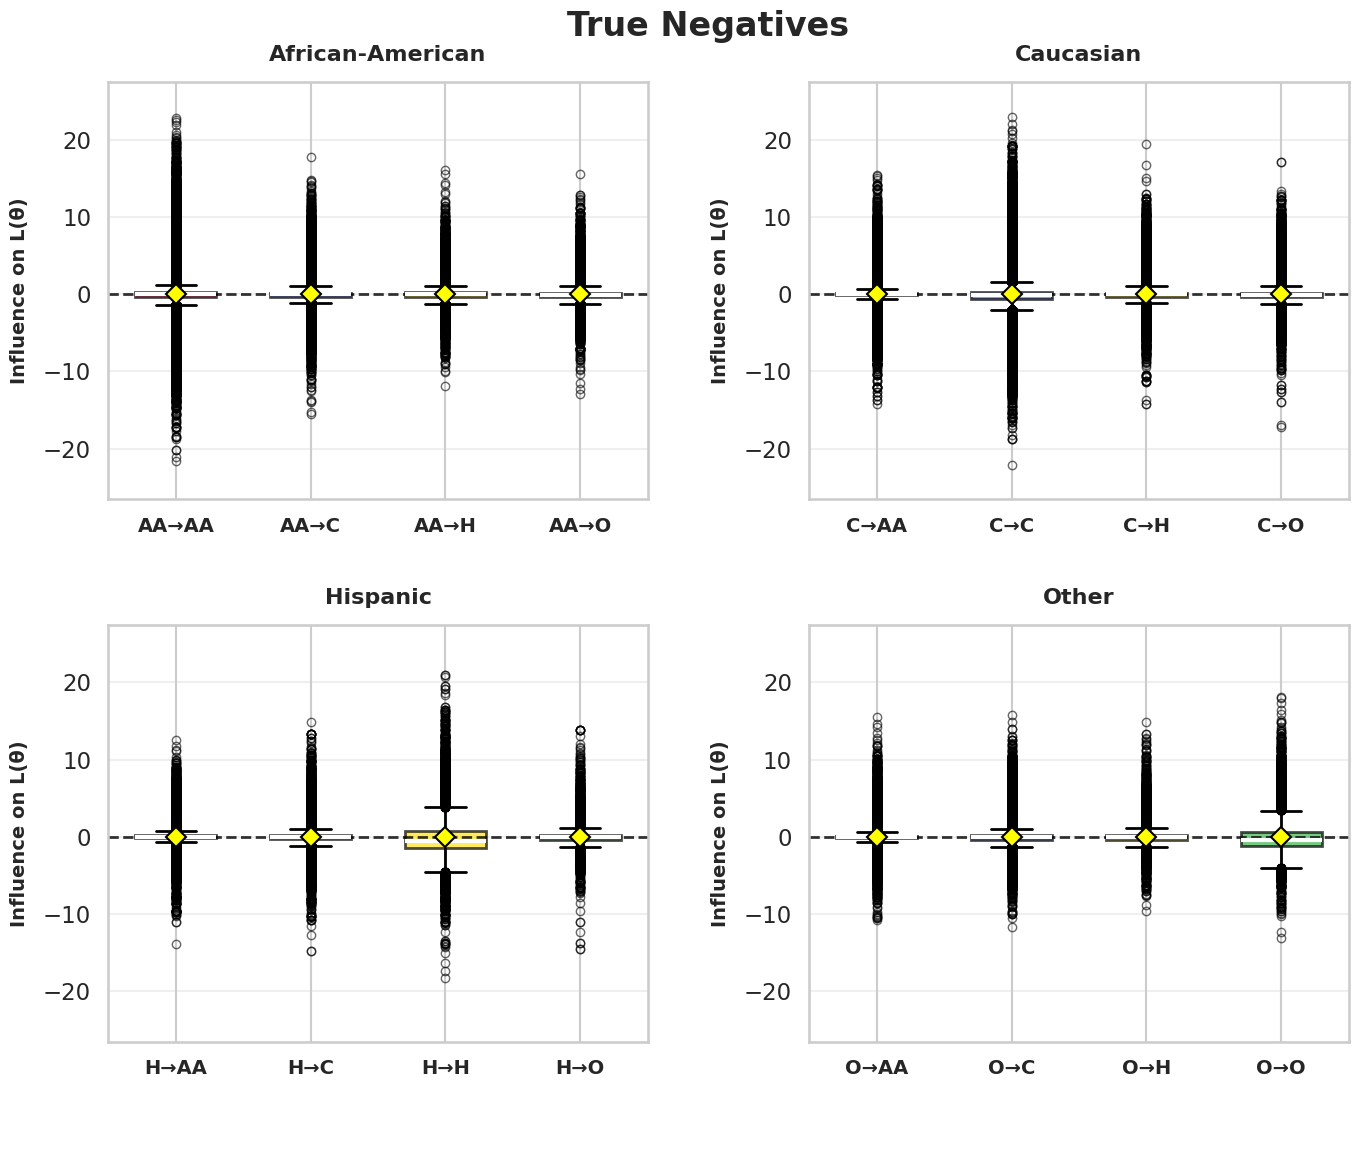

SAVED: Boxplot_With_Legend_FP.png


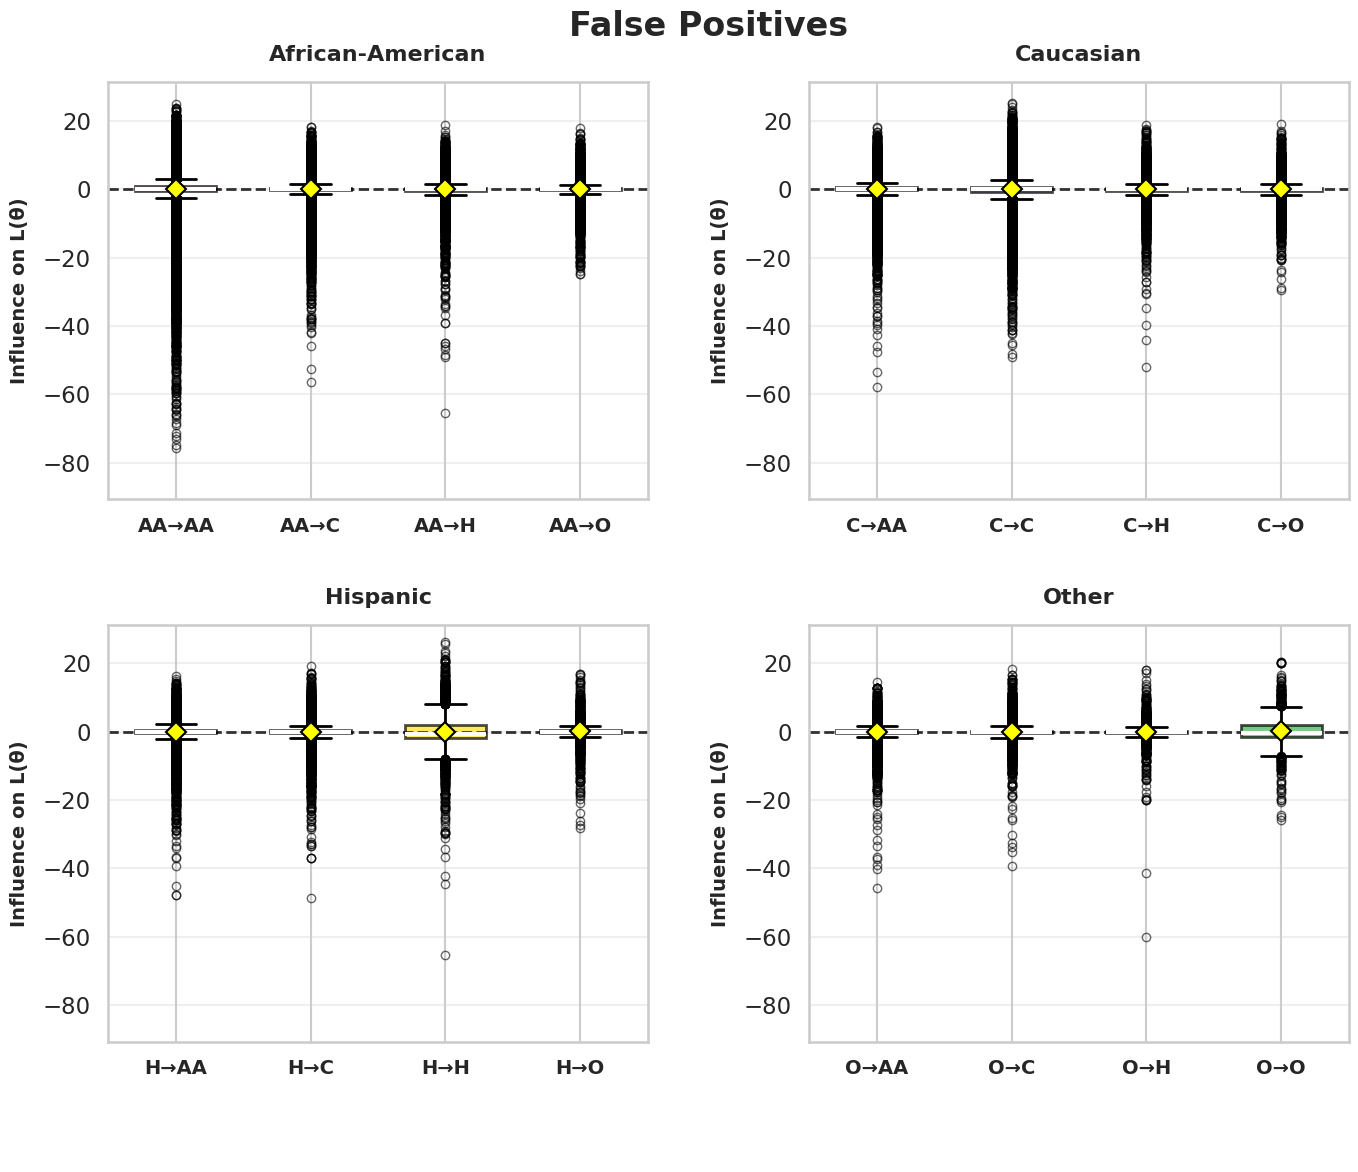

SAVED: Boxplot_With_Legend_FN.png


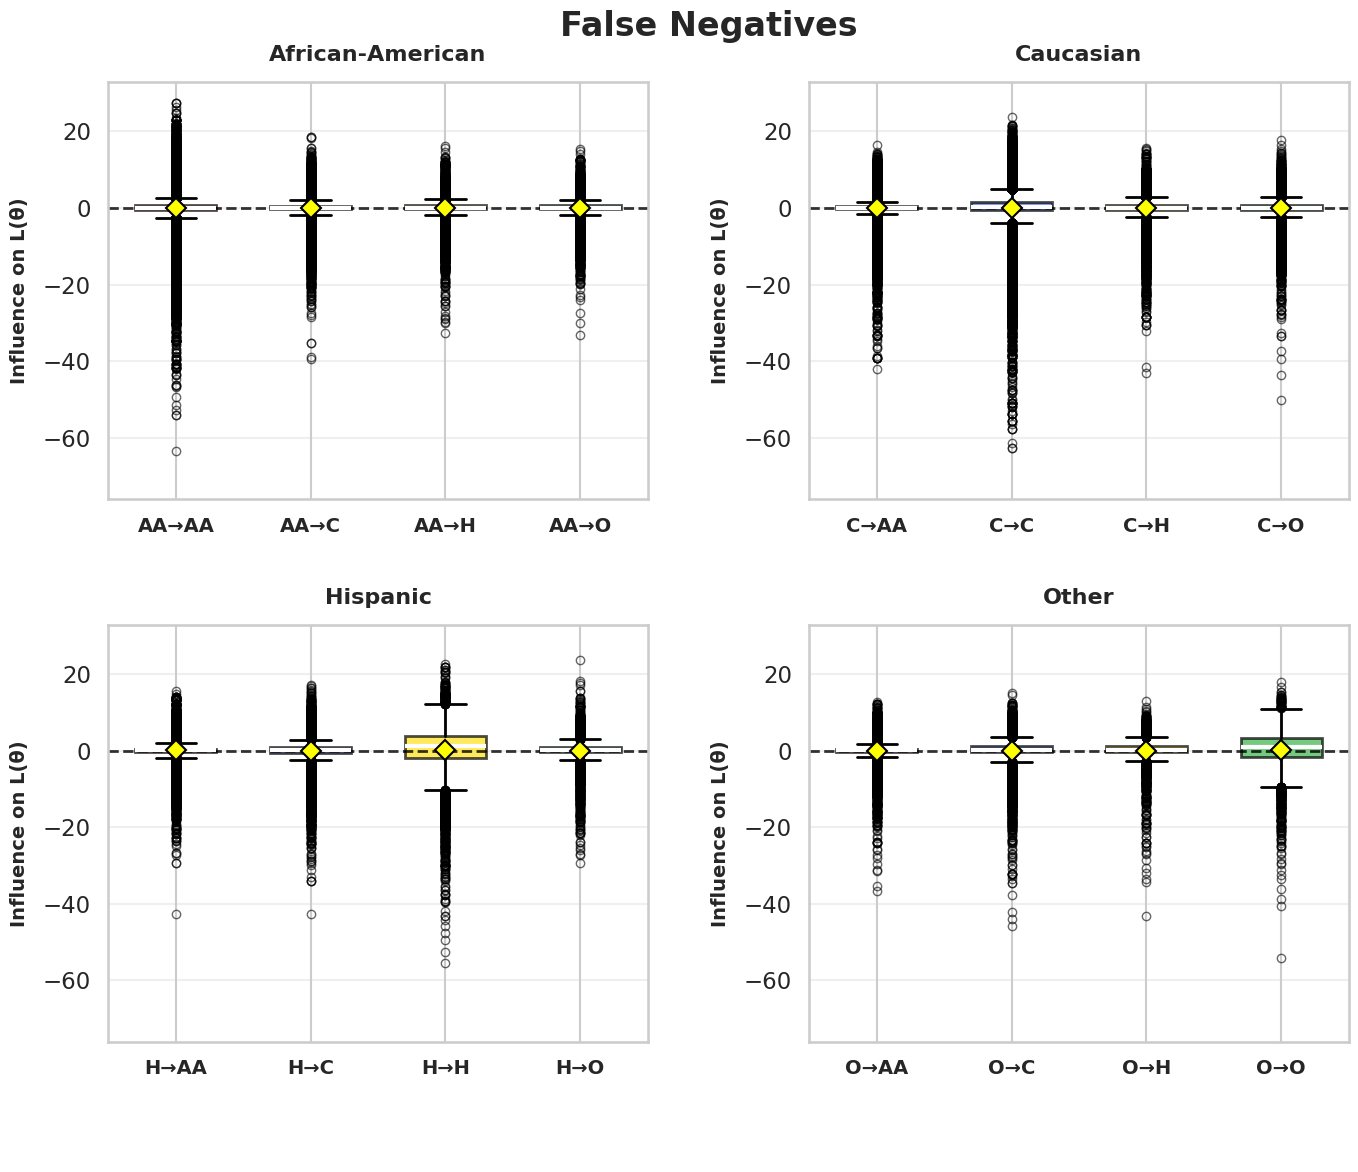


All plots generated!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ========================== LOAD & PREPARE ==========================

file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_compas_Recidivism.xlsx"
df_influence = pd.read_excel(file_path, sheet_name="Influence_Test_vs_Train")
df_preds     = pd.read_excel(file_path, sheet_name="Predictions_By_Race")
df_preds.columns = df_preds.columns.str.strip()
df_preds = df_preds.rename(columns=lambda x: x.replace('Predicated-Label', 'Predicted_Label'))

def find_id(df):
    for c in df.columns:
        if str(c).lower() in ['id', 'person_id', 'caseid', 'index', 'unnamed: 0']:
            return c
    return df.columns[0]

df_influence = df_influence.rename(columns={find_id(df_influence): 'ID'})
df_preds = df_preds.rename(columns={find_id(df_preds): 'ID'})
df = df_influence.merge(df_preds[['ID', 'Race', 'Actual_Label', 'Predicted_Label']], on='ID', how='inner')

df['Case_Type'] = np.select(
    [(df['Actual_Label']==1) & (df['Predicted_Label']==1),
     (df['Actual_Label']==0) & (df['Predicted_Label']==0),
     (df['Actual_Label']==0) & (df['Predicted_Label']==1),
     (df['Actual_Label']==1) & (df['Predicted_Label']==0)],
    ['TP', 'TN', 'FP', 'FN'], default=None
)

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("talk")

races = ['African-American', 'Caucasian', 'Hispanic', 'Other']
short = ['AA', 'C', 'H', 'O']
colors = ['#e6194b', '#4363d8', '#ffe119', '#3cb44b']
case_names = {'TP': 'True Positives', 'TN': 'True Negatives',
              'FP': 'False Positives', 'FN': 'False Negatives'}

# ========================== VIOLIN PLOT WITH EXTERNAL LEGEND ==========================

def plot_violin_with_legend(case_type):
    """Create violin plots with external legend showing statistics."""
    
    # Prepare all data first for consistent scaling
    all_influence_data = []
    for actual_race in races:
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        for p_race in races:
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            all_influence_data.extend(values)
    
    # Calculate overall y limits with some padding
    if all_influence_data:
        y_min = np.min(all_influence_data) * 1.2
        y_max = np.max(all_influence_data) * 1.2
        # Ensure we include zero in the range
        y_min = min(y_min, -0.01) if y_min < 0 else -0.01
        y_max = max(y_max, 0.01) if y_max > 0 else 0.01
    else:
        y_min, y_max = -0.1, 0.1
    
    # Create figure with adjusted height for legend
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25, top=0.92, bottom=0.1)
    
    fig.suptitle(f"{case_names[case_type]}", 
                 fontsize=24, fontweight='bold', y=0.98)
    
    # Store statistics for legend
    all_legend_stats = []
    
    for idx, actual_race in enumerate(races):
        ax = fig.add_subplot(gs[idx // 2, idx % 2])
        
        # Prepare data for this actual race
        plot_data = []
        stats_list = []
        
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        
        for p_idx, p_race in enumerate(races):
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            
            if len(values) > 0:
                plot_data.append(values)
                mean_val = np.mean(values)
                std_val = np.std(values, ddof=1) if len(values) > 1 else 0
                median_val = np.median(values)
                stats_list.append({
                    'mean': mean_val,
                    'std': std_val,
                    'median': median_val,
                    'n': len(values)
                })
            else:
                plot_data.append([])
                stats_list.append({
                    'mean': 0,
                    'std': 0,
                    'median': 0,
                    'n': 0
                })
        
        # Create violin plot
        if any(len(d) > 0 for d in plot_data):
            vp = ax.violinplot([d for d in plot_data if len(d) > 0], 
                              positions=[i for i in range(4) if len(plot_data[i]) > 0],
                              showmeans=False, showmedians=True, widths=0.8)
            
            # Color the violins
            for i, pc in enumerate(vp['bodies']):
                actual_idx = [j for j in range(4) if len(plot_data[j]) > 0][i]
                pc.set_facecolor(colors[actual_idx])
                pc.set_alpha(0.7)
                pc.set_edgecolor('black')
                pc.set_linewidth(1)
            
            # Style the median lines
            vp['cmedians'].set_colors(['white'])
            vp['cmedians'].set_linewidths(2)
        
        # Add scatter points for individual data (with jitter)
        for i, data in enumerate(plot_data):
            if len(data) > 0:
                jitter = np.random.normal(0, 0.05, len(data))
                ax.scatter(np.full(len(data), i) + jitter, data, 
                          alpha=0.4, s=30, color='black', edgecolor='white', linewidth=0.5, zorder=5)
        
        # Add mean markers
        for i, stats in enumerate(stats_list):
            if stats['n'] > 0:
                ax.plot(i, stats['mean'], 'D', color='yellow', markersize=10,
                       markeredgecolor='black', markeredgewidth=1.5, zorder=10,
                       label='Mean' if idx == 0 and i == 0 else "")
        
        # Zero line
        ax.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.8, zorder=1)
        
        # Set labels and ticks
        ax.set_xticks(range(4))
        ax.set_xticklabels([f"{short[idx]}→{short[i]}" for i in range(4)],
                          fontsize=14, fontweight='bold')
        #ax.set_xlabel('Predicted Race', fontsize=14, fontweight='semibold', labelpad=10)
        ax.set_ylabel('Influence on L(θ)', fontsize=14, fontweight='semibold', labelpad=10)
        
        # Title
        ax.set_title(f"{actual_race}", fontsize=16, fontweight='bold', pad=15)
        
        # Set consistent y limits
        ax.set_ylim(y_min, y_max)
        
        # Grid and frame
        ax.grid(True, axis='y', alpha=0.3, linestyle=':')
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        
        # Store statistics for external legend
        all_legend_stats.append(stats_list)
    
    # ===== CREATE EXTERNAL LEGEND (Similar to original design) =====
    
    # Create a separate axes for the legend
    legend_ax = fig.add_axes([0.15, 0.02, 0.7, 0.08])
    legend_ax.axis('off')
    
    # Create legend patches with statistics
    legend_patches = []
    legend_labels = []
    
    for i, race in enumerate(races):
        # Calculate average statistics across all subplots for this predicted race
        avg_mean = np.mean([all_legend_stats[j][i]['mean'] for j in range(4)])
        avg_std = np.mean([all_legend_stats[j][i]['std'] for j in range(4)])
        
        # Format the statistics string (similar to your original)
        if abs(avg_mean) < 0.001:
            stat_str = f"{short[i]}: 0.000±{avg_std:.3f}"
        else:
            stat_str = f"{short[i]}: {avg_mean:+.3f}±{avg_std:.3f}"
        
        # Create colored patch
        patch = plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], 
                             edgecolor='black', linewidth=1.5, alpha=0.8)
        legend_patches.append(patch)
        legend_labels.append(stat_str)
    
    # Add mean marker to legend
    mean_patch = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='yellow',
                           markeredgecolor='black', markersize=12, linewidth=0)
    legend_patches.append(mean_patch)
    legend_labels.append("Mean Value")
    
    # Add median indicator to legend
    median_line = plt.Line2D([0], [0], color='white', linewidth=3)
    legend_patches.append(median_line)
    legend_labels.append("Median")
    
    # Create the legend
    #legend = legend_ax.legend(legend_patches, legend_labels,
    #                         loc='center', ncol=len(legend_patches)//2,
    #                         fontsize=12, frameon=True,
    #                         fancybox=False, edgecolor='black',
    #                         borderpad=1.2, handletextpad=1.5,
    #                         columnspacing=2.0)
    
    #legend.get_frame().set_linewidth(2)
    #legend.get_frame().set_facecolor('white')
    
    # Add title to legend
    #legend.set_title("Predicted Race Statistics (averaged across all actual races)", 
    #                prop={'size': 13, 'weight': 'bold'})
    
    plt.subplots_adjust(bottom=0.15)  # Make room for the legend
    
    # Save the figure
    filename = f"Violin_Plot_With_Legend_{case_type}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"SAVED: {filename}")
    plt.show()

# ========================== ALTERNATIVE: BOXPLOT VERSION ==========================

def plot_boxplot_with_legend(case_type):
    """Boxplot version with external legend."""
    
    # Prepare all data for consistent scaling
    all_influence_data = []
    for actual_race in races:
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        for p_race in races:
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            all_influence_data.extend(values)
    
    # Calculate y limits
    if all_influence_data:
        y_min = np.min(all_influence_data) * 1.2
        y_max = np.max(all_influence_data) * 1.2
        y_min = min(y_min, -0.01)
        y_max = max(y_max, 0.01)
    else:
        y_min, y_max = -0.1, 0.1
    
    # Create figure
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, top=0.92, bottom=0.12)
    
    fig.suptitle(f"{case_names[case_type]}", fontsize=24, fontweight='bold', y=0.98)
    
    all_stats = []
    
    for idx, actual_race in enumerate(races):
        ax = fig.add_subplot(gs[idx // 2, idx % 2])
        
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        plot_data = []
        stats_list = []
        
        for p_idx, p_race in enumerate(races):
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            
            if len(values) > 0:
                plot_data.append(values)
                mean_val = np.mean(values)
                std_val = np.std(values, ddof=1) if len(values) > 1 else 0
                stats_list.append({
                    'mean': mean_val,
                    'std': std_val,
                    'n': len(values)
                })
            else:
                plot_data.append([])
                stats_list.append({'mean': 0, 'std': 0, 'n': 0})
        
        # Create boxplot
        bp = ax.boxplot([d for d in plot_data if len(d) > 0], 
                       positions=[i for i in range(4) if len(plot_data[i]) > 0],
                       widths=0.6, patch_artist=True,
                       medianprops=dict(color='white', linewidth=3),
                       boxprops=dict(linewidth=2),
                       whiskerprops=dict(linewidth=2),
                       capprops=dict(linewidth=2),
                       flierprops=dict(marker='o', markersize=6, alpha=0.6))
        
        # Color the boxes
        for i, box in enumerate(bp['boxes']):
            actual_idx = [j for j in range(4) if len(plot_data[j]) > 0][i]
            box.set_facecolor(colors[actual_idx])
            box.set_alpha(0.7)
        
        # Add mean markers
        for i, stats in enumerate(stats_list):
            if stats['n'] > 0:
                ax.plot(i, stats['mean'], 'D', color='yellow', markersize=10,
                       markeredgecolor='black', markeredgewidth=1.5, zorder=10)
        
        # Zero line
        ax.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.8)
        
        # Labels and formatting
        ax.set_xticks(range(4))
        ax.set_xticklabels([f"{short[idx]}→{short[i]}" for i in range(4)],
                          fontsize=14, fontweight='bold')
        #ax.set_xlabel('Predicted Race', fontsize=14, fontweight='semibold', labelpad=10)
        ax.set_ylabel('Influence on L(θ)', fontsize=14, fontweight='semibold', labelpad=10)
        ax.set_title(f"{actual_race}", fontsize=16, fontweight='bold', pad=15)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, axis='y', alpha=0.3)
        
        all_stats.append(stats_list)
    
    # External legend
    legend_ax = fig.add_axes([0.15, 0.02, 0.7, 0.08])
    legend_ax.axis('off')
    
    legend_patches = []
    legend_labels = []
    
    for i, race in enumerate(races):
        avg_mean = np.mean([all_stats[j][i]['mean'] for j in range(4)])
        avg_std = np.mean([all_stats[j][i]['std'] for j in range(4)])
        
        if abs(avg_mean) < 0.001:
            stat_str = f"{short[i]}: 0.000±{avg_std:.3f}"
        else:
            stat_str = f"{short[i]}: {avg_mean:+.3f}±{avg_std:.3f}"
        
        patch = plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], 
                             edgecolor='black', linewidth=2, alpha=0.8)
        legend_patches.append(patch)
        legend_labels.append(stat_str)
    
    # Add mean marker
    mean_patch = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='yellow',
                           markeredgecolor='black', markersize=12, linewidth=0)
    legend_patches.append(mean_patch)
    legend_labels.append("Mean")
    
    #legend = legend_ax.legend(legend_patches, legend_labels,
    #                         loc='center', ncol=len(legend_patches)//2,
    #                         fontsize=12, frameon=True,
    #                         fancybox=False, edgecolor='black',
    #                         borderpad=1.2, handletextpad=1.5,
    #                         columnspacing=2.0)
    
    #legend.get_frame().set_linewidth(2)
    #legend.set_title("Predicted Race: Mean ± Std (averaged across actual races)", 
    #                prop={'size': 13, 'weight': 'bold'})
    
    filename = f"Boxplot_With_Legend_{case_type}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"SAVED: {filename}")
    plt.show()

# ========================== GENERATE PLOTS ==========================
print("Generating plots with external legends...\n")

for case in ['TP', 'TN', 'FP', 'FN']:
    # Choose which version to use:
    plot_violin_with_legend(case)  # Violin plot version
    #plot_boxplot_with_legend(case)  # Boxplot version (uncomment to use)

print("\nAll plots generated!")